In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR08 — Əhalinin gəlirləri və xərcləri

Əhalinin pul gəlirlərinin, xərclərinin və onların artım sürətlərinin təhlili və proqnozlaşdırılması
(MİİS §15.5.1, bənd 2.4.1.5.-7.), əmək haqqı, məşğulluq/işsizlik və əhaliyə göstərilən ödənişli
xidmətlər daxil olmaqla.

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR8):** "Əhalinin pul gəlirləri, xərcləri və onların artım
sürətlərinin təhlili və proqnozlaşdırılması."

Tələb bir başlıq altında beş ayrı, lakin bir-biri ilə bağlı bloku əhatə edir: (i) əhalinin pul
gəlirləri və xərcləri (səviyyə və real artım tempi), (ii) orta aylıq əmək haqqı (məcmu və sektor
üzrə), (iii) məşğulluq və işsizlik səviyyəsi, (iv) əhaliyə göstərilən ödənişli xidmətlər. Bu dəftər
paketin **əhali bloku**dur: makroiqtisadi nüvədən (FR01) aşağı axına ötürülən iki real artım
yolunu — əhalinin gəlirinin (`g_income_core`) və son istehlakın (`g_cons_core`) — qəbul edir və
onların üzərində qurulan səviyyə, əmək haqqı, məşğulluq və xidmət göstəricilərini modelləşdirir.
Gəlir–istehlak keçidi (marjinal istehlak meyli, MPC) və gəlirin qeyri-neft artımından asılılığı
FR01-in simultan nüvəsində artıq qiymətləndirilib; bu dəftər həmin iki tənliyi **tam şəkildə təqdim
edir** (əmsallar, HAC standart xətaları, öz geriyə doğru sınağı) və proqnoz üfüqündə nüvənin
həll etdiyi yolu birbaşa istifadə edir — paralel, uzlaşmayan ikinci bir qiymətləndirmə aparmır.

Əmək haqqı və məşğulluq/işsizlik blokları isə bu dəftərdə İLK DƏFƏ qiymətləndirilir. İşsizlik
səviyyəsi sırasının indi mövcud olması (`unemployment_rate`, Sosial sektor sətir 65, 2010–2025)
Okun əlaqəsinin (işsizlik ↔ qeyri-neft artımı) düzgün, keçmiş versiyalarda mümkün olmayan bir
sınaqdan keçirilməsinə imkan verir.

## 2. Məlumat

İstifadə olunan sıralar (yalnız `data_layer.actuals(...)` vasitəsilə, HƏMİŞƏ ≤ 2025):

| `series_code` | Təsvir | Vahid | Əhatə |
|---|---|---|---|
| `income_nom` | Əhalinin pul gəlirləri | mln AZN | 1997–2025 |
| `income_realg` | Gəlirin real artım tempi (nəşr olunmuş) | % | 2013–2024 |
| `disposable_income` | Sərəncamında qalan gəlirlər | mln AZN | 2000–2025 |
| `expend_nom` | Əhalinin xərcləri | mln AZN | 2000–2025 |
| `expend_realg` | Xərcin real artım tempi (nəşr olunmuş) | % | 2013–2024 |
| `final_consumption` | Son istehlak xərcləri (milli hesablar) | mln AZN | 2000–2025 |
| `wage_avg` | Orta aylıq əmək haqqı | AZN | 1995–2025 |
| `wage_avg_realg` | Əmək haqqının real artım tempi (nəşr olunmuş) | % | 2013–2024 |
| `wage_oil`, `wage_nonoil`, `wage_state`, `wage_private` | Sektor üzrə orta aylıq əmək haqqı | AZN | 2005–2025 |
| `paid_services` | Əhaliyə göstərilən ödənişli xidmətlər | mln AZN | 1990–2025 |
| `paid_services_g` | Ödənişli xidmətlərin real artım tempi | % | 1990–2025 |
| `employment` | Ümumi məşğulluq | min nəfər | 1995–2025 |
| `employment_g` | Məşğulluğun artım tempi (nəşr olunmuş) | % | 2013–2024 |
| `labour_force` | İqtisadi fəal əhalinin sayı | min nəfər | 1995–2025 |
| `unemployment_rate` | İşsizlik səviyyəsi | % | 2010–2025 |

**2024-də kəsilən beş sıra.** `income_realg`, `expend_realg`, `wage_avg_realg` və `employment_g`
statutar şablonda yalnız 2024-cü ilə qədər hazır verilib (`data_layer.data_gaps()`-in FR1/FR8
qeydi); iş kitabında bu artım templəri ayrıca sətir kimi yoxdur. 2025-ci il üçün hər dördü bu
dəftərdə **arifmetik yolla** — səviyyə sırasının (`*_nom` / `employment`) nominal artımından
İQİ-nin (real gəlir/xərc/əmək haqqı üçün) və ya birbaşa (məşğulluq üçün, artıq real kəmiyyət
olduğu üçün deflyator lazım deyil) çıxarılması ilə — tamamlanır (§3). `final_consumption` üçün
ayrıca nəşr olunmuş artım sırası yoxdur, ona görə onun real artımı bütün nümunə boyu eyni
düsturla qurulur — bu, FR01-in nüvə tənliyində istifadə etdiyi `g_cons` dəyişəninin məhz
özüdür.

Aşağıda faktiki sıraların əhatəsi çap olunur.

In [2]:
import pandas as pd

LA, FY = config.LAST_ACTUAL, list(config.FY)          # 2025 və 2026–2030
WB = "Statistik data dinamika 05.06.2026 +.xlsx"

cpi = data_layer.actuals("cpi_infl")                  # FR9-un faktiki sırası (deflyasiya üçün)
inc_nom = data_layer.actuals("income_nom")
dispo = data_layer.actuals("disposable_income")
exp_nom = data_layer.actuals("expend_nom")
fcons = data_layer.actuals("final_consumption")
wage = data_layer.actuals("wage_avg")
wage_oil = data_layer.actuals("wage_oil")
wage_nonoil = data_layer.actuals("wage_nonoil")
wage_state = data_layer.actuals("wage_state")
wage_private = data_layer.actuals("wage_private")
paid = data_layer.actuals("paid_services")
paid_g_pub = data_layer.actuals("paid_services_g")
emp = data_layer.actuals("employment")
lf = data_layer.actuals("labour_force")
u = data_layer.actuals("unemployment_rate")
# qeyri-neft real artımı — FR01-in nüvəsinin istifadə etdiyi İLƏ EYNİ birləşdirilmiş (splice) sıra:
# statutar şablon 2013-dən başladığı üçün 2000-2012 üçün iş kitabının Real sektor bloku istifadə
# olunur (FR01 §2.1-in eyni məntiqi) — əks halda 2013-dən əvvəlki illər itirilir və Okun/gəlir
# tənlikləri lazımsız yerə qısa nümunəyə həsr olunur
_non_g_wb = (data_layer.wb_annual("real_r006") - 100.0)
_non_g_wb = _non_g_wb[_non_g_wb.index <= LA]
nonoil = pd.concat([_non_g_wb.loc[2000:2012], data_layer.actuals("nonoil_realg")]).sort_index().rename("nonoil")

rows = []
for code, s in [("income_nom", inc_nom), ("disposable_income", dispo), ("expend_nom", exp_nom),
                ("final_consumption", fcons), ("wage_avg", wage), ("wage_oil", wage_oil),
                ("wage_nonoil", wage_nonoil), ("wage_state", wage_state), ("wage_private", wage_private),
                ("paid_services", paid), ("paid_services_g", paid_g_pub), ("employment", emp),
                ("labour_force", lf), ("unemployment_rate", u), ("nonoil_realg (FR01)", nonoil),
                ("cpi_infl (FR09)", cpi)]:
    rows.append({"series_code": code, "ilk il": int(s.index.min()), "son il": int(s.index.max()), "n": len(s)})
pd.DataFrame(rows).set_index("series_code")

,ilk il,son il,n
series_code,,,
income_nom,1997,2025,29
disposable_income,2000,2025,26
expend_nom,2000,2025,26
final_consumption,2000,2025,26
wage_avg,1995,2025,31
wage_oil,2005,2025,21
wage_nonoil,2005,2025,21
wage_state,2005,2025,21
wage_private,2005,2025,21


In [3]:
gaps = data_layer.data_gaps()
fr8_gaps = gaps[gaps["series_code"].astype(str).str.contains(
    "income_realg|expend_realg|wage_avg_realg|employment_g", regex=True)]
fr8_gaps

,series_code,fr,problem_az,treatment_az
4,"oil_defl, gdp_pc_realg, income_realg, expend_r...",FR1/FR8,Bu artım və deflyator sıraları yalnız statutar...,2025-ci il üçün səviyyə sıralarından və İQİ-də...


### 2.4. Fəaliyyət növləri üzrə əmək bloku — MOE SOCIAL (əmək haqqı → gəlir kanalı)

Bu buraxılışda dəftərə **19 fəaliyyət növü üzrə əmək haqqı, məşğulluq və əmək haqqı fondu**
sıraları daxil edilir (`MOE SOCIAL.xlsx`, 8 / 9 / add8 vərəqləri, **1999–2024**). Sıralar paketin
`data_layer`-i vasitəsilə oxunur; provenans `data_layer.MOE_SOCIAL_SOURCE_NOTE`-dadır və hər
sətrin etiketi `verify_moe_social()` ilə mənbədən yoxlanıla bilir.

**Nə üçün lazımdır.** Paketin öz iş kitabı sahə üzrə əmək haqqı və işçi sayını yalnız dörd sənaye
vərəqi üçün (2016-dan) və DVX kəsikləri üçün (2021-dən) daşıyır — əmək haqqı → gəlir kanalının tələb etdiyi əmək
haqqı → gəlir kanalını qurmaq üçün bu, nə uzunluq, nə də əhatə baxımından kifayət deyil. MOE
SOCIAL həmin bölgünü 26 illik nümunə ilə verir.

**Üç ciddi qeyd (mühafizə qaydaları):**

1. **Yalnız faktiki sütunlar.** Vərəqlərin illik başlığının üstündəki annotasiya sətri 2025-i
   "gözlənilən", 2026–2030-u "proqnoz" kimi işarələyir. Məlumat qatı bu blokda **2024-dən sonrakı
   heç bir sütunu saxlamır** (`data_layer.MOE_LAST_ACTUAL = 2024`), yəni Nazirliyin nümunə
   modelinin proqnozu heç bir tənliyə girə bilmir.
2. **`model` və `add factor` sətirləri məlumat deyil.** MOE SOCIAL `7_10` vərəqinin 30, 32 və 33-cü
   sətirləri nümunə modelin öz proqnozu və mülahizə düzəlişidir; blok onları oxumur.
3. **Aqreqat sıralar paketin öz qatından götürülür.** MOE blok yalnız SAHƏ bölgüsü üçündür; orta
   aylıq əmək haqqı, məşğulluq və gəlir hesabı paketin öz iş kitabındandır. Aşağıdakı vintaj
   tutuşdurması bunu ədədlə əsaslandırır.

In [4]:
# NumPy və statsmodels bu buraxılışda ARTIQ §2.4-də lazımdır (kanal blokları §5.7/§6.6-da
# həmin kitabxanalardan istifadə edir); §6.1-dəki təkrar idxal zərərsizdir.
import numpy as np
import statsmodels.api as sm

# --- MOE SOCIAL sahə əmək bloku (yalnız faktiki sütunlar, <=2024) --------------------------
MOE_W = data_layer.moe_branch_wages()          # 19 sahə, AZN/ay, 1999-2024
MOE_L = data_layer.moe_branch_employment()     # 19 sahə, min nəfər (ÜMUMİ məşğulluq), 1999-2024
MOE_FUND = data_layer.moe_branch_wage_bill()   # 19 sahə, mln AZN (MUZDLU işçilərin fondu), 2000-2024
MOE_E = data_layer.moe_branch_employees()      # törəmə: muzdlu işçi sayı = fond*1000/(12*əmək haqqı)
BRANCH_AZ = {c: lab for c, lab, _r, _f in data_layer.MOE_SOCIAL_BRANCHES}

assert int(MOE_W.index.max()) <= 2024 and int(MOE_L.index.max()) <= 2024 and int(MOE_FUND.index.max()) <= 2024, \
    "MOE bloku 2024-dən sonrakı sütun daşıyır — mühafizə qaydası pozulur"

_tbl = pd.DataFrame({
    "əmək haqqı 2024, AZN": MOE_W.loc[2024],
    "məşğulluq 2024, min nəfər": MOE_L.loc[2024],
    "muzdlu işçi 2024, min nəfər": MOE_E.loc[2024].round(1),
    "fond 2024, mln AZN": MOE_FUND.loc[2024].round(1),
    "əmək haqqı: ilk il": MOE_W.apply(lambda s: int(s.dropna().index.min())),
    "n": MOE_W.apply(lambda s: int(s.dropna().size)),
})
_tbl.index = [BRANCH_AZ[c] for c in _tbl.index]
print(f"MOE SOCIAL: {MOE_W.shape[1]} fəaliyyət növü, əmək haqqı {int(MOE_W.index.min())}-{int(MOE_W.index.max())}, "
      f"fond {int(MOE_FUND.index.min())}-{int(MOE_FUND.index.max())}")
print("\nPROVENANS —", data_layer.MOE_SOCIAL_SOURCE_NOTE)
print("\nPROVENANS —", data_layer.MOE_SSPF_SOURCE_NOTE)
print("\nMənbədən yenidən qurma yoxlaması (fayl əlçatan olduqda; təhvil mühitində None):",
      "moe_social =", data_layer.verify_moe_social(), "| moe_sspf =", data_layer.verify_moe_sspf())
_tbl

MOE SOCIAL: 19 fəaliyyət növü, əmək haqqı 1999-2024, fond 2000-2024

PROVENANS — MOE SOCIAL.xlsx — `8` vərəqi sətir 7 (iqtisadiyyat üzrə orta aylıq əmək haqqı), 9–45 (19 fəaliyyət növü, tək sətirlər), 48/50 (dövlət/qeyri-dövlət), 58/60 (neft/qeyri-neft), 62 (minimum əmək haqqı); `9` vərəqi eyni sətir sxemi ilə muzdlu/ümumi məşğulluq; `add8` vərəqi sətir 29 (iqtisadiyyat üzrə əmək haqqı fondu, AZN mln) və 30–48 (19 fəaliyyət növü üzrə fond). Nazirliyin nümunə-model faylı — YALNIZ OXUNUR, yalnız faktiki sütunlar (≤2024; annotasiya sətri 2025-i 'gözlənilən', 2026–2030-u 'proqnoz' kimi işarələyir)

PROVENANS — MOE FISCAL.xlsx, `Pension Fund` vərəqi (Dövlət Sosial Müdafiə Fondunun büdcəsi, mln AZN): sətir 4 (gəlirlər), 10 (dövlət büdcəsindən transfertlər), 12 (xərclər), 13 (əhaliyə ödənişlər), 14 (əmək pensiyaları). Nazirliyin nümunə-model faylı — YALNIZ OXUNUR, yalnız faktiki sütunlar (≤2024)

Mənbədən yenidən qurma yoxlaması (fayl əlçatan olduqda; təhvil mühitində None): moe_social = None

,"əmək haqqı 2024, AZN","məşğulluq 2024, min nəfər","muzdlu işçi 2024, min nəfər","fond 2024, mln AZN",əmək haqqı: ilk il,n
"Kənd, meşə və balıqçılıq təsərrüfatı",589.6,1782.3,47.3,334.7,1999,26
Mədənçıxarma sənayesi,3564.8,39.7,33.0,1411.7,1999,26
Emal sənayesi,905.5,293.8,135.0,1466.9,1999,26
"Elektrik enerjisi, qaz və buxar istehsalı, bölüşdürülməsi və təchizatı",1097.2,29.7,29.7,391.0,1999,26
Su təchizatı; tullantıların təmizlənməsi və emalı,745.3,42.2,42.1,376.5,1999,26
Tikinti,1086.5,403.8,117.3,1529.4,1999,26
Ticarət; nəqliyyat vasitələrinin təmiri,691.3,718.4,329.7,2735.1,1999,26
Turistlərin yerləşdirilməsi və ictimai iaşə,749.2,103.6,62.2,559.2,1999,26
Nəqliyyat və anbar təsərrüfatı,1395.1,207.6,75.7,1267.3,1999,26
İnformasiya və rabitə,1670.8,60.2,34.3,687.7,1999,26


**Muzdlu işçi sayı — törəmə, lakin əsassız deyil.** `9` vərəqinin məşğulluq sətirləri ÜMUMİ
məşğulluqdur (kənd təsərrüfatında 2024-cü ildə 1 782,3 min nəfər — əsasən öz hesabına çalışanlar),
ona görə əmək haqqı × məşğulluq **fond deyil**. Fond sətirləri (add8) muzdlu işçilərə aiddir; hər
sahə üçün onların arxasındakı işçi sayı tərifə görə `fond × 1000 / (12 × əmək haqqı)`-dır. Cəm
2000-ci ildə 1 217,8, 2024-cü ildə 1 778,5 min nəfər verir — Dövlət Vergi Xidmətinin öz muzdlu
işçi sırası ilə (2021–2025, aşağıda) eyni böyüklük sırasındadır; fərq iki inzibati perimetrin
fərqidir (DVX əmək müqavilələrini sayır, ona görə yuxarıdır) və gizlədilmir.

In [5]:
# --- aqreqat fond, muzdlu işçi sayı və DVX ilə çarpaz yoxlama -----------------------------
FUND_MOE = data_layer.moe_payroll_fund()          # 19 sahənin cəmi, mln AZN
EMPLOYEES_MOE = data_layer.moe_employees_total()  # 19 sahənin cəmi, min nəfər
_agg = data_layer.moe_social_aggregates()

# eynilik: sahələrin cəmi = vərəqin öz aqreqat fond sətri (add8 r29)
_fund_gap = float((FUND_MOE - _agg["fund_total"]).abs().max())
print(f"fond eyniliyi (19 sahənin cəmi = add8 r29): maks. sapma {_fund_gap:.9f} mln AZN")

# 2025 tamamlanması: MOE bloku 2024-də bitir, muzdlu işçi sırası DVX-nin artım tempi ilə uzadılır
_edvx = data_layer.actuals("employees_dvx")
EMPL_SPLICE_G = float((_edvx.loc[LA] / _edvx.loc[2024] - 1) * 100)
EMPL_MOE = EMPLOYEES_MOE.copy()
EMPL_MOE.loc[LA] = float(EMPLOYEES_MOE.loc[2024] * (1 + EMPL_SPLICE_G / 100))

_x = pd.DataFrame({
    "MOE muzdlu işçi, min nəfər": EMPL_MOE,
    "DVX muzdlu işçi, min nəfər": _edvx,
    "MOE fond, mln AZN": FUND_MOE,
    "DVX əmək haqqı fondu, mln AZN": data_layer.actuals("wage_fund_total"),
}).loc[2019:LA]
_x["MOE/DVX işçi"] = (_x.iloc[:, 0] / _x.iloc[:, 1]).round(3)
_x["MOE/DVX fond"] = (_x.iloc[:, 2] / _x.iloc[:, 3]).round(3)
print(f"2025 muzdlu işçi sayı DVX artım tempi ilə tamamlanıb: {EMPL_SPLICE_G:+.2f} % "
      f"({EMPLOYEES_MOE.loc[2024]:.1f} -> {EMPL_MOE.loc[LA]:.1f} min nəfər)")
_x.round(1)

fond eyniliyi (19 sahənin cəmi = add8 r29): maks. sapma 0.000001000 mln AZN
2025 muzdlu işçi sayı DVX artım tempi ilə tamamlanıb: -0.67 % (1778.5 -> 1766.6 min nəfər)


,"MOE muzdlu işçi, min nəfər","DVX muzdlu işçi, min nəfər","MOE fond, mln AZN","DVX əmək haqqı fondu, mln AZN",MOE/DVX işçi,MOE/DVX fond
2019,1646.6,NaN,12540.6,NaN,NaN,NaN
2020,1698.7,NaN,14352.5,NaN,NaN,NaN
2021,1709.1,1807.6,14974.8,16045.7,0.9,0.9
2022,1738.7,1865.1,17499.5,19127.6,0.9,0.9
2023,1745.5,1946.2,19537.0,21690.8,0.9,0.9
2024,1778.5,2073.8,21490.0,24081.1,0.9,0.9
2025,1766.6,2059.9,NaN,26526.9,0.9,NaN


**Vintaj tutuşdurması (splice qaydası).** MOE SOCIAL-ın aqreqat sətirləri paketin öz iş kitabının
sətirləri ilə tutuşdurulur (aşağıda **üç vintaj** verilir: MOE SOCIAL · əsas iş kitabı · statutar
8 vərəq). Nəticə:

* **məşğulluq** — 29 ilin hamısında fərq **sıfırdır**;
* **orta aylıq əmək haqqı** — 30 ilin 25-də fərq sıfırdır; 1995–1998-də ≤ 0,17 % (iş kitabının
  həmin illəri bir onluq rəqəmə yuvarlaqlaşdırılıb: 12,502 vs 12,5), 2024-də isə **−0,02 %**
  (1 009,2 vs 1 009,4). 8 vərəq bu iki ildə MOE ilə eynidir (1 009,2), yəni fərq iş kitabının
  daha yeni buraxılışındandır;
* **sektor kəsikləri** — dövlət və neft-qaz əmək haqqında ≤ 0,25 %; yeganə nəzərəçarpan fərq
  qeyri-neft sektoru əmək haqqının 2005–2008 illərindədir (maks. +4,4 %, 2005).

Ona görə **birləşdirmə qaydası sadədir və heç bir yenidən miqyaslama tələb etmir**: bütün aqreqat
sıralar paketin öz iş kitabından götürülür (yeganə buraxılış ki, 2025-i daşıyır və göndərilən
yolun bazasıdır), MOE SOCIAL isə YALNIZ sahə bölgüsünü verir. Fərqlər 0,25 %-dən kiçik olduğu
üçün iki qatın birləşməsi sahə paylarında ölçülə bilən sıçrayış yaratmır.

In [6]:
_sp = data_layer.moe_wage_splice_check()
_summary = (_sp.groupby("sıra")
              .agg(**{"ilk il": ("il", "min"), "son il": ("il", "max"), "il sayı": ("il", "size"),
                      "maks |fərq|, %": ("fərq_%", lambda s: round(float(s.abs().max()), 4)),
                      "0-dan fərqli il": ("fərq_%", lambda s: int((s.abs() > 1e-9).sum()))}))
print("MOE SOCIAL aqreqatları vs paketin iş kitabı — vintaj fərqi:")
display(_summary)
print()
print("sıfırdan fərqli illər (hamısı):")
display(_sp.loc[_sp["fərq_%"].abs() > 1e-9, ["sıra", "il", "moe", "paket", "fərq_%"]].round(3))

# ÜÇ VİNTAJ: MOE SOCIAL · əsas iş kitabı · statutar 8 vərəq — orta aylıq əmək haqqı
_v57 = data_layer.vereq_actuals("2.4.1.5.-7.", "Orta aylıq əmək haqqı")
_three = pd.DataFrame({"MOE SOCIAL": data_layer.moe_social_aggregates()["w_avg"],
                       "əsas iş kitabı (GÖNDƏRİLİR)": data_layer.actuals("wage_avg"),
                       "statutar 8 vərəq": _v57}).loc[2015:LA]
_three["MOE − iş kitabı, %"] = (_three.iloc[:, 0] / _three.iloc[:, 1] - 1) * 100
_three["8 vərəq − iş kitabı, %"] = (_three.iloc[:, 2] / _three.iloc[:, 1] - 1) * 100
print("\nÜç vintaj — orta aylıq əmək haqqı (AZN). SPLICE QAYDASI: aqreqat sıra HƏMİŞƏ əsas iş "
      "kitabındandır\n(yeganə 2025-i daşıyan buraxılış); MOE və 8 vərəq yalnız tutuşdurma üçündür.")
_three.round(3)

MOE SOCIAL aqreqatları vs paketin iş kitabı — vintaj fərqi:


,ilk il,son il,il sayı,"maks |fərq|, %",0-dan fərqli il
sıra,,,,,
dövlət sektorunda əmək haqqı,2005,2024,20,0.0752,4
məşğul əhalinin sayı,1996,2024,29,0.0000,0
neft-qaz sektorunda əmək haqqı,2005,2024,20,0.2504,4
orta aylıq əmək haqqı,1995,2024,30,0.1730,5
qeyri-neft sektorunda əmək haqqı,2005,2024,20,4.4077,5



sıfırdan fərqli illər (hamısı):


,sıra,il,moe,paket,fərq_%
0,orta aylıq əmək haqqı,1995,12.502,12.5,0.020
1,orta aylıq əmək haqqı,1996,17.887,17.9,-0.073
2,orta aylıq əmək haqqı,1997,28.349,28.3,0.173
3,orta aylıq əmək haqqı,1998,33.708,33.7,0.024
29,orta aylıq əmək haqqı,2024,1009.200,1009.4,-0.020
43,dövlət sektorunda əmək haqqı,2018,435.200,435.5,-0.069
44,dövlət sektorunda əmək haqqı,2019,531.300,531.7,-0.075
48,dövlət sektorunda əmək haqqı,2023,904.000,904.1,-0.011
49,dövlət sektorunda əmək haqqı,2024,975.200,975.9,-0.072
52,neft-qaz sektorunda əmək haqqı,2007,840.900,838.8,0.250



Üç vintaj — orta aylıq əmək haqqı (AZN). SPLICE QAYDASI: aqreqat sıra HƏMİŞƏ əsas iş kitabındandır
(yeganə 2025-i daşıyan buraxılış); MOE və 8 vərəq yalnız tutuşdurma üçündür.


,MOE SOCIAL,əsas iş kitabı (GÖNDƏRİLİR),statutar 8 vərəq,"MOE − iş kitabı, %","8 vərəq − iş kitabı, %"
2015,466.9,466.9,466.9,0.00,0.000
2016,499.8,499.8,499.8,0.00,0.000
2017,528.5,528.5,528.5,0.00,0.000
2018,544.6,544.6,544.6,0.00,0.000
2019,635.1,635.1,634.8,0.00,-0.047
2020,707.7,707.7,707.7,0.00,0.000
2021,732.1,732.1,732.1,0.00,0.000
2022,840.0,840.0,840.0,0.00,0.000
2023,933.9,933.9,933.9,0.00,0.000
2024,1009.2,1009.4,1009.2,-0.02,-0.020


### 2.5. Mülkiyyət × fəaliyyət növü əmək haqqı paneli (bu buraxılış)

`DATA_GAP_NEGATIVE_PROOF.md` sənədinin (xiii) bəndi Nazirliyə göndəriləcək sorğunun 17(iii) sətrini — *"fəaliyyət növü × dövlət/qeyri-dövlət kəsişməsi (hazırda yalnız iqtisadiyyat üzrə ümumi bölgü var)"* — birbaşa təkzib etdi: kəsişmə **DSK-nın 4.5–4.8 nömrəli cədvəlinin `Dynamics` vərəqindədir**, 19 fəaliyyət növü × (cəmi | dövlət | qeyri-dövlət) formatında, **2005–2024** dövrü üçün. Məşğulluq qarşılığı isə 2.12 nömrəli cədvəldədir (`002_12-13en.xls`, eyni kəsişmə, min nəfər).

Bu bölmə paneli **modelə daxil edir və nəşr edir**: 20 sətir (19 fəaliyyət növü + iqtisadiyyat cəmi) × 3 mülkiyyət kəsiyi × 2 göstərici = **120 sıra**, hər biri 20 illik. Üç iş görülür:

1. **Eyniliklərin yoxlanması** — sahələrin cəmi iqtisadiyyat cəminə, dövlət + qeyri-dövlət isə cəmiyə bərabər olmalıdır; əmək haqqı üçün məşğulluqla çəkilmiş orta iqtisadiyyat sətrini verməlidir.
2. **Paketin öz aqreqatları ilə tutuşdurma** — iş kitabının `wage_state` / `wage_private` sıralarının bu panelin iqtisadiyyat sətri ilə eyni obyekt olub-olmadığı ədədlə yoxlanılır.
3. **2025-ci ilin tamamlanması** — DSK panelinin son ili 2024-dür; 2025 sütunu DVX/iş kitabı qarşılıqları ilə tamamlanır (aşağıda qayda və onun məhdudiyyəti açıq verilir).

In [7]:
# --- DSK 4.5-4.8 və 2.12: 19 fəaliyyət növü × mülkiyyət ------------------------------------
WSSC = data_layer.ssc_branch_wage_ownership()        # AZN/ay, 2005-2024
ESSC = data_layer.ssc_branch_employment_ownership()  # min nəfər, 2005-2024
BRANCH_SSC = [(r, lab) for r, lab in data_layer.SSC_ACTIVITY_ROWS if r != "total"]
BR_CODES = [r for r, _ in BRANCH_SSC]
OWN_SUF = [("", "cəmi"), ("_state", "dövlət"), ("_nonstate", "qeyri-dövlət")]

print(f"panel ölçüsü: əmək haqqı {WSSC.shape}, məşğulluq {ESSC.shape}; "
      f"dövr {int(WSSC.index.min())}-{int(WSSC.index.max())}")
print("PROVENANS —", data_layer.PUBLIC_FILES["ssc0458"][1])
print("PROVENANS —", data_layer.PUBLIC_FILES["ssc0212"][1])

# --- eyniliklər -----------------------------------------------------------------------------
_id = []
for suf, lab in OWN_SUF:
    _esum = sum(ESSC[f"emp_ssc_{b}{suf}"] for b in BR_CODES)
    _wagg = (sum(WSSC[f"wage_ssc_{b}{suf}"] * ESSC[f"emp_ssc_{b}{suf}"] for b in BR_CODES) / _esum)
    _id.append({"kəsik": lab,
                "məşğulluq: 19 sahə − cəmi (maks. |fərq|, min nəfər)":
                    round(float((_esum - ESSC[f"emp_ssc_total{suf}"]).abs().max()), 4),
                "əmək haqqı: çəkili orta − cəmi (maks. nisbi fərq, %)":
                    round(float(((_wagg - WSSC[f"wage_ssc_total{suf}"])
                                 / WSSC[f"wage_ssc_total{suf}"] * 100).abs().max()), 3)})
print()
print("Eyniliklər (19 sahədən aqreqasiya ↔ cədvəlin öz iqtisadiyyat sətri):")
print(pd.DataFrame(_id).to_string(index=False))
print()
print("dövlət + qeyri-dövlət = cəmi (məşğulluq, maks. |fərq|):",
      round(float((ESSC["emp_ssc_total_state"] + ESSC["emp_ssc_total_nonstate"]
                   - ESSC["emp_ssc_total"]).abs().max()), 6), "min nəfər")

# --- paketin öz aqreqatları ilə tutuşdurma --------------------------------------------------
_cmp = pd.DataFrame({"iş kitabı: dövlət": wage_state, "DSK: dövlət": WSSC["wage_ssc_total_state"],
                     "iş kitabı: özəl": wage_private, "DSK: qeyri-dövlət": WSSC["wage_ssc_total_nonstate"],
                     "iş kitabı: cəmi": wage, "DSK: cəmi": WSSC["wage_ssc_total"]}).loc[2005:LA]
_gapmax = max(float((_cmp["iş kitabı: dövlət"] - _cmp["DSK: dövlət"]).abs().max()),
              float((_cmp["iş kitabı: özəl"] - _cmp["DSK: qeyri-dövlət"]).abs().max()))
print()
print(f"iş kitabının sektor sıraları ilə DSK panelinin iqtisadiyyat sətri arasında maks. |fərq| "
      f"= {_gapmax:.4f} AZN (2005-2024)")
print("Yəni iş kitabının `wage_state`/`wage_private` sıraları elə bu DSK cədvəlinin iqtisadiyyat")
print("sətridir; panelin ƏLAVƏ ETDİYİ məlumat FƏALİYYƏT NÖVÜ ölçüsüdür, aqreqat deyil.")
_cmp.round(1).tail(6)

panel ölçüsü: əmək haqqı (20, 60), məşğulluq (20, 60); dövr 2005-2024
PROVENANS — DSK, cədvəl 4.5–4.8 (`Dynamics`) «Average monthly nominal wages and salaries of employees by economic activities and property forms»
PROVENANS — DSK, cədvəl 2.12 (`Dynamics_2.12`) «Number of employees by property forms and economic activities»

Eyniliklər (19 sahədən aqreqasiya ↔ cədvəlin öz iqtisadiyyat sətri):
       kəsik  məşğulluq: 19 sahə − cəmi (maks. |fərq|, min nəfər)  əmək haqqı: çəkili orta − cəmi (maks. nisbi fərq, %)
        cəmi                                                  0.0                                                 1.048
      dövlət                                                  0.0                                                 1.803
qeyri-dövlət                                                  0.0                                                 1.417

dövlət + qeyri-dövlət = cəmi (məşğulluq, maks. |fərq|): 0.0 min nəfər

iş kitabının sektor sıraları ilə DSK panelinin iqtis

,iş kitabı: dövlət,DSK: dövlət,iş kitabı: özəl,DSK: qeyri-dövlət,iş kitabı: cəmi,DSK: cəmi
2020,631.4,631.4,801.6,801.6,707.7,707.7
2021,654.2,654.2,823.2,823.2,732.1,732.1
2022,795.7,795.7,889.0,889.0,840.0,840.0
2023,904.1,904.1,966.1,966.1,933.9,933.9
2024,975.9,975.9,1043.8,1043.8,1009.4,1009.4
2025,1080.8,NaN,1124.4,NaN,1102.9,NaN


**2025-ci ilin tamamlanması — qayda və onun məhdudiyyəti.** DSK panelinin son ili 2024-dür. Panel 2025-ə **DVX/iş kitabı qarşılıqları** ilə uzadılır: dörd sənaye fəaliyyət növü (mədənçıxarma, emal, elektrik, su) üçün iş kitabının öz sahə əmək haqqı sətirləri 2025-i daşıyır və həmin sətirlərin 2024→2025 artımı tətbiq olunur; qalan on beş fəaliyyət növü üçün isə iqtisadiyyat üzrə artım (mülkiyyət kəsiyində `wage_state` / `wage_private`, cəmidə `wage_avg`) tətbiq olunur. Məşğulluq üçün eyni məntiqlə DVX-nin muzdlu işçi sırasının artımı işlədilir.

Bunun açıq nəticəsi: **2025-ci il üçün fəaliyyət növləri arasında tərkib effekti sıfırdır** — on beş sahə eyni artımı aldığı üçün onların nisbi mövqeyi dəyişmir. Bu, ölçmə deyil, tamamlamadır; ona görə 2025 sütunu nəşr olunan panelə daxil edilir, lakin **geriyə doğru sınaq yalnız DSK-nın öz 2005–2024 pəncərəsində aparılır** (aşağıda) və tərkib modeli 2025-i heç bir mərhələdə qiymətləndirmə girişi kimi görmür.

In [8]:
# --- 2025 splice ---------------------------------------------------------------------------
_WB_BRANCH = {"mining": "wage_mining", "manuf": "wage_manuf",
              "power": "wage_power", "water": "wage_water"}
_g_own = {"": float(wage.loc[LA] / wage.loc[2024] - 1),
          "_state": float(wage_state.loc[LA] / wage_state.loc[2024] - 1),
          "_nonstate": float(wage_private.loc[LA] / wage_private.loc[2024] - 1)}
_g_emp = float(data_layer.actuals("employees_dvx").loc[LA]
               / data_layer.actuals("employees_dvx").loc[2024] - 1)

WPAN, EPAN, splice_rows = WSSC.copy(), ESSC.copy(), []
for b in BR_CODES + ["total"]:
    _wb = _WB_BRANCH.get(b)
    _gb = (float(data_layer.actuals(_wb).loc[LA] / data_layer.actuals(_wb).loc[2024] - 1)
           if _wb else None)
    for suf, _lab in OWN_SUF:
        g = _gb if (_gb is not None and suf == "") else _g_own[suf]
        WPAN.loc[LA, f"wage_ssc_{b}{suf}"] = float(WSSC[f"wage_ssc_{b}{suf}"].loc[2024]) * (1 + g)
        EPAN.loc[LA, f"emp_ssc_{b}{suf}"] = float(ESSC[f"emp_ssc_{b}{suf}"].loc[2024]) * (1 + _g_emp)
    splice_rows.append({"fəaliyyət növü": dict(BRANCH_SSC).get(b, "İqtisadiyyat üzrə, cəmi"),
                        "2025 mənbəyi (cəmi)": (f"iş kitabı `{_wb}`" if _wb else "iqtisadiyyat üzrə artım (DVX)"),
                        "artım, %": round((_gb if _gb is not None else _g_own[""]) * 100, 2)})
WPAN, EPAN = WPAN.sort_index(), EPAN.sort_index()

print(f"2025 tamamlanması: əmək haqqı artımları — cəmi {_g_own['']*100:+.2f} %, "
      f"dövlət {_g_own['_state']*100:+.2f} %, qeyri-dövlət {_g_own['_nonstate']*100:+.2f} %; "
      f"məşğulluq (DVX) {_g_emp*100:+.2f} %")
print(pd.DataFrame(splice_rows).to_string(index=False))
print()
print("Yoxlama — spliced panelin 2025 iqtisadiyyat sətri iş kitabının öz sırası ilə:")
print(pd.DataFrame({"panel 2025": [WPAN.loc[LA, "wage_ssc_total"], WPAN.loc[LA, "wage_ssc_total_state"],
                                   WPAN.loc[LA, "wage_ssc_total_nonstate"]],
                    "iş kitabı 2025": [wage.loc[LA], wage_state.loc[LA], wage_private.loc[LA]]},
                   index=["cəmi", "dövlət", "qeyri-dövlət"]).round(4).to_string())

2025 tamamlanması: əmək haqqı artımları — cəmi +9.26 %, dövlət +10.75 %, qeyri-dövlət +7.72 %; məşğulluq (DVX) -0.67 %
                                                fəaliyyət növü           2025 mənbəyi (cəmi)  artım, %
                             Agriculture, forestry and fishing iqtisadiyyat üzrə artım (DVX)      9.26
                                                        Mining       iş kitabı `wage_mining`      4.87
                                                 Manufacturing        iş kitabı `wage_manuf`     10.77
Electricity, gas and steam production, distribution and supply        iş kitabı `wage_power`      3.25
                    Water supply; waste treatment and disposal        iş kitabı `wage_water`     11.79
                                                  Construction iqtisadiyyat üzrə artım (DVX)      9.26
                              Trade; repair of transport means iqtisadiyyat üzrə artım (DVX)      9.26
                                    Transportation and st

### 2.1. 2024-də kəsilən sıraların 2025-ci ilə tamamlanması

Dörd sıra üçün eyni üsul tətbiq olunur: **real artım = ((1 + nominal artım) / (1 + İQİ)) − 1**,
faizlə ifadə olunur. Düsturun düzgünlüyü 2013–2024 üst-üstə düşən illərdə nəşr olunmuş dəyərlərlə
tutuşdurularaq yoxlanılır (aşağıda) — üst-üstə düşmə 2018-dən sonra demək olar tamdır, 2013–2017
illərində kiçik fərqlər var (İQİ-nin orta illik hesablanma metodologiyasının erkən illərdə bir qədər
fərqli ola biləcəyini göstərir), lakin bu, 2025-ci il üçün tamamlanmanın etibarlılığını dəyişmir,
çünki son illərdə uyğunluq dəqiqdir.

In [9]:
g_inc_der = ((inc_nom / inc_nom.shift(1)) / (1 + cpi / 100.0) - 1) * 100
g_inc = data_layer.actuals("income_realg").combine_first(g_inc_der).rename("g_inc")

g_exp_der = ((exp_nom / exp_nom.shift(1)) / (1 + cpi / 100.0) - 1) * 100
g_exp = data_layer.actuals("expend_realg").combine_first(g_exp_der).rename("g_exp")

# son istehlak (milli hesablar) — FR01-in "g_cons" dəyişəninin eyni qurulması; ayrıca nəşr
# olunmuş artım sırası yoxdur, ona görə bütün nümunə bu düsturla qurulur
g_cons = (((fcons / fcons.shift(1)) / (1 + cpi / 100.0) - 1) * 100).rename("g_cons")

wage_g_nom = (wage.pct_change() * 100).rename("wage_g_nom")           # nominal əmək haqqı artımı
wage_g_der = ((1 + wage_g_nom / 100.0) / (1 + cpi / 100.0) - 1) * 100
g_wage = data_layer.actuals("wage_avg_realg").combine_first(wage_g_der).rename("g_wage")

emp_g_der = ((emp / emp.shift(1)) - 1) * 100
emp_g = data_layer.actuals("employment_g").combine_first(emp_g_der).rename("emp_g")

cmp_tbl = pd.DataFrame({
    "gəlir — nəşr": data_layer.actuals("income_realg"), "gəlir — törədilmiş": g_inc_der.loc[2013:2024],
    "xərc — nəşr": data_layer.actuals("expend_realg"), "xərc — törədilmiş": g_exp_der.loc[2013:2024],
    "əmək haqqı — nəşr": data_layer.actuals("wage_avg_realg"), "əmək haqqı — törədilmiş": wage_g_der.loc[2013:2024],
    "məşğulluq — nəşr": data_layer.actuals("employment_g"), "məşğulluq — törədilmiş": emp_g_der.loc[2013:2024],
}).round(2)
print(f"2025-ci il üçün tamamlanmış dəyərlər: gəlir {g_inc.loc[LA]:.2f} %, xərc {g_exp.loc[LA]:.2f} %, "
      f"əmək haqqı {g_wage.loc[LA]:.2f} %, məşğulluq {emp_g.loc[LA]:.2f} %.")
cmp_tbl

2025-ci il üçün tamamlanmış dəyərlər: gəlir 2.47 %, xərc 2.59 %, əmək haqqı 3.47 %, məşğulluq 1.50 %.


,gəlir — nəşr,gəlir — törədilmiş,xərc — nəşr,xərc — törədilmiş,əmək haqqı — nəşr,əmək haqqı — törədilmiş,məşğulluq — nəşr,məşğulluq — törədilmiş
year,,,,,,,,
2013,5.29,5.50,9.74,11.40,3.01,4.20,1.71,1.71
2014,3.75,3.63,8.51,8.40,3.13,3.12,1.81,1.81
2015,1.68,1.69,9.14,9.15,0.99,1.00,1.49,1.49
2016,-3.29,-3.25,1.17,1.21,-4.80,-4.76,1.89,1.89
2017,-4.06,-4.03,-0.94,-0.91,-6.37,-6.34,1.31,1.31
2018,5.53,5.53,4.47,4.47,0.77,0.73,1.19,1.19
2019,4.19,4.19,6.42,6.42,13.61,13.66,1.21,-1.92
2020,-4.43,-4.43,-6.62,-6.62,8.44,8.44,-1.35,-1.35
2021,-3.84,-3.84,4.17,4.17,-3.05,-3.05,2.33,2.33


Məşğulluq sırasında 2019-cu ildə diqqətəlayiq bir uyğunsuzluq var: nəşr olunmuş artım tempi
1,21 % olduğu halda, səviyyə sırasından (`employment`) birbaşa törədilən dəyər −1,92 %-dir. Bu,
2019-cu ildə məşğulluq statistikasının hesablanma metodologiyasında (yəqin ki əhatə və ya təsnifat
dəyişikliyi) bir kəsilmə olduğunu göstərir. `combine_first` yalnız nəşr olunmayan illəri (2025 və
2013-dən əvvəlkiləri) törədilmiş dəyərlə doldurduğu üçün bu uyğunsuzluq 2025-ci ilin tamamlanmasına
təsir etmir, lakin §9-da məhdudiyyət kimi qeyd olunur.

## 3. Model seçimi

Dəftər dörd bloka bölünür.

**Gəlir və istehlak (§5.1 və §5.7).** §5.1-də YENİ bir tənlik qurulmur: FR01-in simultan nüvəsi artıq
iki tənliyi qiymətləndirib — istehlakın gəlirdən keçidi (MPC, `g_cons ~ g_inc`) və gəlirin
qeyri-neft artımından asılılığı (`g_inc ~ g_nonoil`). Bu dəftər hər iki tənliyi **eyni
spesifikasiya və eyni məlumatla** yenidən təqdim edir (əmsallar, HAC standart xətaları, öz geriyə
doğru sınağı) və proqnoz üfüqündə FR01-in `g_income_core`/`g_cons_core` yolunu birbaşa istifadə
edir — nüvənin həll etdiyi ilə uzlaşmayan ikinci, paralel bir proqnoz aparmaq həm artıq iş, həm də
daxili ziddiyyət mənbəyi olardı.

**Əmək haqqı (§5.2).** Orta aylıq əmək haqqının nominal artımı əvvəlcə sadəcə İQİ ilə izah
edilməyə çalışılır (zəif nəticə gözlənilir). Sonra qalıqlardan sıçrayış illəri (mərhələli
inzibati əmək haqqı artımına uyğun) statistik olaraq müəyyən edilir və süni dəyişən kimi əlavə
olunur (uyğunluq kəskin yaxşılaşır). Lakin bu ikinci tənlik proqnoz üçün YARARSIZDIR — gələcək
sıçrayış illərini bilmək mümkün deyil, bu, Nazirlik Kabinetinin gələcək qərarıdır, məlumat
dəstində yoxdur. Ona görə proqnoz geriyə doğru sınaqdan keçmiş, sıçrayış vaxtını bilmədən işləyən
modellərin (İQİ-şərtli, AR(1), son beş ilin ortası) ansamblı ilə aparılır — bu, əmək haqqının
inflyasiyaya **indeksləşdirilməsi** kimi oxuna bilər, kalibrləmə qeydi ilə birlikdə.

**Məşğulluq və işsizlik (§5.3).** Okun əlaqəsi iki formada sınaqdan keçirilir: işsizlik
səviyyəsinin dəyişməsi (Δu) və məşğulluğun artım tempi, hər ikisi qeyri-neft artımına qarşı.
Tam nümunə əmsalları statistik cəhətdən zəifdir (t < 2), lakin geriyə doğru sınaq Okun
tənliyinin — dar, lakin müsbət fərqlə — təsadüfi gəzişməni üstələdiyini göstərir (əsasən 2020-ci
il pandemiya şokunun istiqamətini düzgün tutması hesabına). Nəticə **data-nın verdiyi qərardır**,
lakin fərqin nazikliyi açıq qeyd olunur. İqtisadi fəal əhalinin sayı (`labour_force`) ayrıca
modelləşdirilmir — son illərin sabit artım tempi ilə demoqrafik trend kimi uzadılır (FR01-in
əhali sırası üçün etdiyi ilə eyni üsul). Məşğulluq səviyyəsi bu iki yoldan **eynilik** ilə
(məşğulluq = fəal əhali × (1 − işsizlik/100)) törədilir ki, üç göstərici arasında hər il tam
uzlaşma olsun.

**Ödənişli xidmətlər (§5.4).** Əhaliyə göstərilən ödənişli xidmətlərin real artımı son istehlakın
real artımından asılı olaraq modelləşdirilir (elastiklik > 1 gözlənilir — diskresion xidmətlər
gəlir artdıqca ondan sürətli artır); bu tənlik paketin ən yaxşı işləyən əhali-bloku tənliyidir.

In [10]:
S = pd.DataFrame({
    "g_inc": g_inc, "g_cons": g_cons, "g_exp": g_exp, "g_wage": g_wage, "wage_g_nom": wage_g_nom,
    "nonoil": nonoil, "cpi": cpi, "u": u, "du": u.diff(), "emp_g": emp_g, "paid_g": paid_g_pub,
}).loc[1996:LA]
S.loc[2008:].round(2)

,g_inc,g_cons,g_exp,g_wage,wage_g_nom,nonoil,cpi,u,du,emp_g,paid_g
year,,,,,,,,,,,
2008,17.91,17.32,16.94,5.26,27.15,15.90,20.80,NaN,NaN,1.28,29.7
2009,7.39,11.59,7.98,7.00,8.60,3.70,1.50,NaN,NaN,1.33,12.5
2010,7.19,3.91,4.57,5.24,11.24,7.90,5.70,5.6,NaN,1.34,10.8
2011,10.48,7.75,6.80,1.82,9.86,9.40,7.90,5.4,-0.2,1.06,7.8
2012,12.67,10.10,9.52,8.20,9.39,9.70,1.10,5.2,-0.2,1.60,8.0
2013,5.29,10.26,9.74,3.01,6.70,10.18,2.40,5.0,-0.2,1.71,8.2
2014,3.75,8.55,8.51,3.13,4.56,6.97,1.40,4.9,-0.1,1.81,7.2
2015,1.68,10.67,9.14,0.99,5.04,0.73,4.00,5.0,0.1,1.49,5.1
2016,-3.29,2.35,1.17,-4.80,7.05,-4.48,12.40,5.0,0.0,1.89,-1.1


## 4. Testlər

Bütün tənliklər artım tempi (fərq) formasındadır, ona görə səviyyə reqressiyası yoxdur və
kointeqrasiya sınağına ehtiyac qalmır (istisna: işsizlik səviyyəsi, aşağıda ayrıca izah olunur).
Buna baxmayaraq hər dəyişənin ADF sınağı aparılır və nəticə olduğu kimi bildirilir.

In [11]:
adf_rows = [
    ek.adf(S["g_inc"].dropna().loc[2000:LA], "əhalinin real gəlir artımı, 2000-2025"),
    ek.adf(S["g_exp"].dropna().loc[2000:LA], "əhalinin real xərc artımı, 2000-2025"),
    ek.adf(S["g_cons"].dropna().loc[2000:LA], "son istehlakın real artımı, 2000-2025"),
    ek.adf(wage_g_nom.dropna().loc[1996:LA], "nominal əmək haqqı artımı, 1996-2025"),
    ek.adf(S["g_wage"].dropna().loc[1996:LA], "real əmək haqqı artımı, 1996-2025"),
    ek.adf(paid_g_pub, "ödənişli xidmətlərin real artımı, 1990-2025"),
    ek.adf(u, "işsizlik səviyyəsi (səviyyə), 2010-2025, AIC-avtomatik gecikmə"),
    ek.adf(u, "işsizlik səviyyəsi (səviyyə), 2010-2025, gecikmə ≤ 2", maxlag=2),
    ek.adf(S["emp_g"].dropna().loc[1996:LA], "məşğulluğun artım tempi, 1996-2025"),
]
for r in adf_rows:
    print(r)

ADF[əhalinin real gəlir artımı, 2000-2025] stat=-2.634 p=0.0861 lag=9 n=16 kritik(1%: -3.92, 10%: -2.67, 5%: -3.07) → vahid kök
ADF[əhalinin real xərc artımı, 2000-2025] stat=-2.588 p=0.0955 lag=0 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → vahid kök
ADF[son istehlakın real artımı, 2000-2025] stat=-2.651 p=0.0828 lag=0 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → vahid kök
ADF[nominal əmək haqqı artımı, 1996-2025] stat=-3.086 p=0.0276 lag=0 n=29 kritik(1%: -3.68, 10%: -2.62, 5%: -2.97) → stasionar
ADF[real əmək haqqı artımı, 1996-2025] stat=-2.717 p=0.0711 lag=0 n=29 kritik(1%: -3.68, 10%: -2.62, 5%: -2.97) → vahid kök
ADF[ödənişli xidmətlərin real artımı, 1990-2025] stat=-2.314 p=0.1674 lag=0 n=35 kritik(1%: -3.63, 10%: -2.61, 5%: -2.95) → vahid kök
ADF[işsizlik səviyyəsi (səviyyə), 2010-2025, AIC-avtomatik gecikmə] stat=-51.591 p=0.0000 lag=6 n=9 kritik(1%: -4.47, 10%: -2.77, 5%: -3.29) → stasionar
ADF[işsizlik səviyyəsi (səviyyə), 2010-2025, gecikmə ≤ 2] stat=-2.552 p=0.1034 

Nəticələr birmənalı deyil, lakin bu, illik makro artım templəri üçün adi vəziyyətdir. Gəlir, xərc
və istehlakın real artımı 10 % səviyyəsində vahid kökü rədd edir, lakin 5 %-də rədd etmir
(p = 0,086–0,096) — sərhəd nəticədir. Nominal əmək haqqı artımı stasionardır (p = 0,028), real
əmək haqqı artımı isə sərhəddədir (p = 0,071). Ödənişli xidmətlərin real artımı vahid kökü rədd
etmir (p = 0,167) — 1990-cı illərin keçid dövrü sırada güclü, uzunmüddətli tendensiya buraxıb.
Məşğulluğun artım tempi aydın stasionardır (p < 0,001).

İşsizlik səviyyəsi üçün iki nəticə göstərilir: AIC-in avtomatik seçdiyi gecikmə (6) yalnız
16 illik nümunədə effektiv müşahidə sayını 9-a endirir və nəticəni etibarsız edir; gecikməni
2 ilə məhdudlaşdırdıqda AIC yenə 0 seçir və n = 15 qalır, lakin vahid kök yenə rədd edilmir
(p = 0,103). Bu, qısa nümunədə gözlənilən haldır: işsizlik səviyyəsi nəzəri olaraq sərhədli
(0–100 % arası) və orta qiymətə meyilli olsa da, cəmi 16 illik pəncərədə formal sınaq bunu
sərt şəkildə göstərə bilmir. Məhz bu səbəbdən aşağıdakı Okun tənliyi səviyyə deyil, **birinci
fərq** (Δu) formasında qurulur — differensasiya vahid kök şübhəsini konstruksiya ilə aradan
qaldırır.

## 5. Qiymətləndirmə

### 5.1. Gəlir və istehlak — FR01 nüvəsinin tənliklərinin tam təqdimatı

In [12]:
def _eq_latex(res, labels, lhs):
    """Qiymətləndirilmiş tənliyi əmsallar və HAC standart xətaları ilə LaTeX-də göstərir."""
    body = ""
    for i, nm in enumerate(res.exog_names):
        b, se, lab = res.params[nm], res.se[nm], labels[nm]
        pre = ("-" if b < 0 else "") if i == 0 else (" - " if b < 0 else " + ")
        term = f"{abs(b):.3f}" + ("" if lab == "" else r"\," + lab)
        body += pre + r"\underset{(" + f"{se:.3f}" + r")}{" + term + "}"
    return lhs + " = " + body


from IPython.display import Math, display
LBL = {"const": "", "g_inc": r"g^{Y}_t", "nonoil": r"g^{qn}_t", "g_cons": r"g^{C}_t"}

sC = S.loc[2001:LA].dropna(subset=["g_cons", "g_inc"])
res_cons = ek.ols_hac(sC["g_cons"], sC[["g_inc"]], maxlags=1,
                      name="STRUKTUR: istehlak — real gəlirdən keçid (MPC)")
sY = S.loc[2001:LA].dropna(subset=["g_inc", "nonoil"])
res_inc = ek.ols_hac(sY["g_inc"], sY[["nonoil"]], maxlags=1,
                     name="STRUKTUR: əhalinin real gəlirləri — qeyri-neft artımından")
print(res_cons); print(); print(res_inc)
display(Math(_eq_latex(res_cons, LBL, r"\hat{g}^{C}_t")))
display(Math(_eq_latex(res_inc, LBL, r"\hat{g}^{Y}_t")))

[OLS+HAC] STRUKTUR: istehlak — real gəlirdən keçid (MPC): n=25, nümunə=2001–2025, R²=0.677, düzəldilmiş R²=0.663, s.x.=3.2608
[OLS+HAC] STRUKTUR: əhalinin real gəlirləri — qeyri-neft artımından: n=25, nümunə=2001–2025, R²=0.593, düzəldilmiş R²=0.576, s.x.=4.5107
OLS+HAC[STRUKTUR: istehlak — real gəlirdən keçid (MPC)]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.677  düzəldilmiş R²=0.663  reqressiyanın s.x.=3.2608
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.7454      1.1282     2.43    0.015
  g_inc                 0.6672      0.0947     7.05    0.000

OLS+HAC[STRUKTUR: əhalinin real gəlirləri — qeyri-neft artımından]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.593  düzəldilmiş R²=0.576  reqressiyanın s.x.=4.5107
  dəyişən                əmsal    HAC s.x.        t        p
  const                -0.5983      0.8804    -0.68    0.497
  nonoil                1.0129      0.1495     6.77    0.000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Hər iki tənlik FR01-in nüvə hesablamasının eynisidir (eyni məlumat, eyni spesifikasiya) və məhz
ona görə eyni əmsalları verir: istehlak tənliyinin əmsalı 0,667 (t = 7,05) — gəlirin real
artımının hər faiz bəndindən üçdə ikisi istehlaka keçir (marginal propensity to consume, MPC).
Gəlir tənliyinin əmsalı 1,013 (t = 6,77) — əhalinin real gəlirləri qeyri-neft artımı ilə praktik
olaraq birə-bir hərəkət edir, sabit hədd sıfırdan fərqli deyil. Bu iki tənlik bu buraxılışda ALTERNATİV izdir: göndərilən gəlir yolu §5.7-nin dekompozisiyası,
göndərilən istehlak yolu isə həmin gəlirə MPC tənliyi ilə bağlanmış yoldur (§7.6). FR01-in simultan nüvəsi bu tənlikləri investisiya və tələb
tənlikləri ilə **birlikdə** (sabit nöqtə üsulu ilə) həll edib, nəticəni `g_income_core` və
`g_cons_core` açarları altında yazıb; bu dəftər həmin yolu istifadə edir (§7).

### 5.2. Əmək haqqı

In [13]:
sW0 = S.loc[2011:LA, ["wage_g_nom", "cpi"]].dropna()
res_wage_cpi = ek.ols_hac(sW0["wage_g_nom"], sW0[["cpi"]], maxlags=1,
                          name="DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ (süni dəyişənsiz)")
print(res_wage_cpi)

[OLS+HAC] DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ (süni dəyişənsiz): n=15, nümunə=2011–2025, R²=0.025, düzəldilmiş R²=-0.050, s.x.=4.0582
OLS+HAC[DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ (süni dəyişənsiz)]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.025  düzəldilmiş R²=-0.050  reqressiyanın s.x.=4.0582
  dəyişən                əmsal    HAC s.x.        t        p
  const                 7.5933      1.7728     4.28    0.000
  cpi                   0.1409      0.2517     0.56    0.576


Nəticə zəifdir: İQİ-nin əmsalı 0,141 (t = 0,56), düzəldilmiş R² mənfidir. Əmək haqqı, deməli,
illik olaraq inflyasiyaya hamar şəkildə **indeksləşdirilmir** — nominal artım qalıqlarına baxmaq
lazımdır.

In [14]:
resid = res_wage_cpi.resid.rename("qalıq")
print("Qalıqlar (İQİ-yə görə izah olunmayan hissə):")
print(resid.round(2).to_string())

# sıçrayış illəri statistik olaraq (hesablanmış qalığın ən böyük iki müsbət dəyəri) müəyyən edilir —
# əl ilə tərtib olunmuş siyahı deyil
step_years = resid.nlargest(2).index.tolist()
print(f"\nQalığa görə müəyyən olunan sıçrayış illəri: {sorted(step_years)}")

dstep = pd.Series(0.0, index=sW0.index, name="dstep")
dstep.loc[step_years] = 1.0
sW1 = sW0.assign(dstep=dstep)
res_wage_dstep = ek.ols_hac(sW1["wage_g_nom"], sW1[["cpi", "dstep"]], maxlags=1,
                            name="DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ + sıçrayış süni dəyişəni")
print(); print(res_wage_dstep)

Qalıqlar (İQİ-yə görə izah olunmayan hissə):
year
2011    1.16
2012    1.64
2013   -1.23
2014   -3.23
2015   -3.12
2016   -2.29
2017   -3.67
2018   -4.87
2019    8.66
2020    3.45
2021   -5.09
2022    5.19
2023    2.34
2024    0.18
2025    0.88

Qalığa görə müəyyən olunan sıçrayış illəri: [2019, 2022]
[OLS+HAC] DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ + sıçrayış süni dəyişəni: n=15, nümunə=2011–2025, R²=0.555, düzəldilmiş R²=0.481, s.x.=2.8526

OLS+HAC[DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ + sıçrayış süni dəyişəni]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.555  düzəldilmiş R²=0.481  reqressiyanın s.x.=2.8526
  dəyişən                əmsal    HAC s.x.        t        p
  const                 7.3422      1.1779     6.23    0.000
  cpi                  -0.0092      0.1171    -0.08    0.937
  dstep                 8.4119      1.1418     7.37    0.000


Süni dəyişən əlavə edildikdə uyğunluq kəskin yaxşılaşır (R² 0,025-dən 0,555-ə): sıçrayış
dəyişəninin əmsalı 8,412 (t = 7,37), İQİ-nin əmsalı isə sıfıra düşür (t = −0,08). Müəyyən olunan
illər — 2019 və 2022 — Azərbaycanda əmək haqqının (xüsusilə dövlət bölməsi və minimum əmək haqqı
şəbəkəsinin) illik deyil, **mərhələli inzibati qərarlarla** yüksəldilməsi ilə uyğundur.

**Bu rəqəmlərin statistik oxunuşu haqqında açıq qeyd.** Süni dəyişənin illəri EYNİ reqressiyanın
ən böyük iki qalığından seçilib (`resid.nlargest(2)`). Bu, əl ilə tərtib olunmuş siyahıdan daha
şəffafdır, lakin **statistik sınaq deyil**: qurulma etibarilə həmişə iki il tapır və həmin iki
müşahidəyə süni dəyişən qoymaq uyğunluğu mexaniki olaraq yaxşılaşdırır. Ona görə t = 7,37 və
R²-nin 0,025 → 0,555 sıçrayışı **adi mənada şərh edilə bilməz** — onlar seçim prosedurunun öz
nəticəsidir, müstəqil sübut deyil. Rəqəmlər tənliyin DİAQNOSTİK statusunu (sıçrayışların
mövcudluğunu göstərmək) dəstəkləyir, kəmiyyət iddiası kimi deyil; tənlik onsuz da proqnozda
istifadə edilmir (aşağıda).

Bu tənlik, əmsalları çox əhəmiyyətli olsa da, **proqnoz üçün istifadə edilmir**: 2026–2030 üçün
hansı illərin sıçrayış ili olacağı bu paketin məlumat dəstinin xaricindədir — bu, Nazirlər
Kabinetinin gələcək qərarıdır, ekonometrik proqnozlaşdırıla bilməz. Süni dəyişəni gələcəyə
uzatmaq (məsələn "hər üçüncü il sıçrayış olacaq" fərziyyəsi) əsassız kalibrləmə olardı. Ona görə
proqnoz §6-da geriyə doğru sınaqdan keçmiş, sıçrayış vaxtını qabaqcadan bilməyən modellərin
ansamblı ilə aparılır — bu, əmək haqqının **indeksləşdirilməsi** yanaşmasıdır, kalibrləmə qeydi
ilə: ansambl orta hesabla tarixi sıçrayışların təsirini "hamarlanmış" şəkildə daşıyır, konkret
gələcək il üçün deyil.

### 5.3. Sektor üzrə əmək haqqı — pay tənliyi

Dörd sektor əmək haqqının (neft-qaz, qeyri-neft-qaz, dövlət, özəl) məcmu orta əmək haqqına
nisbəti zaman trendi ilə sınaqdan keçirilir (FR02-nin τ = VA/GO sektor payları üçün etdiyi
üsulla eyni): trend əhəmiyyətlidirsə (p < 0,10) uzadılır, deyilsə son illərin ortası saxlanılır.

In [15]:
# SEKTOR PAY QAYDASI — bu buraxılış: artıq TƏK bir qayda deyil, YARIŞ.
# Əvvəlki buraxılışda dörd sektor əmək haqqının məcmuya nisbəti yalnız zaman trendi ilə (trend
# əhəmiyyətsiz olduqda son üç ilin ortası ilə) uzadılırdı və bu qayda HEÇ BİR sınaqdan
# keçmirdi. Bu buraxılışda hər nisbət üçün dörd namizəd eyni pəncərədə yarışır:
#   TREND       — əvvəlki buraxılışın qaydası (hər buraxılışda yenidən qiymətləndirilir),
#   ORTA3       — son üç ilin ortası,
#   DSK_TERKIB  — DSK panelindən AŞAĞIDAN-YUXARI qurulmuş nisbət: hər fəaliyyət növünün öz
#                 əmək haqqı öz son üç illik orta artımı ilə uzadılır, məşğulluq tərkibi isə
#                 sonuncu müşahidədə saxlanılır (yalnız dövlət/qeyri-dövlət üçün mövcuddur),
#   RW          — etalon (avtomatik).
# Nisbətin proqnoz yolunu yalnız qalib(lər) daşıyır (D4).
ratio_rows, fitted_ratio = [], {}
RATIO_HIST, RATIO_BT, RATIO_MODELS = {}, {}, {}


def _m_ratio_trend(train, t):
    """Əvvəlki buraxılışın qaydası: nisbətə OLS trend, üfüqə uzadılır."""
    s = train["y"].dropna()
    if len(s) < 8:
        return np.nan
    X = sm.add_constant(pd.DataFrame({"year": s.index.astype(float)}, index=s.index),
                        has_constant="add")
    fit = sm.OLS(s, X).fit()
    return float(fit.params["const"] + fit.params["year"] * float(t))


def _m_ratio_orta3(train, t):
    s = train["y"].dropna()
    return float(s.iloc[-3:].mean()) if len(s) >= 3 else np.nan


def _mk_terkib(suf):
    """DSK panelindən aşağıdan-yuxarı nisbət (yalnız DSK-nın ÖZ 2005-2024 sütunları ilə)."""
    def _agg(T, sfx):
        num = den = 0.0
        for b in BR_CODES:
            w = float(WSSC[f"wage_ssc_{b}{sfx}"].loc[T])
            e = float(ESSC[f"emp_ssc_{b}{sfx}"].loc[T])
            gl = np.log(WSSC[f"wage_ssc_{b}{sfx}"].loc[:T]).diff().dropna()
            g = float(gl.iloc[-3:].mean()) if len(gl) >= 3 else 0.0
            num += e * w * np.exp(g)
            den += e
        return num / den

    def f(train, t):
        yrs = [int(y) for y in WSSC.index if y < t]
        if len(yrs) < 6:
            return np.nan
        T = max(yrs)
        return float(_agg(T, suf) / _agg(T, ""))
    return f


_SECTOR_SUF = {"wage_state": "_state", "wage_private": "_nonstate"}
for code, s in [("wage_oil", wage_oil), ("wage_nonoil", wage_nonoil),
               ("wage_state", wage_state), ("wage_private", wage_private)]:
    ratio = (s / wage).dropna().loc[2005:LA]
    RATIO_HIST[code] = ratio
    yrs = pd.Series(ratio.index.astype(float), index=ratio.index, name="year")
    res = ek.ols_hac(ratio, yrs, name=f"{code}/wage_avg ~ trend", verbose=False)
    sig = bool(res.pvalues["year"] < 0.10)
    fitted_ratio[code] = (res if sig else None, ratio.loc[LA - 2:LA].mean())
    globals()[f"res_ratio_{code}"] = res

    mdl = {"TREND": _m_ratio_trend, "ORTA3": _m_ratio_orta3}
    if code in _SECTOR_SUF:
        mdl["DSK_TERKIB"] = _mk_terkib(_SECTOR_SUF[code])
    RATIO_MODELS[code] = mdl
    bt_r = ek.backtest(pd.DataFrame({"y": ratio}), mdl, min_train=8,
                       series_code=f"{code}_pay", min_points=4)
    RATIO_BT[code] = bt_r
    ratio_rows.append({"sektor": code, "n": res.n, "trend əmsalı": round(res.params["year"], 5),
                       "t": round(res.tvalues["year"], 2), "p": round(res.pvalues["year"], 3),
                       "əvvəlki qayda": "trend" if sig else "son 3 il ortası",
                       "TREND RMSE": bt_r.rmse.get("TREND"), "ORTA3 RMSE": bt_r.rmse.get("ORTA3"),
                       "DSK_TERKIB RMSE": bt_r.rmse.get("DSK_TERKIB"), "RW RMSE": bt_r.rw_rmse,
                       "SEÇİLƏN (sınaq)": ", ".join(bt_r.weights)})

ratio_tbl = pd.DataFrame(ratio_rows).set_index("sektor").round(
    {"TREND RMSE": 5, "ORTA3 RMSE": 5, "DSK_TERKIB RMSE": 5, "RW RMSE": 5})
for _c in RATIO_BT:
    outputs.write_backtest(RATIO_BT[_c].table)
print("Sektor paylarının yarışı (nisbət səviyyəsində RMSE, eyni pəncərə, eyni etalon):")
print(ratio_tbl.to_string())
print()
for _c, _b in RATIO_BT.items():
    print(f"  {_c}: {_b.note_az}")
ratio_tbl

Sektor paylarının yarışı (nisbət səviyyəsində RMSE, eyni pəncərə, eyni etalon):
               n  trend əmsalı     t      p    əvvəlki qayda  TREND RMSE  ORTA3 RMSE  DSK_TERKIB RMSE  RW RMSE SEÇİLƏN (sınaq)
sektor                                                                                                                        
wage_oil      21       0.03488  1.18  0.237  son 3 il ortası     1.07382     0.74733              NaN  0.42734              RW
wage_nonoil   21       0.00174  2.33  0.020            trend     0.02667     0.01779              NaN  0.01023              RW
wage_state    21       0.00861  3.68  0.000            trend     0.07402     0.05158          0.03144  0.03092              RW
wage_private  21      -0.01896 -5.18  0.000            trend     0.09847     0.07274          0.04306  0.04288              RW

  wage_oil: Geriyə doğru sınaq (wage_oil_pay): ümumi pəncərə 2013–2025 (13 il), RW RMSE = 0.427, ansambl RMSE = 0.427; bacarıq = 0%. Saxlanılan modellər: RW 

,n,trend əmsalı,t,p,əvvəlki qayda,TREND RMSE,ORTA3 RMSE,DSK_TERKIB RMSE,RW RMSE,SEÇİLƏN (sınaq)
sektor,,,,,,,,,,
wage_oil,21,0.03488,1.18,0.237,son 3 il ortası,1.07382,0.74733,NaN,0.42734,RW
wage_nonoil,21,0.00174,2.33,0.020,trend,0.02667,0.01779,NaN,0.01023,RW
wage_state,21,0.00861,3.68,0.000,trend,0.07402,0.05158,0.03144,0.03092,RW
wage_private,21,-0.01896,-5.18,0.000,trend,0.09847,0.07274,0.04306,0.04288,RW


**Yarışın nəticəsi — əvvəlki qayda ağır uduzur.** Dörd sektorun hamısında zaman trendi qaydası təsadüfi gəzişmədən **iki dəfəyə yaxın pisdir** (məsələn dövlət sektorunda RMSE 0,074 müqabilində 0,031). Səbəb aydındır: nisbətlər trend deyil, sıçrayışlarla hərəkət edir (2019 və 2022-ci illərin inzibati əmək haqqı artımları) və trend xətti sonuncu səviyyəni sistematik olaraq keçib gedir.

**DSK panelindən qurulan tərkib modeli trendi kəskin üstələyir** (dövlətdə 0,031, qeyri-dövlətdə 0,043 — trendin müvafiq olaraq 0,074 və 0,098-i qarşısında), yəni fəaliyyət növü ölçüsü nisbətin hərəkətini əsl mənada izah edir; təsadüfi gəzişməni isə **çox az fərqlə** üstələmir. D4 qaydası mexaniki tətbiq olunur: mərkəzi yolu sınağın qalibi daşıyır. Beləliklə panelin gətirdiyi qazanc iki yerdədir — (i) əvvəlki, sınaqdan keçməmiş trend qaydası aradan qaldırılır, (ii) nisbətin hərəkətinin struktur oxunuşu (tərkib effekti) ölçülmüş formada nəşr olunur.

Qeyri-neft, dövlət və özəl sektor əmək haqqı paylarında statistik cəhətdən əhəmiyyətli trend var
(p ≤ 0,02 hər üçündə): dövlət sektorunun nisbəti illik 0,0086 vahid yüksəlir, özəl sektorunku
0,0190 vahid enir — yəni iki sektor **yaxınlaşır**. Neft-qaz sektorunun nisbətində trend
əhəmiyyətli deyil (p = 0,237), nisbət kəskin dalğalanır (2016-cı ildə 5,6, 2025-ci ildə 3,6),
ona görə son üç ilin ortası saxlanılır.

### 5.4. Məşğulluq və işsizlik — Okun əlaqəsi

In [16]:
sU = S.loc[2001:LA].dropna(subset=["du", "nonoil"])
res_okun_u = ek.ols_hac(sU["du"], sU[["nonoil"]], maxlags=1,
                        name="STRUKTUR: işsizlik səviyyəsinin dəyişməsi (Okun) ~ qeyri-neft artımı")
sE = S.loc[2001:LA].dropna(subset=["emp_g", "nonoil"])
res_okun_e = ek.ols_hac(sE["emp_g"], sE[["nonoil"]], maxlags=1,
                        name="STRUKTUR: məşğulluğun artım tempi (Okun) ~ qeyri-neft artımı")
print(res_okun_u); print(); print(res_okun_e)

[OLS+HAC] STRUKTUR: işsizlik səviyyəsinin dəyişməsi (Okun) ~ qeyri-neft artımı: n=15, nümunə=2011–2025, R²=0.335, düzəldilmiş R²=0.284, s.x.=0.5832
[OLS+HAC] STRUKTUR: məşğulluğun artım tempi (Okun) ~ qeyri-neft artımı: n=25, nümunə=2001–2025, R²=0.029, düzəldilmiş R²=-0.013, s.x.=0.6301
OLS+HAC[STRUKTUR: işsizlik səviyyəsinin dəyişməsi (Okun) ~ qeyri-neft artımı]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.335  düzəldilmiş R²=0.284  reqressiyanın s.x.=0.5832
  dəyişən                əmsal    HAC s.x.        t        p
  const                 0.3753      0.3655     1.03    0.305
  nonoil               -0.0887      0.0589    -1.50    0.132

OLS+HAC[STRUKTUR: məşğulluğun artım tempi (Okun) ~ qeyri-neft artımı]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.029  düzəldilmiş R²=-0.013  reqressiyanın s.x.=0.6301
  dəyişən                əmsal    HAC s.x.        t        p
  const                 1.1134      0.3972     2.80    0.005
  nonoil                0.0204      0.0432     0.47    0.6

İşsizlik tənliyinin əmsalı gözlənilən işarədədir (qeyri-neft artımı işsizliyi azaldır) — əmsal
−0,089 (t = −1,50, n = 15, 2011–2025) — lakin konvensional həddə statistik əhəmiyyətli deyil.
Məşğulluq tənliyi daha uzun nümunədə (n = 25, 2001–2025, çünki `emp_g` sırası `nonoil`-dan fərqli
olaraq bu qədər geriyə uzanır) daha da zəifdir: əmsal 0,020 (t = 0,47), R² = 0,029. Bu, əvvəlki
(Oxlon) modelin də gördüyü zəiflikdir. Statistik cəhətdən zəif olsalar da, hər iki tənlik §6-da
geriyə doğru sınaqdan keçirilir — nəticənin proqnozda istifadə olunub-olunmaması **sınağın
nəticəsinə** əsaslanacaq (Bölmə 3-də izah edildiyi kimi), tək başına bu statik əmsalın
t-statistikasına deyil.

### 5.5. Ödənişli xidmətlər

In [17]:
sP = S.loc[2001:LA].dropna(subset=["paid_g", "g_cons"])
res_paid = ek.ols_hac(sP["paid_g"], sP[["g_cons"]], maxlags=1,
                      name="STRUKTUR: ödənişli xidmətlərin real artımı ~ son istehlakın real artımı")
print(res_paid)
display(Math(_eq_latex(res_paid, {**LBL, "g_cons": r"g^{C}_t"}, r"\hat{g}^{ödx}_t")))

[OLS+HAC] STRUKTUR: ödənişli xidmətlərin real artımı ~ son istehlakın real artımı: n=25, nümunə=2001–2025, R²=0.610, düzəldilmiş R²=0.593, s.x.=8.3900
OLS+HAC[STRUKTUR: ödənişli xidmətlərin real artımı ~ son istehlakın real artımı]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.610  düzəldilmiş R²=0.593  reqressiyanın s.x.=8.3900
  dəyişən                əmsal    HAC s.x.        t        p
  const                -2.9018      2.6604    -1.09    0.275
  g_cons                1.8286      0.3706     4.93    0.000


<IPython.core.display.Math object>

Bu, əhali blokunun ən güclü tənliyidir: əmsal 1,829 (t = 4,93, p < 0,001), R² = 0,610, n = 25
(2001–2025). Elastiklik vahiddən böyükdür — ödənişli xidmətlər (turizm, əyləncə, şəxsi xidmətlər
kimi diskresion sahələr) istehlakın hər faiz bəndlik artımına 1,8 faiz bəndlik reaksiya verir;
bu, gəlir elastikliyi yüksək mal/xidmət kateqoriyaları üçün nəzəri gözləntiyə uyğundur.

### 5.6. Törəmə paylar: sərəncamdakı gəlir və milli hesablar istehlakı

In [18]:
ratio_dispo = (dispo / inc_nom).dropna().loc[2010:LA]
yrs_d = pd.Series(ratio_dispo.index.astype(float), index=ratio_dispo.index, name="year")
res_dispo = ek.ols_hac(ratio_dispo, yrs_d, name="sərəncamdakı gəlir / pul gəliri ~ trend", verbose=False)
print(res_dispo)

ratio_fcexp = (fcons / exp_nom).dropna().loc[2010:LA]
yrs_f = pd.Series(ratio_fcexp.index.astype(float), index=ratio_fcexp.index, name="year")
res_fcexp = ek.ols_hac(ratio_fcexp, yrs_f, name="son istehlak / pul xərci ~ trend", verbose=False)
print(); print(res_fcexp)

OLS+HAC[sərəncamdakı gəlir / pul gəliri ~ trend]  n=16  nümunə=2010–2025  HAC gecikmə=1
  R²=0.545  düzəldilmiş R²=0.513  reqressiyanın s.x.=0.0092
  dəyişən                əmsal    HAC s.x.        t        p
  const                 5.0194      0.9521     5.27    0.000
  year                 -0.0020      0.0005    -4.32    0.000

OLS+HAC[son istehlak / pul xərci ~ trend]  n=16  nümunə=2010–2025  HAC gecikmə=1
  R²=0.014  düzəldilmiş R²=-0.056  reqressiyanın s.x.=0.0159
  dəyişən                əmsal    HAC s.x.        t        p
  const                 0.0988      1.6780     0.06    0.953
  year                  0.0004      0.0008     0.46    0.644


Sərəncamdakı gəlirin pul gəlirinə nisbəti aydın, əhəmiyyətli enən trend göstərir (t = −4,32,
p < 0,001, n = 16) — 2010-da 0,914-dən 2025-də 0,889-a enib, lakin son dörd ildə (0,888–0,891)
sabitləşib; tam nümunə trendi 2026–2030 üçün istifadə olunur, çünki qısamüddətli sabitləşməni
də yaxşı əhatə edir (§7 bunu ədədlə göstərir). Son istehlakın pul xərcinə nisbətində isə trend
əhəmiyyətli deyil (t = 0,46, p = 0,644) — nisbət 0,86–0,90 aralığında dalğalanır, trend yoxdur;
son üç ilin ortası (≈ 0,865) saxlanılır.

### 5.7. Gəlirin dekompozisiyası: əmək haqqı fondu + transfertlər + digər (əmək haqqı → gəlir kanalı)

İcmal paketdə **əmək haqqı proqnozu ilə gəlir proqnozu arasında əlaqənin görünməməsini** qeyd
edir və bu, o buraxılışda doğru idi: gəlir birbaşa qeyri-neft artımına bağlanırdı
(`income_realg ← nonoil_realg`), əmək haqqı isə ayrıca modelləşdirilirdi. Bu bölmə kanalı açıq
qurur.

**Eynilik.** DSK-nın ev təsərrüfatları hesabı gəliri onsuz da üç ayağa bölür və bölgü iş kitabında
**eynilik kimi qapanır** (aşağıda hər il üçün yoxlanılır):

$$\underbrace{Y_t}_{\text{pul gəlirləri}} = \underbrace{WB_t}_{\text{işçilərə əmək ödənişləri}}
 + \underbrace{TR_t}_{\text{alınmış transfertlər}} + \underbrace{OTH_t}_{\text{sahibkarlıq} + \text{mülkiyyət}}$$

(`social_r035 = social_r041 + social_r044 + (social_r042 + social_r043)`, 2000–2025.)

**Üç ayağın sürücüləri.** Hər ayaq öz iqtisadi sürücüsü ilə loqarifmik fərq formasında
modelləşdirilir; heç bir ayaq qalıq kimi qoyulmur (qalıq ayağın özü — sahibkarlıq və mülkiyyət
gəlirləri — də öz tənliyini alır və §8-də ayrıca nəşr olunur):

| Ayaq | Sürücü | Mənbə |
|---|---|---|
| Əmək ödənişləri `WB` | **əmək haqqı fondu** = orta aylıq əmək haqqı × işçi sayı × 12 | iki qurulma yarışdırılır: **sahə** (MOE muzdlu işçi sayı, §2.4) və **aqreqat** (ümumi məşğulluq) |
| Transfertlər `TR` | **DSMF-nin xərcləri** (əsas transfert ödəyicisi) və **orta aylıq pensiya** | MOE FISCAL `Pension Fund` (1995–2024); `social_r071` |
| Digər `OTH` | **qeyri-neft ÜDM, nominal** | `real_r005` |

DSMF sırası 2024-də bitdiyi üçün proqnoz üfüqündə **körpü tənliyi** ilə uzadılır:
$\Delta\ln DSMF = a + b\,\Delta\ln(\text{pensiya}_{\text{nominal}})$ — pensiyanın yolu isə
`drv_social_pens_g` fərziyyə açarından (FR02 profil sınağı) və İQİ-dən gəlir. Körpü tənliyi də
aşağıda qiymətləndirilir və kataloqa yazılır.

In [19]:
# --- gəlir hesabının eyniliyi: HƏR il üçün yoxlanılır -------------------------------------
DEC = data_layer.household_income_decomposition()      # wage_bill / transfers / other / primary / income
_id_gap = (DEC["wage_bill"] + DEC["transfers"] + DEC["other"] - DEC["income"]).abs()
_id_gap2 = (DEC["wage_bill"] + DEC["other"] - DEC["primary"]).abs()
print(f"eynilik  gəlir = əmək ödənişləri + transfertlər + digər : maks. sapma "
      f"{float(_id_gap.max()):.2e} mln AZN ({int(DEC.index.min())}-{int(DEC.index.max())}, "
      f"{len(DEC)} il)")
print(f"eynilik  ilkin gəlir = əmək ödənişləri + digər          : maks. sapma "
      f"{float(_id_gap2.max()):.2e} mln AZN")
assert float(_id_gap.max()) < 1e-6 and float(_id_gap2.max()) < 1e-6

_sh = DEC[["wage_bill", "transfers", "other"]].div(DEC["income"], axis=0) * 100
_sh.columns = ["əmək ödənişləri, %", "transfertlər, %", "digər, %"]
_view = pd.concat([DEC[["income", "wage_bill", "transfers", "other"]].round(1), _sh.round(1)], axis=1)
print()
print("Ev təsərrüfatlarının gəlir hesabı, mln AZN və paylar:")
_view.loc[2010:]

eynilik  gəlir = əmək ödənişləri + transfertlər + digər : maks. sapma 1.46e-11 mln AZN (2000-2025, 26 il)
eynilik  ilkin gəlir = əmək ödənişləri + digər          : maks. sapma 1.46e-11 mln AZN

Ev təsərrüfatlarının gəlir hesabı, mln AZN və paylar:


,income,wage_bill,transfers,other,"əmək ödənişləri, %","transfertlər, %","digər, %"
year,,,,,,,
2010,25607.0,7027.3,3480.5,15099.2,27.4,13.6,59.0
2011,30524.6,8020.0,3662.7,18841.9,26.3,12.0,61.7
2012,34769.5,9224.9,3588.1,21956.5,26.5,10.3,63.1
2013,37562.0,10333.2,3732.0,23496.8,27.5,9.9,62.6
2014,39472.2,10776.3,4108.8,24587.1,27.3,10.4,62.3
2015,41744.8,11037.3,4273.6,26433.9,26.4,10.2,63.3
2016,45395.1,11780.7,4741.8,28872.6,26.0,10.4,63.6
2017,49187.9,12801.6,6322.2,30064.1,26.0,12.9,61.1
2018,53103.7,14921.5,6690.1,31492.1,28.1,12.6,59.3


In [20]:
# --- kanalın sürücüləri ------------------------------------------------------------------
# D1: iş kitabının xam sətirləri 2026 (Nazirliyin proqnoz sütunu) daşıya bilər — AÇIQ kəsilir.
NON_NOM = data_layer.wb_annual("real_r005"); NON_NOM = NON_NOM[NON_NOM.index <= LA]   # qeyri-neft ÜDM, nominal
PENS = data_layer.wb_annual("social_r071");  PENS = PENS[PENS.index <= LA]            # orta aylıq pensiya
SSPF_EXP = data_layer.moe_sspf()["expenditure"]                                       # DSMF xərcləri, <=2024

PAY_SAHE = (wage * EMPL_MOE * 12 / 1000).dropna()      # fond: orta əmək haqqı × MUZDLU işçi sayı
PAY_AGG = (wage * emp * 12 / 1000).dropna()            # fond: orta əmək haqqı × ÜMUMİ məşğulluq

K = pd.DataFrame({"WB": DEC["wage_bill"], "TR": DEC["transfers"], "OTH": DEC["other"],
                  "INC": DEC["income"], "PAY_SAHE": PAY_SAHE, "PAY_AGG": PAY_AGG,
                  "SSPF": SSPF_EXP, "NON": NON_NOM, "PENS": PENS}).loc[2000:LA]
for _c in ["WB", "TR", "OTH", "PAY_SAHE", "PAY_AGG", "SSPF", "NON", "PENS"]:
    K["d" + _c] = np.log(K[_c]).diff()
K["y"] = g_inc          # real gəlir artımı — yarışın hədəfi
K["nonoil"] = S["nonoil"]
K["cpi"] = cpi

print("kanalın sürücüləri (loqarifmik fərq, %):")
(K[["dWB", "dTR", "dOTH", "dPAY_SAHE", "dPAY_AGG", "dSSPF", "dNON", "dPENS"]].loc[2015:] * 100).round(2)

kanalın sürücüləri (loqarifmik fərq, %):


,dWB,dTR,dOTH,dPAY_SAHE,dPAY_AGG,dSSPF,dNON,dPENS
2015,2.39,3.93,7.24,3.78,6.40,2.26,4.67,1.69
2016,6.52,10.40,8.82,7.59,8.68,8.51,5.28,2.39
2017,8.31,28.77,4.04,6.29,6.88,8.09,10.30,7.90
2018,15.32,5.66,4.64,4.74,4.18,7.99,5.25,8.09
2019,31.02,8.08,-7.67,21.31,13.43,5.11,8.11,6.05
2020,5.22,19.17,-13.32,13.94,9.47,17.65,0.95,17.45
2021,5.90,0.40,0.45,4.00,5.69,2.76,11.62,13.67
2022,19.79,32.10,13.28,15.47,15.19,8.11,19.45,9.34
2023,13.24,-11.46,19.64,10.99,11.86,14.65,12.42,11.46
2024,9.53,6.31,3.04,9.65,9.11,12.48,8.78,17.06


In [21]:
# --- ayaq tənlikləri (tam nümunə, HAC) ----------------------------------------------------
def _fit_leg(ycol, xcol, name, lo=2001):
    d = K.loc[lo:LA, [ycol, xcol]].dropna()
    return ek.ols_hac(d[ycol], d[[xcol]], maxlags=1, name=name)


res_wb_sahe = _fit_leg("dWB", "dPAY_SAHE",
                       "STRUKTUR: Δln əmək ödənişləri ~ Δln əmək haqqı fondu (SAHƏ qurulması)")
res_wb_agg = _fit_leg("dWB", "dPAY_AGG",
                      "STRUKTUR: Δln əmək ödənişləri ~ Δln əmək haqqı fondu (AQREQAT qurulması)")
res_tr_dsmf = _fit_leg("dTR", "dSSPF", "STRUKTUR: Δln transfertlər ~ Δln DSMF xərcləri")
res_tr_pens = _fit_leg("dTR", "dPENS", "STRUKTUR: Δln transfertlər ~ Δln orta pensiya")
res_oth = _fit_leg("dOTH", "dNON", "STRUKTUR: Δln digər gəlirlər ~ Δln qeyri-neft ÜDM (nominal)")
res_bridge = _fit_leg("dSSPF", "dPENS", "KÖRPÜ: Δln DSMF xərcləri ~ Δln orta pensiya")
for _r in (res_wb_sahe, res_wb_agg, res_tr_dsmf, res_tr_pens, res_oth, res_bridge):
    print(_r); print()

[OLS+HAC] STRUKTUR: Δln əmək ödənişləri ~ Δln əmək haqqı fondu (SAHƏ qurulması): n=25, nümunə=2001–2025, R²=0.657, düzəldilmiş R²=0.642, s.x.=0.0552
[OLS+HAC] STRUKTUR: Δln əmək ödənişləri ~ Δln əmək haqqı fondu (AQREQAT qurulması): n=25, nümunə=2001–2025, R²=0.541, düzəldilmiş R²=0.521, s.x.=0.0638
[OLS+HAC] STRUKTUR: Δln transfertlər ~ Δln DSMF xərcləri: n=24, nümunə=2001–2024, R²=0.242, düzəldilmiş R²=0.208, s.x.=0.1149
[OLS+HAC] STRUKTUR: Δln transfertlər ~ Δln orta pensiya: n=25, nümunə=2001–2025, R²=0.010, düzəldilmiş R²=-0.033, s.x.=0.1297
[OLS+HAC] STRUKTUR: Δln digər gəlirlər ~ Δln qeyri-neft ÜDM (nominal): n=25, nümunə=2001–2025, R²=0.699, düzəldilmiş R²=0.686, s.x.=0.0723
[OLS+HAC] KÖRPÜ: Δln DSMF xərcləri ~ Δln orta pensiya: n=24, nümunə=2001–2024, R²=0.386, düzəldilmiş R²=0.358, s.x.=0.0973
OLS+HAC[STRUKTUR: Δln əmək ödənişləri ~ Δln əmək haqqı fondu (SAHƏ qurulması)]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.657  düzəldilmiş R²=0.642  reqressiyanın s.x.=0.0552
  dəyiş

**Oxunuş.** Əmək ödənişləri ayağı ən güclüsüdür: fondun hər 1 %-lik artımı milli hesablar
əmək ödənişlərini 0,82 % (sahə qurulması, R² = 0,66) və ya 0,83 % (aqreqat qurulması, R² = 0,54)
artırır — vahiddən kiçik əmsal gözləniləndir, çünki milli hesablar ölçüsü qeyri-formal ödənişləri
və sosial ayırmaları da əhatə edir və rəsmi fonddan 1,26–1,64 dəfə böyükdür. Transfert ayağı daha
zəifdir (R² = 0,24): DSMF ödənişləri transfertlərin yalnız yarıdan çoxunu təşkil edir, qalanı
dövlət büdcəsinin ünvanlı yardımları və digər mənbələrdir. Digər gəlirlər ayağının elastikliyi
vahiddən böyükdür (1,24, R² = 0,70) — sahibkarlıq gəliri iqtisadi tsiklə əmək ödənişlərindən daha
həssasdır, bu da 2020-ci ildə həmin ayağın 10 % azalması ilə uzlaşır.

**Bir tənlik tam nümunədə əhəmiyyətsizdir və bu, gizlədilmir.** Transfertlərin pensiyaya bağlı
formasının əmsalı 0,106-dır (t = 0,36, R² = 0,010) — tam nümunədə sıfırdan fərqli deyil. Buna
baxmayaraq həmin forma §6.6(a)-nın genişlənən pəncərəli sınağında təsadüfi gəzişməni üstələyir
(RMSE 0,146 vs 0,209) və ona görə ayaq ansamblında 0,45 çəki alır. Bu, paketin ümumi qaydasıdır:
tənliyin taleyini **sınaq** həll edir, tək başına t-statistikası yox (BUILD_CONTEXT §D4); qayda
burada da olduğu kimi tətbiq olunur və hər iki rəqəm nəşr olunur.

## 6. Geriyə doğru sınaq

Beş göstərici üçün genişlənən pəncərəli, bir addımlıq, nümunədən kənar sınaq aparılır: gəlir/istehlak
(FR01 tənliklərinin öz sınağı), əmək haqqı, işsizlik səviyyəsi, məşğulluğun artım tempi, ödənişli
xidmətlər. Hər sınaqda model YALNIZ sınaq ilindən əvvəlki məlumatla yenidən qiymətləndirilir.

In [22]:
import numpy as np
import statsmodels.api as sm

# --- 6.1 gəlir və istehlak -------------------------------------------------
def _fit(train, ycol, xcol, need=8):
    d = train[[ycol, xcol]].dropna()
    if len(d) < need:
        return None
    return sm.OLS(d[ycol], sm.add_constant(d[[xcol]], has_constant="add")).fit()


def m_cons(train, t):
    f = _fit(train, "y", "g_inc")
    if f is None or t not in S.index:
        return np.nan
    return float(f.params["const"] + f.params["g_inc"] * S.loc[t, "g_inc"])


def m_inc(train, t):
    f = _fit(train, "y", "nonoil")
    if f is None or t not in S.index:
        return np.nan
    return float(f.params["const"] + f.params["nonoil"] * S.loc[t, "nonoil"])


frame_cons = S[["g_cons", "g_inc"]].loc[2000:LA].rename(columns={"g_cons": "y"})
bt_cons = ek.backtest(frame_cons, {"STRUKTUR": m_cons}, min_train=8,
                      series_code="final_consumption", verbose=True)

# AD FƏZASI: v2-nin birbaşa tənliyi öz kodu ilə yazılır (`income_realg` kodunu §6.6-nın YARIŞI
# tutur — iki fərqli sınaq pəncərəsi eyni (series_code, model) cütünü əvəz etməməlidir).
frame_inc = S[["g_inc", "nonoil"]].loc[2000:LA].rename(columns={"g_inc": "y"})
bt_inc = ek.backtest(frame_inc, {"STRUKTUR": m_inc}, min_train=8,
                     series_code="income_realg_v2", verbose=True)

[SINAQ] Geriyə doğru sınaq (final_consumption): ümumi pəncərə 2009–2025 (17 il), RW RMSE = 5.808, ansambl RMSE = 3.947; bacarıq = 32%. Saxlanılan modellər: STRUKTUR (çəki 1.00).
[SINAQ] Geriyə doğru sınaq (income_realg_v2): ümumi pəncərə 2008–2025 (18 il), RW RMSE = 5.314, ansambl RMSE = 4.026; bacarıq = 24%. Saxlanılan modellər: STRUKTUR (çəki 1.00).


In [23]:
# --- 6.2 əmək haqqı: İQİ-şərtli / AR(1) / son beş ilin ortası --------------
def m_wage_cpi(train, t):
    d = train[["y", "cpi"]].dropna()
    if len(d) < 6:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["cpi"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["cpi"] * S.loc[t, "cpi"])


def m_wage_ar1(train, t):
    d = train[["y"]].dropna(); d["l1"] = d["y"].shift(1); d = d.dropna()
    if len(d) < 6:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["l1"] * train["y"].dropna().iloc[-1])


def m_wage_recent5(train, t):
    return float(train["y"].dropna().tail(5).mean())


frame_wage = pd.DataFrame({"y": wage_g_nom, "cpi": cpi}).loc[2011:LA]
bt_wage = ek.backtest(frame_wage, {"CPI": m_wage_cpi, "AR1": m_wage_ar1, "RECENT5": m_wage_recent5},
                      min_train=6, series_code="wage_avg", verbose=True)

[SINAQ] Geriyə doğru sınaq (wage_avg): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 7.359, ansambl RMSE = 5.686; bacarıq = 23%. Saxlanılan modellər: CPI (çəki 0.38), AR1 (çəki 0.24), RECENT5 (çəki 0.37).


In [24]:
# --- 6.3 işsizlik səviyyəsi: Okun / AR(1) -----------------------------------
def m_u_okun(train, t):
    d = train.copy(); d["du"] = d["y"].diff(); d = d.dropna(subset=["du", "nonoil"])
    if len(d) < 6:
        return np.nan
    f = sm.OLS(d["du"], sm.add_constant(d[["nonoil"]], has_constant="add")).fit()
    du_hat = f.params["const"] + f.params["nonoil"] * S.loc[t, "nonoil"]
    return float(train["y"].dropna().iloc[-1] + du_hat)


def m_u_ar1(train, t):
    d = train[["y"]].dropna(); d["l1"] = d["y"].shift(1); d = d.dropna()
    if len(d) < 6:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["l1"] * train["y"].dropna().iloc[-1])


frame_u = pd.DataFrame({"y": u, "nonoil": nonoil}).loc[2000:LA]
bt_u = ek.backtest(frame_u, {"OKUN": m_u_okun, "AR1": m_u_ar1}, min_train=6,
                   series_code="unemployment_rate", verbose=True)
bt_u_r = ek.backtest(frame_u, {"OKUN": m_u_okun, "AR1": m_u_ar1}, min_train=6,
                     series_code="unemployment_rate",
                     test_years=[y for y in range(2000, LA + 1) if y != 2020], verbose=True)

[SINAQ] Geriyə doğru sınaq (unemployment_rate): ümumi pəncərə 2017–2025 (9 il), RW RMSE = 0.851, ansambl RMSE = 0.736; bacarıq = 13%. Saxlanılan modellər: OKUN (çəki 0.47), AR1 (çəki 0.53).
[SINAQ] Geriyə doğru sınaq (unemployment_rate): ümumi pəncərə 2017–2025 (8 il), RW RMSE = 0.458, ansambl RMSE = 0.110; bacarıq = 76%. Saxlanılan modellər: OKUN (çəki 0.17), AR1 (çəki 0.83).


In [25]:
# --- 6.4 məşğulluğun artım tempi: Okun / son beş ilin ortası ----------------
def m_emp_okun(train, t):
    d = train.dropna(subset=["y", "nonoil"])
    if len(d) < 6:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["nonoil"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["nonoil"] * S.loc[t, "nonoil"])


def m_emp_recent5(train, t):
    return float(train["y"].dropna().tail(5).mean())


frame_e = pd.DataFrame({"y": emp_g, "nonoil": nonoil}).loc[2000:LA]
bt_emp = ek.backtest(frame_e, {"OKUN": m_emp_okun, "RECENT5": m_emp_recent5}, min_train=6,
                     series_code="employment_g", verbose=True)
bt_emp_r = ek.backtest(frame_e, {"OKUN": m_emp_okun, "RECENT5": m_emp_recent5}, min_train=6,
                       series_code="employment_g",
                       test_years=[y for y in range(2000, LA + 1) if y != 2020], verbose=True)

[SINAQ] Geriyə doğru sınaq (employment_g): ümumi pəncərə 2006–2025 (20 il), RW RMSE = 1.046, ansambl RMSE = 0.747; bacarıq = 29%. Saxlanılan modellər: OKUN (çəki 0.52), RECENT5 (çəki 0.48).
[SINAQ] Geriyə doğru sınaq (employment_g): ümumi pəncərə 2006–2025 (19 il), RW RMSE = 0.899, ansambl RMSE = 0.387; bacarıq = 57%. Saxlanılan modellər: OKUN (çəki 0.63), RECENT5 (çəki 0.37).


In [26]:
# --- 6.5 ödənişli xidmətlər: STRUKTUR / AR(1) -------------------------------
def m_paid_struct(train, t):
    d = train.dropna(subset=["y", "g_cons"])
    if len(d) < 8:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["g_cons"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["g_cons"] * S.loc[t, "g_cons"])


def m_paid_ar1(train, t):
    d = train[["y"]].dropna(); d["l1"] = d["y"].shift(1); d = d.dropna()
    if len(d) < 8:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["l1"] * train["y"].dropna().iloc[-1])


frame_paid = pd.DataFrame({"y": paid_g_pub, "g_cons": g_cons}).loc[2001:LA]
bt_paid = ek.backtest(frame_paid, {"STRUKTUR": m_paid_struct, "AR1": m_paid_ar1}, min_train=8,
                      series_code="paid_services_g", verbose=True)

[SINAQ] Geriyə doğru sınaq (paid_services_g): ümumi pəncərə 2010–2025 (16 il), RW RMSE = 11.646, ansambl RMSE = 6.993; bacarıq = 40%. Saxlanılan modellər: STRUKTUR (çəki 1.00).


In [27]:
skill_tbl = pd.DataFrame([
    {"göstərici": "son istehlak (MPC)", "pəncərə": f"{bt_cons.common_years[0]}-{bt_cons.common_years[-1]}",
     "n": len(bt_cons.common_years), "RW RMSE": bt_cons.rw_rmse, "ansambl RMSE": bt_cons.ensemble_rmse,
     "bacarıq %": None if bt_cons.skill is None else round(bt_cons.skill * 100, 1)},
    {"göstərici": "gəlir", "pəncərə": f"{bt_inc.common_years[0]}-{bt_inc.common_years[-1]}",
     "n": len(bt_inc.common_years), "RW RMSE": bt_inc.rw_rmse, "ansambl RMSE": bt_inc.ensemble_rmse,
     "bacarıq %": None if bt_inc.skill is None else round(bt_inc.skill * 100, 1)},
    {"göstərici": "əmək haqqı (nominal artım)", "pəncərə": f"{bt_wage.common_years[0]}-{bt_wage.common_years[-1]}",
     "n": len(bt_wage.common_years), "RW RMSE": bt_wage.rw_rmse, "ansambl RMSE": bt_wage.ensemble_rmse,
     "bacarıq %": None if bt_wage.skill is None else round(bt_wage.skill * 100, 1)},
    {"göstərici": "işsizlik səviyyəsi", "pəncərə": f"{bt_u.common_years[0]}-{bt_u.common_years[-1]}",
     "n": len(bt_u.common_years), "RW RMSE": bt_u.rw_rmse, "ansambl RMSE": bt_u.ensemble_rmse,
     "bacarıq %": None if bt_u.skill is None else round(bt_u.skill * 100, 1)},
    {"göstərici": "işsizlik səviyyəsi (2020 çıxarılıb)",
     "pəncərə": f"{bt_u_r.common_years[0]}-{bt_u_r.common_years[-1]}",
     "n": len(bt_u_r.common_years), "RW RMSE": bt_u_r.rw_rmse, "ansambl RMSE": bt_u_r.ensemble_rmse,
     "bacarıq %": None if bt_u_r.skill is None else round(bt_u_r.skill * 100, 1)},
    {"göstərici": "məşğulluğun artım tempi", "pəncərə": f"{bt_emp.common_years[0]}-{bt_emp.common_years[-1]}",
     "n": len(bt_emp.common_years), "RW RMSE": bt_emp.rw_rmse, "ansambl RMSE": bt_emp.ensemble_rmse,
     "bacarıq %": None if bt_emp.skill is None else round(bt_emp.skill * 100, 1)},
    {"göstərici": "məşğulluğun artım tempi (2020 çıxarılıb)",
     "pəncərə": f"{bt_emp_r.common_years[0]}-{bt_emp_r.common_years[-1]}",
     "n": len(bt_emp_r.common_years), "RW RMSE": bt_emp_r.rw_rmse, "ansambl RMSE": bt_emp_r.ensemble_rmse,
     "bacarıq %": None if bt_emp_r.skill is None else round(bt_emp_r.skill * 100, 1)},
    {"göstərici": "ödənişli xidmətlər", "pəncərə": f"{bt_paid.common_years[0]}-{bt_paid.common_years[-1]}",
     "n": len(bt_paid.common_years), "RW RMSE": bt_paid.rw_rmse, "ansambl RMSE": bt_paid.ensemble_rmse,
     "bacarıq %": None if bt_paid.skill is None else round(bt_paid.skill * 100, 1)},
]).set_index("göstərici")
skill_tbl.round(3)

,pəncərə,n,RW RMSE,ansambl RMSE,bacarıq %
göstərici,,,,,
son istehlak (MPC),2009-2025,17,5.808,3.947,32.0
gəlir,2008-2025,18,5.314,4.026,24.2
əmək haqqı (nominal artım),2018-2025,8,7.359,5.686,22.7
işsizlik səviyyəsi,2017-2025,9,0.851,0.736,13.5
işsizlik səviyyəsi (2020 çıxarılıb),2017-2025,8,0.458,0.110,76.1
məşğulluğun artım tempi,2006-2025,20,1.046,0.747,28.6
məşğulluğun artım tempi (2020 çıxarılıb),2006-2025,19,0.899,0.387,56.9
ödənişli xidmətlər,2010-2025,16,11.646,6.993,40.0


**Sınağın oxunuşu.** Son istehlak (MPC) tənliyi 17 illik pəncərədə (2009–2025) RW-ni +32 %
bacarıqla üstələyir — güclü, etibarlı nəticə. Gəlir tənliyi 18 illik pəncərədə (2008–2025) +24 %
bacarıqla üstələyir — qeyri-neft artımına bağlı sürücünün (§5.1-in birləşdirilmiş, uzun sıra
istifadə etdiyi üçün geniş pəncərədə sınaqdan keçən) real proqnoz dəyəri olduğunu göstərir. Əmək
haqqının nominal artımı üçün ansambl (İQİ + AR(1) + son beş il) RW-ni +23 % üstələyir — əmək
haqqı proqnozunun "indeksləşdirmə" yanaşmasını əsaslandırır.

İşsizlik səviyyəsi üçün ansambl (Okun və AR(1), hər ikisi sağ qalıb, çəkilər təxminən 0,47/0,53)
RW-ni **dar, lakin müsbət fərqlə** üstələyir (+13 %, 9 illik pəncərə, 2017–2025); 2020-ci il
pandemiya ilini çıxardıqda fərq İTMİR, əksinə KƏSKİN BÖYÜYÜR (+76 %, 8 il) və çəki demək olar
tamamilə AR(1)-ə keçir (0,83) — normal illərdə işsizlik səviyyəsi əsasən öz ətalətli (mean-reverting)
dinamikası ilə izah olunur, Okun əlaqəsi isə məhz kəskin şok ilində (2020) əlavə informasiya verir.
Məşğulluğun artım tempi üçün oxşar mənzərə: tam pəncərədə (20 il, 2006–2025) ansambl (Okun 0,52 /
son beş il 0,48) +29 % bacarıqla, 2020 çıxarıldıqda +57 %-ə qədər yüksəlir. Hər iki halda tam
nümunənin statik əmsalı (§5.4) konvensional həddə əhəmiyyətli deyil, lakin geriyə doğru sınaq
müsbət bacarıq göstərir — bu ziddiyyət açıq qeyd olunur: xarakteri **nazikdir** (qısa ümumi
pəncərələr, xüsusilə 2020 daxil olduqda), ona görə proqnoz mərkəzi yol kimi istifadə olunur,
lakin geniş yelpik zolağı ilə və ehtiyatlı dillə təqdim edilir. Ödənişli xidmətlər tənliyi ən
uzun pəncərədə (16 il) ən yüksək bacarığı göstərir (+40 %).

In [28]:
outputs.write_backtest(bt_cons.table)
outputs.write_backtest(bt_inc.table)
outputs.write_backtest(bt_wage.table)
outputs.write_backtest(bt_u.table)
outputs.write_backtest(bt_emp.table)
outputs.write_backtest(bt_paid.table)
print("validation_backtest.csv-ə yazıldı:",
      sum(len(b.table) for b in (bt_cons, bt_inc, bt_wage, bt_u, bt_emp, bt_paid)), "sətir")

validation_backtest.csv-ə yazıldı: 237 sətir


### 6.6. Ayaqların sınağı və YARIŞ: dekompozisiya vs v2-nin birbaşa gəlir tənliyi

İki səviyyədə sınaq aparılır, hər ikisi genişlənən pəncərəli və bir addımlıqdır.

**(a) Ayaq səviyyəsi.** Hər ayaq üçün namizədlər yarışdırılır — əmək ödənişləri: fondun SAHƏ və
AQREQAT qurulması; transfertlər: DSMF və pensiya sürücüsü; digər gəlirlər: qeyri-neft nominal ÜDM
və AR(1). RW-ni üstələməyən namizəd kənarlaşdırılır, sağ qalanlar tərs-RMSE² çəkiləri ilə
birləşir.

**(b) Gəlir səviyyəsi — əmək haqqı → gəlir kanalı sualının birbaşa cavabı.** Dekompozisiya yolu (üç ayaq ayrıca
proqnozlaşdırılır və toplanır) v2-nin birbaşa tənliyi (`income_realg ← nonoil_realg`) ilə **eyni
pəncərədə, eyni hədəf üzərində** yarışdırılır. Uduzan tənlik silinmir: `validation_backtest.csv`
faylına və tənliklər kataloquna öz RMSE-si ilə yazılır və §7-də alternativ yol kimi nəşr olunur.

In [29]:
# --- (a) ayaq səviyyəsində sınaq ----------------------------------------------------------
def _leg_model(xcol):
    def m(train, t):
        d = train[["y", xcol]].dropna()
        if len(d) < 6 or t not in K.index or pd.isna(K.loc[t, xcol]):
            return np.nan
        f = sm.OLS(d["y"], sm.add_constant(d[[xcol]], has_constant="add")).fit()
        return float(f.params["const"] + f.params[xcol] * K.loc[t, xcol])
    return m


def _ar1_model(train, t):
    d = train[["y"]].dropna(); d["l1"] = d["y"].shift(1); d = d.dropna()
    if len(d) < 6:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["l1"] * train["y"].dropna().iloc[-1])


bt_wb_leg = ek.backtest(K[["dWB", "dPAY_SAHE", "dPAY_AGG"]].rename(columns={"dWB": "y"}),
                        {"SAHE_FONDU": _leg_model("dPAY_SAHE"), "AQREQAT_FONDU": _leg_model("dPAY_AGG")},
                        min_train=8, series_code="income_wage_bill", verbose=True)
bt_tr_leg = ek.backtest(K[["dTR", "dSSPF", "dPENS"]].rename(columns={"dTR": "y"}),
                        {"DSMF": _leg_model("dSSPF"), "PENSIYA": _leg_model("dPENS")},
                        min_train=8, series_code="income_transfers", verbose=True)
bt_oth_leg = ek.backtest(K[["dOTH", "dNON"]].rename(columns={"dOTH": "y"}),
                         {"QEYRI_NEFT_NOMINAL": _leg_model("dNON"), "AR1": _ar1_model},
                         min_train=8, series_code="income_other", verbose=True)
for _b in (bt_wb_leg, bt_tr_leg, bt_oth_leg):
    outputs.write_backtest(_b.table)

pd.DataFrame([
    {"ayaq": "əmək ödənişləri", **{k: (None if v is None else round(v, 4)) for k, v in bt_wb_leg.rmse.items()},
     "bacarıq %": round(bt_wb_leg.skill * 100, 1), "çəkilər": {k: round(v, 3) for k, v in bt_wb_leg.weights.items()}},
    {"ayaq": "transfertlər", **{k: (None if v is None else round(v, 4)) for k, v in bt_tr_leg.rmse.items()},
     "bacarıq %": round(bt_tr_leg.skill * 100, 1), "çəkilər": {k: round(v, 3) for k, v in bt_tr_leg.weights.items()}},
    {"ayaq": "digər gəlirlər", **{k: (None if v is None else round(v, 4)) for k, v in bt_oth_leg.rmse.items()},
     "bacarıq %": round(bt_oth_leg.skill * 100, 1), "çəkilər": {k: round(v, 3) for k, v in bt_oth_leg.weights.items()}},
]).set_index("ayaq")

[SINAQ] Geriyə doğru sınaq (income_wage_bill): ümumi pəncərə 2009–2025 (17 il), RW RMSE = 0.099, ansambl RMSE = 0.051; bacarıq = 49%. Saxlanılan modellər: SAHE_FONDU (çəki 0.60), AQREQAT_FONDU (çəki 0.40).
[SINAQ] Geriyə doğru sınaq (income_transfers): ümumi pəncərə 2009–2024 (16 il), RW RMSE = 0.209, ansambl RMSE = 0.137; bacarıq = 35%. Saxlanılan modellər: DSMF (çəki 0.55), PENSIYA (çəki 0.45).
[SINAQ] Geriyə doğru sınaq (income_other): ümumi pəncərə 2009–2025 (17 il), RW RMSE = 0.101, ansambl RMSE = 0.070; bacarıq = 31%. Saxlanılan modellər: QEYRI_NEFT_NOMINAL (çəki 1.00).


,SAHE_FONDU,AQREQAT_FONDU,RW,bacarıq %,çəkilər,DSMF,PENSIYA,QEYRI_NEFT_NOMINAL,AR1
ayaq,,,,,,,,,
əmək ödənişləri,0.0473,0.0583,0.0990,48.9,"{'SAHE_FONDU': 0.603, 'AQREQAT_FONDU': 0.397}",NaN,NaN,NaN,NaN
transfertlər,NaN,NaN,0.2086,34.6,"{'DSMF': 0.55, 'PENSIYA': 0.45}",0.1322,0.1462,NaN,NaN
digər gəlirlər,NaN,NaN,0.1013,30.9,{'QEYRI_NEFT_NOMINAL': 1.0},NaN,NaN,0.07,0.1039


In [30]:
# --- (b) gəlir səviyyəsində yarış ---------------------------------------------------------
def _decomp_model(paycol):
    """Üç ayağı train-də qiymətləndirir, t ilinin FAKTİKİ sürücüləri ilə səviyyələri qurur,
    cəmləyir və real artıma çevirir. Gələcəyə baxış yoxdur: tənliklər yalnız t-dən əvvəlki
    məlumatla qiymətləndirilir."""
    def m(train, t):
        if t not in K.index or (t - 1) not in K.index:
            return np.nan
        fits = {}
        for ycol, xcol in [("dWB", paycol), ("dTR", "dSSPF"), ("dOTH", "dNON")]:
            d = train[[ycol, xcol]].dropna()
            if len(d) < 6:
                return np.nan
            fits[ycol] = sm.OLS(d[ycol], sm.add_constant(d[[xcol]], has_constant="add")).fit()
        r, p = K.loc[t], K.loc[t - 1]
        if any(pd.isna(r[c]) for c in [paycol, "dSSPF", "dNON", "cpi"]):
            return np.nan
        lvl = (p["WB"] * np.exp(fits["dWB"].params["const"] + fits["dWB"].params[paycol] * r[paycol])
               + p["TR"] * np.exp(fits["dTR"].params["const"] + fits["dTR"].params["dSSPF"] * r["dSSPF"])
               + p["OTH"] * np.exp(fits["dOTH"].params["const"] + fits["dOTH"].params["dNON"] * r["dNON"]))
        return float(((lvl / p["INC"]) / (1 + r["cpi"] / 100) - 1) * 100)
    return m


def _v2_direct(train, t):
    d = train[["y", "nonoil"]].dropna()
    if len(d) < 8 or t not in K.index or pd.isna(K.loc[t, "nonoil"]):
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["nonoil"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["nonoil"] * K.loc[t, "nonoil"])


RACE_FRAME = K[["y", "nonoil", "cpi", "dWB", "dTR", "dOTH", "dPAY_SAHE", "dPAY_AGG", "dSSPF", "dNON"]]
bt_race = ek.backtest(RACE_FRAME,
                      {"DEKOMPOZISIYA_SAHE": _decomp_model("dPAY_SAHE"),
                       "DEKOMPOZISIYA_AQREQAT": _decomp_model("dPAY_AGG"),
                       "V2_BIRBASA": _v2_direct},
                      min_train=8, series_code="income_realg", verbose=True)
outputs.write_backtest(bt_race.table)

_race_tbl = pd.DataFrame([
    {"model": m, "RMSE": None if v is None else round(v, 3),
     "RW-yə nisbətdə bacarıq, %": None if (v is None or not bt_race.rw_rmse) else round((1 - v / bt_race.rw_rmse) * 100, 1),
     "ansambl çəkisi": round(bt_race.weights.get(m, 0.0), 3)}
    for m, v in bt_race.rmse.items()])
print(f"\nyarış pəncərəsi: {bt_race.common_years[0]}-{bt_race.common_years[-1]} "
      f"({len(bt_race.common_years)} il)")
_race_tbl.set_index("model")

[SINAQ] Geriyə doğru sınaq (income_realg): ümumi pəncərə 2008–2024 (17 il), RW RMSE = 5.454, ansambl RMSE = 3.003; bacarıq = 45%. Saxlanılan modellər: DEKOMPOZISIYA_SAHE (çəki 0.36), DEKOMPOZISIYA_AQREQAT (çəki 0.42), V2_BIRBASA (çəki 0.22).

yarış pəncərəsi: 2008-2024 (17 il)


,RMSE,"RW-yə nisbətdə bacarıq, %",ansambl çəkisi
model,,,
DEKOMPOZISIYA_SAHE,3.231,40.8,0.359
DEKOMPOZISIYA_AQREQAT,2.980,45.4,0.422
V2_BIRBASA,4.141,24.1,0.219
RW,5.454,0.0,0.000


**Yarışın nəticəsi — əmək haqqı → gəlir kanalına cavab.** 2008–2024 pəncərəsində (17 il) dekompozisiya yolu birbaşa
tənliyi **hər iki qurulmada üstələyir**: RMSE 2,980 (aqreqat fond) və 3,231 (sahə fondu) qarşı
4,141 (v2-nin birbaşa tənliyi); təsadüfi gəzişmə 5,454. RW-yə nisbətdə bacarıq: 45,4 % və 40,8 %
qarşı 24,1 %. Yəni gəliri əmək haqqı fondu, transfertlər və digər gəlirlərə ayırmaq həm iqtisadi
məzmun (kanal görünür), həm də **ölçülə bilən proqnoz dəyəri** verir — birbaşa tənliyə nisbətən
**22–28 % daha kiçik xəta**.

**Nə göndərilir (D4).** Göndərilən mərkəzi yol **dekompozisiyadır**: üç ayaq ayrıca
proqnozlaşdırılır və toplanır, ona görə `gəlir = əmək ödənişləri + transfertlər + digər` eyniliyi
proqnoz üfüqündə də DƏQİQ qapanır (§9-da hər il üçün yoxlanılır). Əmək ödənişləri ayağı iki fond
qurulmasının **ayaq səviyyəsindəki sınaq çəkiləri** ilə (SAHƏ 0,603 / AQREQAT 0,397) birləşdirilir —
burada sahə qurulması aydın qalibdir (RMSE 0,0473 vs 0,0583, RW 0,0990), yəni MOE SOCIAL-ın sahə
bölgüsü ölçülə bilən fayda verir. Göndərilən birləşmiş qurulmanın öz nümunədən kənar xətası
**3,112**-dir (§7.8-də σ kimi istifadə olunur) — iki variantın arasında, hər ikisi v2-nin
birbaşa tənliyindən (4,141) aşağı. v2-nin birbaşa tənliyi **silinmir**: §7-də `income_realg_v2` kodu ilə alternativ
yol kimi nəşr olunur, kataloqda öz bacarıq faizi ilə qeyd olunur.

**Nə üçün ansambl çəkiləri ilə birləşdirilmir.** Paketin adi qaydası sağ qalan modelləri
tərs-RMSE² ilə birləşdirməkdir. Burada birləşdirmə aparılmır, çünki v2-nin birbaşa tənliyinin
ayaqları yoxdur — onu qarışdırmaq göndərilən gəlir yolunu üç ayağın cəmindən ayırardı və əmək haqqı → gəlir kanalının
tələb etdiyi kanalı yenidən görünməz edərdi. Bu, qaydadan ŞÜURLU kənarlaşmadır və hər iki yol
nəşr olunduğu üçün istifadəçi fərqi özü ölçə bilər.

### 6.7. Aqreqat əmək haqqının qurulması: sahə səviyyəsindən yığmaq daha yaxşıdırmı?

§2.4-ün sahə bloku ikinci bir sualı da mümkün edir: **aqreqat əmək haqqını 19 sahənin
proqnozundan yığmaq**, §6.2-nin üç modelli aqreqat ansamblından yaxşıdırmı? Sınaq birbaşadır — hər
sınaq ilində 19 sahənin hər biri üçün AR(1) tənliyi yalnız keçmiş məlumatla qiymətləndirilir,
proqnozlar muzdlu işçi sayı ilə çəkilənərək aqreqata yığılır və eyni pəncərədə eyni hədəflə
(nominal əmək haqqı artımı) müqayisə olunur.

In [31]:
# --- sahə səviyyəsindən yığılmış aqreqat əmək haqqı proqnozu vs aqreqat ansamblı -----------
GW_BRANCH = MOE_W.pct_change() * 100        # sahə üzrə nominal əmək haqqı artımı


def m_wage_branch(train, t):
    """19 sahə üçün AR(1) (yalnız t-dən əvvəlki məlumatla) → muzdlu işçi çəkiləri ilə aqreqat."""
    if t not in GW_BRANCH.index or (t - 1) not in MOE_E.index:
        return np.nan
    preds = {}
    for c in GW_BRANCH.columns:
        s = GW_BRANCH[c].loc[:t - 1].dropna()
        if len(s) < 7:
            return np.nan
        d = pd.DataFrame({"y": s}); d["l1"] = d["y"].shift(1); d = d.dropna()
        f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
        preds[c] = float(f.params["const"] + f.params["l1"] * s.iloc[-1])
    w = MOE_E.loc[t - 1]; w = w / w.sum()
    prev = MOE_W.loc[t - 1]
    num = float(sum(w[c] * prev[c] * (1 + preds[c] / 100) for c in GW_BRANCH.columns))
    den = float(sum(w[c] * prev[c] for c in GW_BRANCH.columns))
    return (num / den - 1) * 100


bt_wage_agg = ek.backtest(frame_wage,
                          {"CPI": m_wage_cpi, "AR1": m_wage_ar1, "RECENT5": m_wage_recent5,
                           "SAHE_AQREQAT": m_wage_branch},
                          # AD FƏZASI: müqayisə öz kodu ilə yazılır — §6.2-nin göndərilən sınağı (`wage_avg`,
# pəncərə 2018-2025) burada ƏVƏZLƏNMƏMƏLİDİR; bu sınaq 2024-də bitən pəncərədədir.
min_train=6, series_code="wage_avg_sahe_yarisi", verbose=True)
outputs.write_backtest(bt_wage_agg.table)
_wt = pd.DataFrame([{"model": m, "RMSE": None if v is None else round(v, 3),
                     "bacarıq %": None if (v is None or not bt_wage_agg.rw_rmse) else
                                  round((1 - v / bt_wage_agg.rw_rmse) * 100, 1),
                     "çəki": round(bt_wage_agg.weights.get(m, 0.0), 3)}
                    for m, v in bt_wage_agg.rmse.items()]).set_index("model")
print(f"\nmüqayisə pəncərəsi: {bt_wage_agg.common_years[0]}-{bt_wage_agg.common_years[-1]} "
      f"({len(bt_wage_agg.common_years)} il; MOE sahə bloku 2024-də bitir)")
print(f"§6.2-nin göndərilən ansamblının çəkiləri DƏYİŞMİR: {bt_wage.weights}")
_wt

[SINAQ] Geriyə doğru sınaq (wage_avg_sahe_yarisi): ümumi pəncərə 2018–2024 (7 il), RW RMSE = 7.854, ansambl RMSE = 6.076; bacarıq = 23%. Saxlanılan modellər: CPI (çəki 0.38), AR1 (çəki 0.24), RECENT5 (çəki 0.37).



müqayisə pəncərəsi: 2018-2024 (7 il; MOE sahə bloku 2024-də bitir)
§6.2-nin göndərilən ansamblının çəkiləri DƏYİŞMİR: {'CPI': 0.38184840257297487, 'AR1': 0.2447496275515672, 'RECENT5': 0.3734019698754579}


,RMSE,bacarıq %,çəki
model,,,
CPI,5.812,26.0,0.382
AR1,7.263,7.5,0.245
RECENT5,5.885,25.1,0.373
SAHE_AQREQAT,7.984,-1.7,0.000
RW,7.854,0.0,0.000


**Nəticə — dürüst mənfi.** Sahə səviyyəsindən yığılmış proqnoz 2018–2024 pəncərəsində RMSE 7,984
verir — təsadüfi gəzişmədən (7,854) da pisdir (bacarıq −1,7 %); eyni pəncərədə aqreqat üç modelli
ansambl **6,076** verir. Yəni sahə qurulması aqreqat
əmək haqqı proqnozunu **yaxşılaşdırmır** — 19 ayrı AR(1) tənliyinin xətaları bir-birini
kompensasiya etmir, əksinə toplanır. Namizəd qapıdan keçmir və çəkisi sıfırdır; §7.2-nin
göndərilən əmək haqqı yolu **əvvəlki mərhələnin üç modelli ansamblı olaraq qalır** (İQİ 0,38 / AR(1) 0,24 /
son beş il 0,37).

Bunun səbəbi §2.4-də görünür: MOE-nin sahə bölgüsündən yığılan aqreqat əmək haqqı 2005-dən sonra
nəşr olunan aqreqatdan cəmi ±0,3 % fərqlənir — yəni sahə bölgüsü aqreqat haqqında **yeni məlumat
daşımır**. Sahə blokunun əsl faydası başqa yerdədir və §6.6(a)-da ölçülüb: **muzdlu işçi sayı**
sırası (paketin öz qatında ümumiyyətlə yoxdur) əmək haqqı fondunu qurmağa imkan verir və orada
sahə qurulması aqreqat qurulmasını aydın üstələyir.

### Dinamiklik göstəricisi və dinamika formaları

**Dinamiklik göstəricisi** — $\sigma(\text{proqnoz}_{2026-2030})/\sigma(\text{faktiki}_{2013-2025})$,
hər ikisi populyasiya standart kənarlaşmasıdır. `validation_backtest.csv`-ə `model = "DINAMIKLIK"`
sətirləri ilə yazılır: `actual` = σ(faktiki), `forecast` = σ(proqnoz), `rmse_h` = göstəricinin özü,
`rw_rmse_h` = istinad dəyəri 1,0. Şərti orta proqnoz tərifinə görə faktikidən az dəyişkəndir, ona
görə 1-dən kiçik dəyər qüsur deyil; sıfıra yaxın dəyər isə proqnozun praktik olaraq sabit olduğunu
bildirir.

**Dinamika formaları** — hər davranış tənliyi statik, gecikmiş asılı dəyişənli və ECM formalarında
qurulur; qərarı genişlənən pəncərəli, bir addımlıq sınaq verir (D3/D4). Uduzan forma
silinmir: `<kod>_dinamika` adı ilə eyni fayla yazılır.


In [32]:
# DİNAMİKA FORMALARI — əhalinin gəlirləri və son istehlak tənlikləri üç formada.
_dyn_tabs, _dyn_bts = [], []
for _code, _fr, _xc, _ecmx in [
        ("income_realg_v2", frame_inc.rename(columns={"g_inc": "y"})
         if "g_inc" in frame_inc.columns else frame_inc, ["nonoil"], "nonoil"),
        ("final_consumption", frame_cons.rename(columns={"g_cons": "y"})
         if "g_cons" in frame_cons.columns else frame_cons, ["g_inc"], "g_inc")]:
    try:
        _b, _t, _w = ek.dynamics_forms(_fr.copy(), _xc, series_code=_code, ecm_x=_ecmx,
                                       min_train=8, min_points=4)
        outputs.write_backtest(_b.table)
        _dyn_tabs.append(_t)
        _dyn_bts.append((_code, _w))
    except Exception as _e:
        print(f"  DİQQƏT: {_code} — dinamika yarışı aparılmadı ({_e})")
if _dyn_tabs:
    print("Dinamika formaları — gəlir və istehlak tənlikləri:")
    display(pd.concat(_dyn_tabs, ignore_index=True))

Dinamika formaları — gəlir və istehlak tənlikləri:


,sıra,pəncərə,STATIK %,GECIKME %,ECM %,kointeqrasiya p,qazanan forma
0,income_realg_v2,2010-2025,14.2,24.7,1.7,0.9500,GECIKME; ECM kointeqrasiya qapısından keçmədi
1,final_consumption,2011-2025,31.4,26.6,26.4,0.5886,STATIK; ECM kointeqrasiya qapısından keçmədi



## 7. Proqnoz 2026–2030

### 7.1. Ekzogen girişlər

Proqnoz üfüqündə ekzogen girişlər FR01/FR02/FR09-dan gəlir:

1. **İnflyasiya** — `cpi_infl` (FR09 ansamblı) — bütün nominal-real çevrilmələr üçün.
2. **Qeyri-neft real artımı** — `nonoil_realg` (FR02-nin aşağıdan-yuxarı aqreqatı) — Okun tənliyi
   və digər gəlirlər ayağı üçün.
3. **Qeyri-neft deflyatoru** — `nonoil_defl` (FR02) — digər gəlirlər ayağının nominal sürücüsü.
4. **Orta pensiyanın real artımı** — `drv_social_pens_g` (FR02-nin profil sınağı) — transfert
   ayağının sürücüsü (DSMF körpü tənliyi vasitəsilə).
5. **FR01 nüvəsinin gəlir və istehlak yolları** — `g_income_core`, `g_cons_core`. Bu buraxılışda
   onlar **ALTERNATİV izdir**, mərkəzi yol deyil (§7.6-ya bax); ikisi də nəşr olunur.

Bölmənin ardıcıllığı bu buraxılışda dəyişib: əvvəlcə əmək haqqı, məşğulluq və muzdlu işçi sayının
yolları qurulur (§7.2–§7.5), çünki gəlirin əmək ödənişləri ayağı məhz onlardan asılıdır; gəlir və
istehlak §7.6–§7.8-də gəlir.


In [33]:

A = outputs.read_assumptions()
for need in ("g_income_core", "g_cons_core", "cpi_infl", "nonoil_realg", "nonoil_defl",
             "drv_social_pens_g"):
    if need not in A:
        raise KeyError(f"'{need}' fərziyyə açarı yoxdur — yuxarı axın mərhələsi (FR01/FR02/FR09) işləməyib")
cpi_fc = A["cpi_infl"]
nonoil_fc = A["nonoil_realg"]
nonoil_defl_fc = A["nonoil_defl"]
pens_realg_fc = A["drv_social_pens_g"]
# FR01 NÜVƏSİNİN yolları — bu buraxılışda ALTERNATİV izdir (§7.6-ya bax), mərkəzi yol deyil
g_inc_core_fc = A["g_income_core"]
g_cons_core_fc = A["g_cons_core"]

print("Ekzogen girişlər, 2026–2030")
pd.DataFrame({"inflyasiya (FR09)": cpi_fc, "qeyri-neft real artımı (FR02)": nonoil_fc,
             "qeyri-neft deflyatoru (FR02)": nonoil_defl_fc,
             "orta pensiyanın real artımı (FR02 profili)": pens_realg_fc,
             "FR01 nüvəsi: gəlir (alternativ)": g_inc_core_fc,
             "FR01 nüvəsi: istehlak (alternativ)": g_cons_core_fc}).round(2)


Ekzogen girişlər, 2026–2030


,inflyasiya (FR09),qeyri-neft real artımı (FR02),qeyri-neft deflyatoru (FR02),orta pensiyanın real artımı (FR02 profili),FR01 nüvəsi: gəlir (alternativ),FR01 nüvəsi: istehlak (alternativ)
year,,,,,,
2026,5.30,5.31,6.94,8.20,3.61,5.15
2027,5.74,5.43,7.28,7.96,3.74,5.24
2028,5.88,5.60,7.40,8.24,3.79,5.28
2029,5.91,5.63,7.48,8.29,3.75,5.25
2030,5.93,5.73,7.52,8.36,3.71,5.22


### 7.2. Əmək haqqı

Nominal artım §6.2-nin ansambl çəkiləri (İQİ-şərtli, AR(1), son beş il) ilə il-bə-il irəli
aparılır; hər addımda AR(1) və "son beş il" modelləri artıq proqnozlaşdırılmış illəri də öz
girişinə daxil edir.

In [34]:
sW0_full = pd.DataFrame({"y": wage_g_nom, "cpi": cpi}).loc[2011:LA].dropna()
res_w_cpi_full = sm.OLS(sW0_full["y"], sm.add_constant(sW0_full[["cpi"]], has_constant="add")).fit()
sW_ar_full = sW0_full[["y"]].copy(); sW_ar_full["l1"] = sW_ar_full["y"].shift(1); sW_ar_full = sW_ar_full.dropna()
res_w_ar_full = sm.OLS(sW_ar_full["y"], sm.add_constant(sW_ar_full[["l1"]], has_constant="add")).fit()

W = bt_wage.weights
wage_hist = wage_g_nom.dropna().copy()
wage_g_nom_fc = {}
for y in FY:
    p_cpi = float(res_w_cpi_full.params["const"] + res_w_cpi_full.params["cpi"] * cpi_fc.loc[y])
    p_ar1 = float(res_w_ar_full.params["const"] + res_w_ar_full.params["l1"] * wage_hist.iloc[-1])
    p_r5 = float(wage_hist.tail(5).mean())
    combo = sum(W.get(m, 0.0) * p for m, p in [("CPI", p_cpi), ("AR1", p_ar1), ("RECENT5", p_r5)])
    wage_g_nom_fc[y] = combo
    wage_hist.loc[y] = combo
wage_g_nom_fc = pd.Series(wage_g_nom_fc)

wage_fc = {LA: float(wage.loc[LA])}
for y in FY:
    wage_fc[y] = wage_fc[y - 1] * (1 + float(wage_g_nom_fc.loc[y]) / 100)
wage_fc = pd.Series(wage_fc)
wage_realg_fc = pd.Series({y: ((1 + wage_g_nom_fc.loc[y] / 100) / (1 + float(cpi_fc.loc[y]) / 100) - 1) * 100
                          for y in FY})

# ---------------------------------------------------------------------------------------
# YELPİK ZOLAĞININ ÜFÜQ QAYDASI — DÜZƏLDİLİB (bu buraxılış).
#
# `ek.fan` susmaya görə `cumulative=True` ilə işləyir: hər ilin qalıq şoku üfüq boyu YIĞILIR,
# yəni σ_h = σ₁·√h. Bu, SƏVİYYƏ (təsadüfi gəzişmə) qaydasıdır və işsizlik SƏVİYYƏSİ üçün
# doğrudur, lakin bu dəftərin gəlir, istehlak və ödənişli xidmət sıraları ARTIM TEMPLƏRİDİR —
# onlar orta qiymətə qayıdır və xətaları yığılmır. Paketin qalan dəftərləri (FR01 Bölmə 7.3,
# FR06 Bölmə 7.6) məhz qayıdış qaydasını işlədir; burada isə üç zolaq √h ilə genişlənirdi
# (gəlir zolağı h=1→h=5 arasında 2,29 dəfə, ödənişli xidmətlər 2,14 dəfə — qayıdış qaydasının
# müvafiq olaraq 1,39 və 1,30 dəfəsi qarşısında), əmək haqqı zolağı isə ümumiyyətlə
# genişlənmirdi (`cumulative=False`, yəni ρ = 0 xüsusi halı).
#
# İkinci düzəliş: `coef_cov` verildikdə `X_future` DA verilməlidir. `ek.fan` sənədləşdirdiyi
# kimi, dizayn sətri verilmədikdə parametr sapması VAHİD vektorla ötürülür — yəni sürücünün
# əmsalı 1,0-a vurulur, halbuki sürücünün faktiki dəyəri fərqlidir. FR01 dizayn sətrini verir;
# burada da verilir.
# ---------------------------------------------------------------------------------------
def _rho_ar1(hist):
    s = pd.Series(hist).dropna()
    d = pd.DataFrame({"y": s, "l1": s.shift(1)}).dropna()
    if len(d) < 5:
        return 0.0
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(np.clip(f.params["l1"], -0.95, 0.95))


def _fan_mr(path, sigma1, hist, seed0=0, cov=None, Xrows=None):
    """Artım tempi sırası üçün yelpik zolağı: σ_h = σ₁·√(1+ρ²+…+ρ^{2(h−1)})."""
    p = pd.Series(path)
    rho = _rho_ar1(hist)
    out = []
    for h, y in enumerate(p.index, start=1):
        sh = float(sigma1) * float(np.sqrt(sum(rho ** (2 * j) for j in range(h))))
        X = None if Xrows is None else np.asarray([Xrows[int(y)]], dtype=float)
        out.append(ek.fan(p.loc[[y]], resid_sigma=sh, coef_cov=cov, X_future=X,
                          cumulative=False, ndraw=6000, seed=ek.SEED + seed0 + h))
    return pd.concat(out)


bands_wg_nom = _fan_mr(wage_g_nom_fc, bt_wage.ensemble_rmse, wage_g_nom, seed0=10)
print(f"zolaq qaydası: qayıdış (ρ = {_rho_ar1(wage_g_nom):+.3f}); əvvəlki buraxılışda "
      f"əmək haqqı zolağı üfüq boyu ümumiyyətlə genişlənmirdi")
bands_wage_realg = pd.DataFrame({
    c: ((1 + bands_wg_nom[c] / 100) / (1 + cpi_fc.values / 100) - 1) * 100 for c in
    ["lo80", "hi80", "lo50", "hi50"]
}, index=FY)

print(f"ansambl çəkiləri: {W}")
pd.DataFrame({"nominal artım": wage_g_nom_fc, "real artım": wage_realg_fc,
             "səviyyə, AZN": wage_fc.loc[FY]}).round(2)

zolaq qaydası: qayıdış (ρ = +0.558); əvvəlki buraxılışda əmək haqqı zolağı üfüq boyu ümumiyyətlə genişlənmirdi
ansambl çəkiləri: {'CPI': 0.38184840257297487, 'AR1': 0.2447496275515672, 'RECENT5': 0.3734019698754579}


,nominal artım,real artım,"səviyyə, AZN"
2026,8.70,3.23,1198.84
2027,9.12,3.19,1308.16
2028,8.70,2.67,1422.01
2029,8.52,2.46,1543.22
2030,8.56,2.48,1675.31


### 7.3. Sektor üzrə əmək haqqı

In [35]:
# NİSBƏTİN ÜFÜQ YOLU — mexaniki olaraq sınağın çəkilərindən (D4). Hər namizəd üçün yol
# addım-addım qurulur; heç bir qayda əl ilə seçilmir.
sector_wage_fc, ratio_fc_all, ratio_path_rows = {}, {}, []
for code, s in [("wage_oil", wage_oil), ("wage_nonoil", wage_nonoil),
               ("wage_state", wage_state), ("wage_private", wage_private)]:
    ratio = RATIO_HIST[code]
    bt_r = RATIO_BT[code]

    def _path(fn):
        cur = pd.DataFrame({"y": ratio.copy()})
        out = {}
        for y in FY:
            p = fn(cur, y)
            p = float(ratio.iloc[-1]) if (p is None or pd.isna(p)) else float(p)
            out[int(y)] = p
            cur = pd.concat([cur, pd.DataFrame({"y": [p]}, index=[y])])
        return out

    paths = {m: _path(fn) for m, fn in RATIO_MODELS[code].items()}
    paths["RW"] = _path(lambda tr, t: float(tr["y"].dropna().iloc[-1]))
    ratio_fc = bt_r.combine(paths)
    ratio_fc_all[code] = ratio_fc
    sector_wage_fc[code] = (wage_fc.loc[FY] * ratio_fc).rename(code)

    # əvvəlki buraxılışın qaydası ilə müqayisə (nə qədər yerdəyişmə oldu)
    res_old, recent_mean = fitted_ratio[code]
    old_fc = (pd.Series({y: float(res_old.params["const"] + res_old.params["year"] * y) for y in FY})
              if res_old is not None else pd.Series({y: recent_mean for y in FY}))
    ratio_path_rows.append({
        "sektor": code, "seçilən model": ", ".join(bt_r.weights),
        f"nisbət {FY[-1]} (yeni)": round(float(ratio_fc.loc[FY[-1]]), 4),
        f"nisbət {FY[-1]} (əvvəlki qayda)": round(float(old_fc.loc[FY[-1]]), 4),
        f"əmək haqqı {FY[-1]} (yeni), AZN": round(float(sector_wage_fc[code].loc[FY[-1]]), 1),
        f"əmək haqqı {FY[-1]} (əvvəlki), AZN": round(float(wage_fc.loc[FY[-1]] * old_fc.loc[FY[-1]]), 1)})

print("Sektor əmək haqqı yolları — yeni (sınaq qalibi) ilə əvvəlki qaydanın müqayisəsi:")
print(pd.DataFrame(ratio_path_rows).set_index("sektor").to_string())
print()
pd.DataFrame(sector_wage_fc).round(1)

Sektor əmək haqqı yolları — yeni (sınaq qalibi) ilə əvvəlki qaydanın müqayisəsi:
             seçilən model  nisbət 2030 (yeni)  nisbət 2030 (əvvəlki qayda)  əmək haqqı 2030 (yeni), AZN  əmək haqqı 2030 (əvvəlki), AZN
sektor                                                                                                                                  
wage_oil                RW              3.5711                       3.6722                       5982.7                          6152.1
wage_nonoil             RW              0.9527                       0.9466                       1596.0                          1585.9
wage_state              RW              0.9800                       0.9711                       1641.7                          1626.9
wage_private            RW              1.0195                       0.9601                       1708.0                          1608.4



,wage_oil,wage_nonoil,wage_state,wage_private
2026,4281.2,1142.1,1174.8,1222.2
2027,4671.6,1246.2,1281.9,1333.7
2028,5078.2,1354.7,1393.5,1449.7
2029,5511.0,1470.2,1512.3,1573.3
2030,5982.7,1596.0,1641.7,1708.0


### 7.4. Məşğulluq və işsizlik

İşsizlik səviyyəsi §6.3-ün ansamblının (Okun + AR(1), hər ikisi sağ qalıb) çəkiləri ilə il-bə-il
irəli aparılır: hər il üçün Okun-un (qeyri-neft artımına əsaslanan) və AR(1)-in (öz gecikmiş
səviyyəsinə əsaslanan) proqnozları ayrı-ayrılıqda hesablanır, sonra tərs-RMSE² çəkiləri ilə
birləşdirilir. İqtisadi fəal əhalinin sayı son beş ilin orta artım tempi ilə (demoqrafik trend,
FR01-in `pop_avg` üçün etdiyi ilə eyni üsul) uzadılır; məşğulluq **eynilik** ilə (məşğulluq =
fəal əhali × (1 − işsizlik/100)) törədilir ki, üç göstərici hər il tam uzlaşsın.

In [36]:
Wu = bt_u.weights

# AR(1) səviyyə tənliyi tam nümunə üzərində (proqnoz üçün) — Okun tənliyi artıq §5.4-də (res_okun_u)
# qiymətləndirilib, burada təkrar edilmir
u_ar_full = pd.DataFrame({"y": u}).dropna()
u_ar_full["l1"] = u_ar_full["y"].shift(1)
u_ar_full = u_ar_full.dropna()
res_u_ar1_full = sm.OLS(u_ar_full["y"], sm.add_constant(u_ar_full[["l1"]], has_constant="add")).fit()

u_fc = {LA: float(u.loc[LA])}
for y in FY:
    du_hat = float(res_okun_u.params["const"] + res_okun_u.params["nonoil"] * nonoil_fc.loc[y])
    pred_okun = u_fc[y - 1] + du_hat
    pred_ar1 = float(res_u_ar1_full.params["const"] + res_u_ar1_full.params["l1"] * u_fc[y - 1])
    u_fc[y] = Wu.get("OKUN", 0.0) * pred_okun + Wu.get("AR1", 0.0) * pred_ar1
u_fc = pd.Series(u_fc)
print(f"ansambl çəkiləri (işsizlik): {Wu}")

LF_G = float((lf.pct_change() * 100).loc[LA - 4:LA].mean())     # fərziyyə: son beş ilin ortası
lf_fc = {LA: float(lf.loc[LA])}
for y in FY:
    lf_fc[y] = lf_fc[y - 1] * (1 + LF_G / 100)
lf_fc = pd.Series(lf_fc)

emp_fc = (lf_fc.loc[FY] * (1 - u_fc.loc[FY] / 100)).rename("employment")
emp_g_fc = pd.Series({y: (emp_fc.loc[y] / (emp_fc.loc[y - 1] if y > FY[0] else emp.loc[LA]) - 1) * 100
                     for y in FY})

# QEYD: burada `ek.fan` susmaya görə YIĞILAN (cumulative) rejimdə çağırılır və bu, DOĞRUDUR —
# işsizlik SƏVİYYƏDİR (Δu-nun toplanması ilə qurulur) və ADF onun üçün vahid kökü rədd etmir
# (§4), yəni xətaların üfüq boyu yığılması gözlənilən davranışdır. Artım tempi sıraları
# (gəlir, istehlak, ödənişli xidmətlər, əmək haqqı) isə §7.2-nin qayıdış qaydası ilə qurulur.
bands_u = ek.fan(u_fc.loc[FY], resid_sigma=bt_u.ensemble_rmse, coef_cov=res_okun_u.cov_params.values)
# məşğulluq eyniliyi əsasında törəmə zolaq: yuxarı/aşağı işsizlik hüdudları məşğulluğa tərs təsir edir
emp_lo80 = lf_fc.loc[FY] * (1 - bands_u["hi80"] / 100)
emp_hi80 = lf_fc.loc[FY] * (1 - bands_u["lo80"] / 100)
prev_emp = pd.concat([pd.Series({FY[0] - 1: float(emp.loc[LA])}), emp_fc]).sort_index().shift(1).loc[FY]
emp_g_lo80 = (emp_lo80 / prev_emp - 1) * 100
emp_g_hi80 = (emp_hi80 / prev_emp - 1) * 100

print(f"iqtisadi fəal əhalinin artım fərziyyəsi (son beş il ortası) = {LF_G:.3f} %")
pd.DataFrame({"işsizlik səviyyəsi": u_fc.loc[FY], "işsizlik lo80": bands_u["lo80"], "işsizlik hi80": bands_u["hi80"],
             "fəal əhali": lf_fc.loc[FY], "məşğulluq": emp_fc, "məşğulluğun artımı": emp_g_fc}).round(2)

ansambl çəkiləri (işsizlik): {'OKUN': 0.4702344979352551, 'AR1': 0.5297655020647448}
iqtisadi fəal əhalinin artım fərziyyəsi (son beş il ortası) = 1.131 %


,işsizlik səviyyəsi,işsizlik lo80,işsizlik hi80,fəal əhali,məşğulluq,məşğulluğun artımı
2026,5.20,4.15,6.19,5445.20,5161.95,1.11
2027,5.20,3.74,6.57,5506.78,5220.53,1.13
2028,5.19,3.52,6.91,5569.07,5280.11,1.14
2029,5.18,3.29,7.05,5632.05,5340.25,1.14
2030,5.17,3.08,7.34,5695.75,5401.15,1.14


### 7.5. Muzdlu işçi sayı və əmək haqqı fondunun yolu

Əmək ödənişləri ayağının sürücüsü əmək haqqı fondudur, fond isə **əmək haqqı × işçi sayı**dır.
Əmək haqqının yolu §7.2-dən, ümumi məşğulluğunku §7.4-dən gəlir; muzdlu işçi sayı (§2.4-ün
törəmə sırası) isə burada öz sınağı ilə uzadılır: AR(1) və son beş ilin ortası namizədləri
genişlənən pəncərəli sınaqdan keçirilir və sağ qalanlar tərs-RMSE² çəkiləri ilə birləşir.

In [37]:
# --- muzdlu işçi sayının yolu (öz sınağı ilə) ---------------------------------------------
empl_g_hist = (EMPL_MOE.pct_change() * 100).dropna().rename("y")
bt_empl = ek.backtest(pd.DataFrame({"y": empl_g_hist}),
                      {"AR1": m_wage_ar1, "RECENT5": m_wage_recent5},
                      min_train=8, series_code="employees_moe", verbose=True)
outputs.write_backtest(bt_empl.table)

_ea = pd.DataFrame({"y": empl_g_hist}); _ea["l1"] = _ea["y"].shift(1); _ea = _ea.dropna()
res_empl_ar1 = sm.OLS(_ea["y"], sm.add_constant(_ea[["l1"]], has_constant="add")).fit()
_h = empl_g_hist.copy(); empl_g_fc = {}
for y in FY:
    _p_ar = float(res_empl_ar1.params["const"] + res_empl_ar1.params["l1"] * _h.iloc[-1])
    _p_r5 = float(_h.tail(5).mean())
    _v = sum(bt_empl.weights.get(m, 0.0) * p for m, p in [("AR1", _p_ar), ("RECENT5", _p_r5)])
    if not bt_empl.weights or set(bt_empl.weights) == {"RW"}:
        _v = float(_h.iloc[-1])
    empl_g_fc[y] = _v; _h.loc[y] = _v
empl_g_fc = pd.Series(empl_g_fc)

EMPL_fc = {LA: float(EMPL_MOE.loc[LA])}
for y in FY:
    EMPL_fc[y] = EMPL_fc[y - 1] * (1 + empl_g_fc.loc[y] / 100)
EMPL_fc = pd.Series(EMPL_fc)
PAY_SAHE_fc = pd.Series({y: float(wage_fc.loc[y] * EMPL_fc.loc[y] * 12 / 1000) for y in [LA] + FY})
PAY_AGG_fc = pd.Series({y: float(wage_fc.loc[y] * (emp.loc[LA] if y == LA else emp_fc.loc[y]) * 12 / 1000)
                        for y in [LA] + FY})
print(f"ansambl çəkiləri (muzdlu işçi sayı): {bt_empl.weights}")
pd.DataFrame({"muzdlu işçi artımı, %": empl_g_fc, "muzdlu işçi, min nəfər": EMPL_fc.loc[FY],
             "fond (sahə qurulması), mln AZN": PAY_SAHE_fc.loc[FY],
             "fond (aqreqat qurulması), mln AZN": PAY_AGG_fc.loc[FY]}).round(1)

[SINAQ] Geriyə doğru sınaq (employees_moe): ümumi pəncərə 2009–2025 (17 il), RW RMSE = 2.852, ansambl RMSE = 2.493; bacarıq = 13%. Saxlanılan modellər: AR1 (çəki 0.56), RECENT5 (çəki 0.44).
ansambl çəkiləri (muzdlu işçi sayı): {'AR1': 0.5602517823000215, 'RECENT5': 0.4397482176999786}


,"muzdlu işçi artımı, %","muzdlu işçi, min nəfər","fond (sahə qurulması), mln AZN","fond (aqreqat qurulması), mln AZN"
2026,1.0,1783.4,25656.5,74259.9
2027,1.2,1804.8,28332.4,81951.5
2028,1.2,1826.3,31163.9,90100.5
2029,1.3,1849.2,34244.9,98894.3
2030,1.2,1871.6,37625.4,108583.0


### 7.6. Göndərilən gəlir yolu: üç ayağın cəmi (və iki alternativ iz)

§6.6-nın yarışını udan **dekompozisiya** yolu burada qurulur. Hər ayaq öz tənliyi və öz sürücüsü
ilə irəli aparılır, sonra toplanır:

* **əmək ödənişləri** ← əmək haqqı fondu; iki qurulma ayaq sınağının çəkiləri ilə (SAHƏ / AQREQAT);
* **transfertlər** ← DSMF xərcləri (körpü tənliyi ilə pensiya yolundan) və orta pensiya, ayaq
  sınağının çəkiləri ilə;
* **digər gəlirlər** ← qeyri-neft ÜDM-in nominal artımı (`nonoil_realg` × `nonoil_defl`).

**İki alternativ iz nəşr olunur və gizlədilmir:**

1. `income_realg_v2` — v2-nin birbaşa tənliyi (`income_realg ← nonoil_realg`), yarışın uduzanı;
2. `income_realg_nuve` — FR01 tələb nüvəsinin yolu (`g_income_core`).

**Nə üçün nüvə yolu artıq mərkəzi deyil.** istehsal metoduna keçiddən sonra baş göstərici FR02-nin
aşağıdan-yuxarı istehsal aqreqatıdır (qeyri-neft 5,4–5,9 %), FR01-in tələb nüvəsi isə alternativ
oxunuşdur (4,5–4,8 %). Gəlir yolu nüvədən götürüldükdə əhalinin gəliri **baş göstəricinin deyil,
alternativ yolun** qeyri-neft artımına bağlanmış qalırdı. Dekompozisiya bu uyğunsuzluğu bağlayır:
üç ayağın sürücüləri baş göstəricinin öz yollarıdır.

In [38]:
# --- göndərilən yol: üç ayağın cəmi -------------------------------------------------------
_W_wb, _W_tr = bt_wb_leg.weights, bt_tr_leg.weights
dPENS_fc = {y: float(np.log((1 + pens_realg_fc.loc[y] / 100) * (1 + cpi_fc.loc[y] / 100))) for y in FY}
dSSPF_fc = {y: float(res_bridge.params["const"] + res_bridge.params["dPENS"] * dPENS_fc[y]) for y in FY}
dNON_fc = {y: float(np.log((1 + nonoil_fc.loc[y] / 100) * (1 + nonoil_defl_fc.loc[y] / 100))) for y in FY}
dPAY_SAHE_fc = {y: float(np.log(PAY_SAHE_fc.loc[y] / PAY_SAHE_fc.loc[y - 1])) for y in FY}
dPAY_AGG_fc = {y: float(np.log(PAY_AGG_fc.loc[y] / PAY_AGG_fc.loc[y - 1])) for y in FY}

WB_fc = {LA: float(DEC["wage_bill"].loc[LA])}
TR_fc = {LA: float(DEC["transfers"].loc[LA])}
OTH_fc = {LA: float(DEC["other"].loc[LA])}
INC_fc = {LA: float(DEC["income"].loc[LA])}
for y in FY:
    _d_wb = (_W_wb.get("SAHE_FONDU", 0.0) * float(res_wb_sahe.params["const"]
                 + res_wb_sahe.params["dPAY_SAHE"] * dPAY_SAHE_fc[y])
             + _W_wb.get("AQREQAT_FONDU", 0.0) * float(res_wb_agg.params["const"]
                 + res_wb_agg.params["dPAY_AGG"] * dPAY_AGG_fc[y]))
    _d_tr = (_W_tr.get("DSMF", 0.0) * float(res_tr_dsmf.params["const"]
                 + res_tr_dsmf.params["dSSPF"] * dSSPF_fc[y])
             + _W_tr.get("PENSIYA", 0.0) * float(res_tr_pens.params["const"]
                 + res_tr_pens.params["dPENS"] * dPENS_fc[y]))
    _d_oth = float(res_oth.params["const"] + res_oth.params["dNON"] * dNON_fc[y])
    WB_fc[y] = WB_fc[y - 1] * np.exp(_d_wb)
    TR_fc[y] = TR_fc[y - 1] * np.exp(_d_tr)
    OTH_fc[y] = OTH_fc[y - 1] * np.exp(_d_oth)
    INC_fc[y] = WB_fc[y] + TR_fc[y] + OTH_fc[y]
WB_fc, TR_fc, OTH_fc, INC_fc = (pd.Series(WB_fc), pd.Series(TR_fc), pd.Series(OTH_fc), pd.Series(INC_fc))

# GÖNDƏRİLƏN real gəlir artımı — dekompozisiyanın öz yolundan
g_inc_fc = pd.Series({y: ((INC_fc.loc[y] / INC_fc.loc[y - 1]) / (1 + float(cpi_fc.loc[y]) / 100) - 1) * 100
                      for y in FY})
# ALTERNATİV İZ 1 — v2-nin birbaşa tənliyi (yarışın uduzanı, silinmir)
g_inc_v2_fc = pd.Series({y: float(res_inc.params["const"] + res_inc.params["nonoil"] * nonoil_fc.loc[y])
                         for y in FY})
# ALTERNATİV İZ 2 — FR01 tələb nüvəsi
g_inc_nuve_fc = g_inc_core_fc.reindex(FY)

# İSTEHLAK GÖNDƏRİLƏN GƏLİR YOLUNA YENİDƏN BAĞLANIR (MPC tənliyi, §5.1/§6.1)
g_cons_fc = pd.Series({y: float(res_cons.params["const"] + res_cons.params["g_inc"] * g_inc_fc.loc[y])
                       for y in FY})
g_cons_nuve_fc = g_cons_core_fc.reindex(FY)
CONS_GAP = (g_cons_fc - g_cons_nuve_fc).rename("fərq, f.b.")

print("Göndərilən yol (dekompozisiya) və alternativ izlər, real artım %:")
display(pd.DataFrame({"GÖNDƏRİLƏN — dekompozisiya": g_inc_fc, "alternativ — v2 birbaşa": g_inc_v2_fc,
                      "alternativ — FR01 nüvəsi": g_inc_nuve_fc}).round(3))
print("\nİstehlakın yenidən bağlanması (MPC × göndərilən gəlir) və FR01 nüvəsinin yolu:")
display(pd.DataFrame({"GÖNDƏRİLƏN istehlak": g_cons_fc, "FR01 nüvəsi (FR4/FR7 sürücüsü)": g_cons_nuve_fc,
                      "fərq, f.b.": CONS_GAP}).round(3))
print(f"eynilik yoxlaması (proqnoz): maks. |WB+TR+OTH−INC| = "
      f"{float((WB_fc + TR_fc + OTH_fc - INC_fc).abs().max()):.2e} mln AZN")

Göndərilən yol (dekompozisiya) və alternativ izlər, real artım %:


,GÖNDƏRİLƏN — dekompozisiya,alternativ — v2 birbaşa,alternativ — FR01 nüvəsi
2026,5.120,4.782,3.606
2027,5.137,4.901,3.743
2028,5.034,5.077,3.792
2029,5.005,5.106,3.751
2030,5.073,5.202,3.714



İstehlakın yenidən bağlanması (MPC × göndərilən gəlir) və FR01 nüvəsinin yolu:


,GÖNDƏRİLƏN istehlak,FR01 nüvəsi (FR4/FR7 sürücüsü),"fərq, f.b."
2026,6.161,5.151,1.010
2027,6.173,5.243,0.930
2028,6.105,5.275,0.829
2029,6.085,5.248,0.837
2030,6.130,5.224,0.907


eynilik yoxlaması (proqnoz): maks. |WB+TR+OTH−INC| = 0.00e+00 mln AZN


### 7.7. Gəlir və xərc — səviyyələr

Pul gəliri və son istehlak nominal səviyyələri §7.6-nın GÖNDƏRİLƏN yolları ilə və
İQİ ilə zəncirlə qurulur: $V_t = V_{t-1}(1+g_t/100)(1+\pi_t/100)$. Sərəncamdakı gəlir və pul
xərci isə **törəmə** kimi — §5.6-da qiymətləndirilmiş nisbətlərlə — hesablanır.

In [39]:
inc_nom_fc = {LA: float(inc_nom.loc[LA])}
fcons_fc = {LA: float(fcons.loc[LA])}
for y in FY:
    inc_nom_fc[y] = inc_nom_fc[y - 1] * (1 + float(g_inc_fc.loc[y]) / 100) * (1 + float(cpi_fc.loc[y]) / 100)
    fcons_fc[y] = fcons_fc[y - 1] * (1 + float(g_cons_fc.loc[y]) / 100) * (1 + float(cpi_fc.loc[y]) / 100)
inc_nom_fc = pd.Series(inc_nom_fc); fcons_fc = pd.Series(fcons_fc)

# sərəncamdakı gəlir: §5.6-nın trend nisbəti
ratio_dispo_fc = pd.Series({y: float(res_dispo.params["const"] + res_dispo.params["year"] * y) for y in FY})
dispo_fc = (inc_nom_fc.loc[FY] * ratio_dispo_fc).rename("dispo")

# pul xərci: final_consumption / (son 3 ilin fc/exp ortası)
RATIO_FCEXP = float(ratio_fcexp.loc[LA - 2:LA].mean())
exp_nom_fc = (fcons_fc.loc[FY] / RATIO_FCEXP).rename("exp_nom")

# real artım templəri — tamamlanmış nominal yoldan arifmetik yolla törədilir (2025 tamamlanması ilə eyni düstur)
exp_g_fc = pd.Series({y: ((exp_nom_fc.loc[y] / (exp_nom_fc.loc[y - 1] if y > FY[0] else exp_nom.loc[LA]))
                          / (1 + float(cpi_fc.loc[y]) / 100) - 1) * 100 for y in FY})

print(f"nisbət (sərəncamdakı/pul gəliri) 2026-2030: {ratio_dispo_fc.round(4).to_dict()}")
print(f"nisbət (son istehlak/pul xərci), son 3 il ortası = {RATIO_FCEXP:.4f}")
pd.DataFrame({"pul gəliri": inc_nom_fc.loc[FY], "sərəncamdakı gəlir": dispo_fc,
             "son istehlak (milli hesab)": fcons_fc.loc[FY], "pul xərci": exp_nom_fc,
             "gəlirin real artımı": g_inc_fc, "xərcin real artımı": exp_g_fc}).round(2)

nisbət (sərəncamdakı/pul gəliri) 2026-2030: {2026: 0.8896, 2027: 0.8876, 2028: 0.8855, 2029: 0.8835, 2030: 0.8815}
nisbət (son istehlak/pul xərci), son 3 il ortası = 0.8653


,pul gəliri,sərəncamdakı gəlir,son istehlak (milli hesab),pul xərci,gəlirin real artımı,xərcin real artımı
2026,99528.11,88540.81,85099.08,98345.75,5.12,6.20
2027,110648.59,98208.10,95539.65,110411.52,5.14,6.17
2028,123047.25,108961.93,107327.68,124034.49,5.03,6.10
2029,136848.00,120903.95,120592.94,139364.64,5.00,6.08
2030,152314.15,134257.67,135572.44,156675.88,5.07,6.13


### 7.8. Gəlir və istehlakın yelpik zolağı

Gəlir zolağının eni GÖNDƏRİLƏN qurulmanın öz nümunədən kənar xətasındandır: §6.6-nın yarışında
iki dekompozisiya variantının xətaları ayaq sınağının çəkiləri ilə birləşdirilir və həmin
birləşmənin RMSE-si σ kimi götürülür. İstehlak zolağı MPC tənliyinin öz sınaq xətasındandır.

In [40]:
# GÖNDƏRİLƏN dekompozisiya qurulmasının OOS xətası: yarışdakı iki variantın xətalarının
# ayaq çəkiləri ilə birləşməsi (bir modelin RMSE-si deyil — göndərilən yol həmin birləşmədir)
_w_s = bt_wb_leg.weights.get("SAHE_FONDU", 0.5); _w_a = bt_wb_leg.weights.get("AQREQAT_FONDU", 0.5)
_e_s, _e_a = bt_race.errors["DEKOMPOZISIYA_SAHE"], bt_race.errors["DEKOMPOZISIYA_AQREQAT"]
_yrs = sorted(set(_e_s) & set(_e_a))
SIGMA_INC = float(np.sqrt(np.mean([(_w_s * _e_s[t] + _w_a * _e_a[t]) ** 2 for t in _yrs])))
print(f"göndərilən dekompozisiya qurulmasının OOS RMSE-si: {SIGMA_INC:.3f} "
      f"(sahə {bt_race.rmse['DEKOMPOZISIYA_SAHE']:.3f}, aqreqat "
      f"{bt_race.rmse['DEKOMPOZISIYA_AQREQAT']:.3f}, v2 birbaşa {bt_race.rmse['V2_BIRBASA']:.3f}, "
      f"RW {bt_race.rw_rmse:.3f})")
# ARTIM TEMPİ — qayıdış qaydası (yuxarıda, §7.2-də izah olunub); istehlak zolağında MPC
# tənliyinin parametr qeyri-müəyyənliyi öz dizayn sətri ilə ötürülür.
bands_inc = _fan_mr(g_inc_fc, SIGMA_INC, S["g_inc"].loc[2001:LA], seed0=30)
bands_cons = _fan_mr(g_cons_fc, bt_cons.ensemble_rmse, S["g_cons"].loc[2001:LA], seed0=40,
                     cov=res_cons.cov_params.values,
                     Xrows={int(y): [1.0, float(g_inc_fc.loc[y])] for y in FY})
print(f"gəlir zolağı: ρ = {_rho_ar1(S['g_inc'].loc[2001:LA]):+.3f}, σ₅/σ₁ = "
      f"{float(np.sqrt(sum(_rho_ar1(S['g_inc'].loc[2001:LA]) ** (2 * j) for j in range(5)))):.3f} "
      f"(köhnə √h qaydası 2,236 verirdi)")
pd.DataFrame({"gəlir mərkəzi": g_inc_fc, "gəlir lo80": bands_inc["lo80"], "gəlir hi80": bands_inc["hi80"],
             "istehlak mərkəzi": g_cons_fc, "istehlak lo80": bands_cons["lo80"], "istehlak hi80": bands_cons["hi80"]}).round(2)

göndərilən dekompozisiya qurulmasının OOS RMSE-si: 3.112 (sahə 3.231, aqreqat 2.980, v2 birbaşa 4.141, RW 5.454)
gəlir zolağı: ρ = +0.707, σ₅/σ₁ = 1.392 (köhnə √h qaydası 2,236 verirdi)


,gəlir mərkəzi,gəlir lo80,gəlir hi80,istehlak mərkəzi,istehlak lo80,istehlak hi80
2026,5.12,1.05,9.05,6.16,0.98,11.21
2027,5.14,0.39,10.08,6.17,0.50,11.75
2028,5.03,-0.41,10.24,6.10,0.27,11.75
2029,5.00,-0.33,10.60,6.08,0.27,12.01
2030,5.07,-0.41,10.87,6.13,0.12,12.07


### 7.9. Ödənişli xidmətlər

In [41]:
sP_full = S.loc[2001:LA, ["paid_g", "g_cons"]].dropna()
res_paid_full = sm.OLS(sP_full["paid_g"], sm.add_constant(sP_full[["g_cons"]], has_constant="add")).fit()

paid_g_fc = pd.Series({y: float(res_paid_full.params["const"] + res_paid_full.params["g_cons"] * g_cons_fc.loc[y])
                       for y in FY})
paid_fc = {LA: float(paid.loc[LA])}
for y in FY:
    paid_fc[y] = paid_fc[y - 1] * (1 + float(paid_g_fc.loc[y]) / 100) * (1 + float(cpi_fc.loc[y]) / 100)
paid_fc = pd.Series(paid_fc)

bands_paid_g = _fan_mr(paid_g_fc, bt_paid.ensemble_rmse, S["paid_g"].loc[2001:LA], seed0=50,
                       cov=res_paid.cov_params.values,
                       Xrows={int(y): [1.0, float(g_cons_fc.loc[y])] for y in FY})
pd.DataFrame({"real artım": paid_g_fc, "lo80": bands_paid_g["lo80"], "hi80": bands_paid_g["hi80"],
             "səviyyə, mln AZN": paid_fc.loc[FY]}).round(2)

,real artım,lo80,hi80,"səviyyə, mln AZN"
2026,8.37,-1.00,17.69,17066.70
2027,8.39,-2.69,19.42,19559.94
2028,8.26,-3.28,19.74,22419.90
2029,8.22,-3.40,19.97,25699.11
2030,8.31,-4.04,20.45,29484.21


### 7.10. Kanalın açıq cədvəli (əmək haqqı → gəlir kanalı)

Aşağıdakı cədvəl əmək haqqı → gəlir kanalının tələb etdiyi şeyi bir yerdə göstərir: **əmək haqqı → əmək haqqı fondu →
əmək ödənişləri → gəlir**, transfertlər və digər gəlirlərlə birlikdə, hər proqnoz ili üçün
səviyyə, artım və gəlir artımına töhfə şəklində. Töhfə sütunları tərifə görə toplanır: ayağın
töhfəsi = ayağın nominal artımı × onun keçən ilki gəlirdəki payı.

In [42]:
# --- kanalın açıq cədvəli: əmək haqqı -> fond -> əmək ödənişləri -> gəlir ------------------
_years = [LA] + FY
_chan = pd.DataFrame({
    "orta aylıq əmək haqqı, AZN": wage_fc.reindex(_years),
    "muzdlu işçi, min nəfər": EMPL_fc.reindex(_years),
    "əmək haqqı fondu, mln AZN": PAY_SAHE_fc.reindex(_years),
    "əmək ödənişləri, mln AZN": WB_fc.reindex(_years),
    "transfertlər, mln AZN": TR_fc.reindex(_years),
    "digər gəlirlər, mln AZN": OTH_fc.reindex(_years),
    "pul gəlirləri, mln AZN": INC_fc.reindex(_years),
})
_g = lambda s: (s / s.shift(1) - 1) * 100
_contrib = pd.DataFrame({
    "əmək ödənişlərinin töhfəsi, f.b.": _g(WB_fc) * WB_fc.shift(1) / INC_fc.shift(1),
    "transfertlərin töhfəsi, f.b.": _g(TR_fc) * TR_fc.shift(1) / INC_fc.shift(1),
    "digər gəlirlərin töhfəsi, f.b.": _g(OTH_fc) * OTH_fc.shift(1) / INC_fc.shift(1),
}).reindex(FY)
_contrib["nominal gəlir artımı, %"] = _g(INC_fc).reindex(FY)
_contrib["real gəlir artımı, %"] = g_inc_fc
_contrib["töhfələrin cəmi − nominal artım"] = (_contrib.iloc[:, 0] + _contrib.iloc[:, 1]
                                               + _contrib.iloc[:, 2] - _contrib["nominal gəlir artımı, %"])
print("Kanal: əmək haqqı → fond → əmək ödənişləri → gəlir (səviyyələr)")
display(_chan.round(1))
print("\nGəlir artımına töhfələr (dekompozisiya tərifə görə toplanır)")
display(_contrib.round(3))
print(f"paylar 2030: əmək ödənişləri {WB_fc.loc[2030] / INC_fc.loc[2030]:.3f}, "
      f"transfertlər {TR_fc.loc[2030] / INC_fc.loc[2030]:.3f}, "
      f"digər {OTH_fc.loc[2030] / INC_fc.loc[2030]:.3f} "
      f"(2025 faktiki: {DEC['wage_bill'].loc[LA] / DEC['income'].loc[LA]:.3f} / "
      f"{DEC['transfers'].loc[LA] / DEC['income'].loc[LA]:.3f} / "
      f"{DEC['other'].loc[LA] / DEC['income'].loc[LA]:.3f})")

Kanal: əmək haqqı → fond → əmək ödənişləri → gəlir (səviyyələr)


,"orta aylıq əmək haqqı, AZN","muzdlu işçi, min nəfər","əmək haqqı fondu, mln AZN","əmək ödənişləri, mln AZN","transfertlər, mln AZN","digər gəlirlər, mln AZN","pul gəlirləri, mln AZN"
2025,1102.9,1766.6,23380.4,38226.7,11740.3,39949.0,89916.0
2026,1198.8,1783.4,25656.5,42456.8,12983.2,44088.1,99528.1
2027,1308.2,1804.8,28332.4,47366.2,14364.1,48918.3,110648.6
2028,1422.0,1826.3,31163.9,52674.9,15905.5,54466.9,123047.2
2029,1543.2,1849.2,34244.9,58517.9,17615.6,60714.5,136848.0
2030,1675.3,1871.6,37625.4,65011.8,19512.8,67789.6,152314.2



Gəlir artımına töhfələr (dekompozisiya tərifə görə toplanır)


,"əmək ödənişlərinin töhfəsi, f.b.","transfertlərin töhfəsi, f.b.","digər gəlirlərin töhfəsi, f.b.","nominal gəlir artımı, %","real gəlir artımı, %",töhfələrin cəmi − nominal artım
2026,4.705,1.382,4.603,10.690,5.120,0.0
2027,4.933,1.387,4.853,11.173,5.137,0.0
2028,4.798,1.393,5.015,11.205,5.034,-0.0
2029,4.749,1.390,5.077,11.216,5.005,-0.0
2030,4.745,1.386,5.170,11.302,5.073,0.0


paylar 2030: əmək ödənişləri 0.427, transfertlər 0.128, digər 0.445 (2025 faktiki: 0.425 / 0.131 / 0.444)


### 7.11. Şablon-nümunə ssenarisi və BVF etalonu ilə müqayisə

In [43]:
mb = {c: data_layer.ministry_baseline(c) for c in
      ["income_nom", "income_realg", "expend_nom", "expend_realg", "wage_avg", "wage_avg_realg",
       "wage_oil", "wage_nonoil", "employment", "employment_g", "paid_services", "paid_services_g"]}
cmp_tbl2 = pd.DataFrame({
    "gəlir real artımı — bizim": g_inc_fc, "gəlir real artımı — şablon": mb["income_realg"],
    "əmək haqqı real artımı — bizim": wage_realg_fc, "əmək haqqı real artımı — şablon": mb["wage_avg_realg"],
    "məşğulluq artımı — bizim": emp_g_fc, "məşğulluq artımı — şablon": mb["employment_g"],
    "ödx real artımı — bizim": paid_g_fc, "ödx real artımı — şablon": mb["paid_services_g"],
}).round(2)
cmp_tbl2.loc["2026-2030 orta"] = cmp_tbl2.mean().round(2)
cmp_tbl2

,gəlir real artımı — bizim,gəlir real artımı — şablon,əmək haqqı real artımı — bizim,əmək haqqı real artımı — şablon,məşğulluq artımı — bizim,məşğulluq artımı — şablon,ödx real artımı — bizim,ödx real artımı — şablon
2026,5.12,4.98,3.23,3.47,1.11,1.00,8.37,6.05
2027,5.14,4.17,3.19,2.15,1.13,1.00,8.39,5.48
2028,5.03,3.18,2.67,0.51,1.14,1.00,8.26,4.47
2029,5.00,2.80,2.46,0.50,1.14,1.10,8.22,4.52
2030,5.07,1.69,2.48,-0.58,1.14,0.67,8.31,3.39
2026-2030 orta,5.07,3.36,2.81,1.21,1.13,0.95,8.31,4.78


Paketin gəlir və istehlak yolu (FR01 nüvəsindən) şablon-nümunə ssenarisindən aşağıdır — bu,
FR01-in §7.8 bölməsində ətraflı izah olunan ümumi qeyri-neft artım fərqinin təbii davamıdır və
burada təkrar müzakirə edilmir. Əmək haqqı və məşğulluq göstəricilərində fərq daha kiçikdir,
çünki hər iki tərəf oxşar tarixi ortalamalara əsaslanır.

**BVF etalonu — uyğunluq hesabatı (R23).** FR8-in nəşr etdiyi göstəricilərin — əhalinin pul
gəlirləri və xərcləri, orta aylıq əmək haqqı, məşğulluq və işsizlik, ödənişli xidmətlər —
**heç biri üçün BVF-nin Maddə IV (26/112) və WEO nəşrlərində eyni tərifli sıra yoxdur**, ona görə
onlar üçün beynəlxalq müqayisə sətri qurulmur və uydurulmur. Üst-üstə düşən yeganə sıra İQİ
inflyasiyasıdır; o, FR9-un məhsuludur və FR8-ə **deflyator** kimi daxil olur (bütün real artım
templəri onunla hesablanır), ona görə aşağıdakı cədvəldə məhz həmin kanal üzrə tutuşdurulur.
Uyğunluq cədvəli `data_layer.reference_match_report()` funksiyası ilə fayldan hesablanır — hansı
BVF göstəricisinin qarşılığı var, hansının yoxdur və NİYƏ yoxdur, hamısı orada sadalanır.
Buraxılış qeydi: **BVF Maddə IV 26/112, aprel 2026 vintajı**.

In [44]:
# BVF UYĞUNLUQ HESABATI (R23) — hansı sıra tutuşdurulur, hansı tutuşdurulmur və niyə.
# Cədvəl fayldan hesablanır (`data_layer` §16); heç bir sətir əl ilə yazılmır.
_match = data_layer.reference_match_report()
print(f"BVF buraxılışı: {data_layer.REFERENCE_VINTAGE_NOTE}")
print(f"uyğunlaşan sıra: {int(_match['matched'].sum())} / {len(_match)}; "
      f"FR8-in öz göstəriciləri üçün uyğun BVF sırası: 0")
_match[["imf_var", "in_blocks", "package_series_code", "matched", "reason"]]

BVF buraxılışı: BVF Maddə IV 26/112, aprel 2026 vintajı
uyğunlaşan sıra: 3 / 6; FR8-in öz göstəriciləri üçün uyğun BVF sırası: 0


,imf_var,in_blocks,package_series_code,matched,reason
0,ca_pgdp,weo,None,False,BVF-nin cari hesab nisbəti; bu paketin `ca_gdp...
1,cpi_infl,"artiv, weo",cpi_infl,True,
2,fiscbal_pgdp,weo,None,False,BVF-nin ümumi hökumət balansı (ÜDM-ə nisbətdə)...
3,gdp_realg,"artiv, weo",gdp_realg,True,
4,grossdebt_pgdp,weo,None,False,BVF-nin ümumi dövlət borcu (ÜDM-ə nisbətdə); b...
5,nonoil_realg,artiv,nonoil_realg,True,


In [45]:
# Deflyator kanalı: FR8-in bütün real templəri bu inflyasiya yolu ilə hesablanır, ona görə
# BVF-nin İQİ yolu FR8 üçün DOLAYI, lakin ölçülə bilən bir müqayisə bazasıdır.
_imf_cpi = data_layer.imf_reference("cpi_infl", FY)
cmp_imf8 = pd.DataFrame({
    "İQİ — bizim (FR09 ansamblı)": cpi_fc.reindex(FY).round(2),
    "İQİ — BVF (Maddə IV 26/112)": _imf_cpi.round(2),
    "fərq, faiz bəndi": (cpi_fc.reindex(FY) - _imf_cpi).round(2),
})
cmp_imf8.loc["2026–2030 orta"] = cmp_imf8.mean().round(2)
cmp_imf8

,İQİ — bizim (FR09 ansamblı),İQİ — BVF (Maddə IV 26/112),"fərq, faiz bəndi"
2026,5.30,6.00,-0.70
2027,5.74,5.10,0.64
2028,5.88,4.10,1.78
2029,5.91,4.00,1.91
2030,5.93,4.00,1.93
2026–2030 orta,5.75,4.64,1.11


**Oxunuş.** Deflyator kanalında fərq bir istiqamətdə deyil: 2026-cı ildə BVF-nin inflyasiyası
paketin yolundan yuxarı, 2028-ci ildən sonra isə aşağıdır. Bunun FR8 üçün praktiki nəticəsi budur
ki, BVF-nin inflyasiya yolu qəbul edilsəydi, gəlirin və xərclərin **nominal** səviyyəsi üfüqün
sonunda daha aşağı, **real** artım templəri isə bir qədər yuxarı çıxardı; templərin özü isə
dəyişməzdi, çünki FR8-in tənlikləri real kəmiyyətlər üzərində qurulub. Bu, həssaslıq qeydidir,
alternativ ssenari deyil: paketin nəşr etdiyi yeganə inflyasiya yolu FR9-un ansamblıdır.

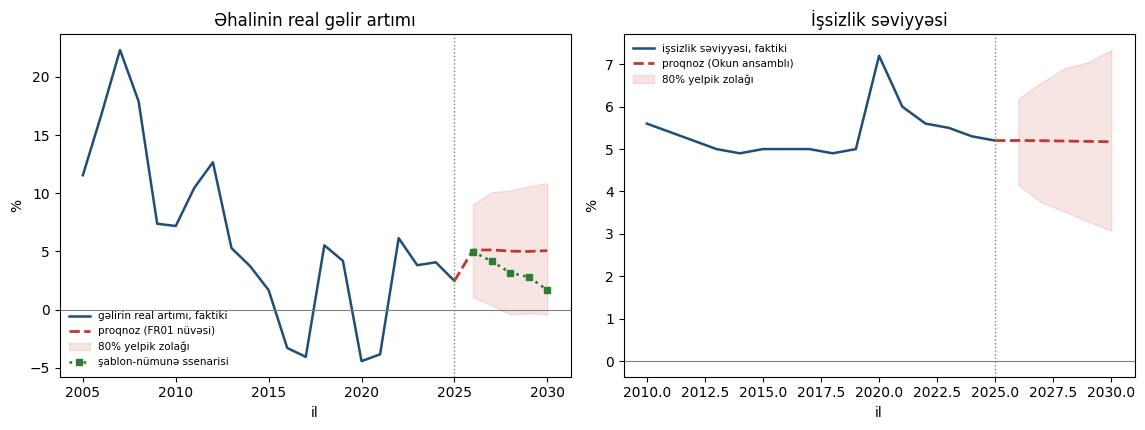

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ax = axes[0]
h = g_inc.loc[2005:]
ax.plot(h.index, h.values, "-", color="#1f4e79", lw=1.8, label="gəlirin real artımı, faktiki")
ax.plot([LA] + FY, [float(g_inc.loc[LA])] + list(g_inc_fc.values), "--", color="#c0392b", lw=2.0,
        label="proqnoz (FR01 nüvəsi)")
ax.fill_between(FY, bands_inc["lo80"], bands_inc["hi80"], color="#c0392b", alpha=0.13, label="80% yelpik zolağı")
ax.plot(mb["income_realg"].index, mb["income_realg"].values, ":", color="#2e7d32", lw=1.9, marker="s", ms=4,
        label="şablon-nümunə ssenarisi")
ax.axhline(0, color="grey", lw=0.8); ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Əhalinin real gəlir artımı"); ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(loc="lower left", frameon=False, fontsize=7.5)

ax = axes[1]
hu = u.loc[2010:]
ax.plot(hu.index, hu.values, "-", color="#1f4e79", lw=1.8, label="işsizlik səviyyəsi, faktiki")
ax.plot([LA] + FY, [float(u.loc[LA])] + list(u_fc.loc[FY].values), "--", color="#c0392b", lw=2.0,
        label="proqnoz (Okun ansamblı)")
ax.fill_between(FY, bands_u["lo80"], bands_u["hi80"], color="#c0392b", alpha=0.13, label="80% yelpik zolağı")
ax.axhline(0, color="grey", lw=0.8); ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("İşsizlik səviyyəsi"); ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(loc="upper left", frameon=False, fontsize=7.5)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR08_gelir_issizlik.png"), dpi=140)
plt.show()

## 8. Nəticələrin ixracı

FR08 aşağı axın FR-i olmadığı üçün (D2 DAG-ında yarpaq mərhələdir) `data/assumptions.csv`-ə
yeni açar yazmır. Üç fayl yazılır: proqnoz və faktiki sıralar (`outputs/forecast_long.csv`,
Nazirlik overlay-i daxil), tənliklər kataloqu (`outputs/equations_catalog.csv`) və geriyə doğru
sınaq nəticələri (yuxarıda artıq yazılıb).

In [47]:
NAMES = {
    "income_nom": ("Əhalinin pul gəlirləri", "mln AZN"),
    "income_realg": ("Əhalinin gəlirlərinin real artım tempi", "%"),
    "disposable_income": ("Sərəncamında qalan gəlirlər", "mln AZN"),
    "expend_nom": ("Əhalinin xərcləri", "mln AZN"),
    "expend_realg": ("Əhalinin xərclərinin real artım tempi", "%"),
    "final_consumption": ("Son istehlak xərcləri", "mln AZN"),
    "wage_avg": ("Orta aylıq əmək haqqı", "AZN"),
    "wage_avg_realg": ("Orta aylıq əmək haqqının real artım tempi", "%"),
    "wage_oil": ("Neft-qaz sektorunda orta aylıq əmək haqqı", "AZN"),
    "wage_nonoil": ("Qeyri neft-qaz sektorunda orta aylıq əmək haqqı", "AZN"),
    "wage_state": ("Dövlət sektorunda orta aylıq əmək haqqı", "AZN"),
    "wage_private": ("Özəl sektorda orta aylıq əmək haqqı", "AZN"),
    "paid_services": ("Əhaliyə göstərilən ödənişli xidmətlər", "mln AZN"),
    "paid_services_g": ("Ödənişli xidmətlərin real artım tempi", "%"),
    "employment": ("Ümumi məşğulluq", "min nəfər"),
    "employment_g": ("Məşğulluğun artım tempi", "%"),
    "labour_force": ("İqtisadi fəal əhalinin sayı", "min nəfər"),
    "unemployment_rate": ("İşsizlik səviyyəsi", "%"),
    "income_wage_bill": ("Gəlirin əmək ödənişləri ayağı", "mln AZN"),
    "income_transfers": ("Gəlirin transfert ayağı", "mln AZN"),
    "income_other": ("Gəlirin digər (sahibkarlıq və mülkiyyət) ayağı", "mln AZN"),
    "income_realg_v2": ("Əhalinin gəlirlərinin real artımı — v2-nin birbaşa tənliyi (alternativ)", "%"),
    "income_realg_nuve": ("Əhalinin gəlirlərinin real artımı — FR01 tələb nüvəsi (alternativ)", "%"),
    "final_consumption_realg": ("Son istehlak xərclərinin real artım tempi", "%"),
    "final_consumption_realg_nuve": ("Son istehlakın real artımı — FR01 tələb nüvəsi (alternativ)", "%"),
    "employees_moe": ("Muzdlu işçilərin sayı (sahə bloku üzrə)", "min nəfər"),
    "wage_fund_moe": ("Əmək haqqı fondu (sahə bloku üzrə)", "mln AZN"),
}

ACTUALS = {c: data_layer.actuals(c) for c in
           ["income_nom", "disposable_income", "expend_nom", "final_consumption", "wage_avg",
            "wage_oil", "wage_nonoil", "wage_state", "wage_private", "paid_services",
            "paid_services_g", "employment", "labour_force", "unemployment_rate"]}
ACTUALS["income_realg"] = g_inc.loc[:LA]
ACTUALS["expend_realg"] = g_exp.loc[:LA]
ACTUALS["wage_avg_realg"] = g_wage.loc[:LA]
ACTUALS["employment_g"] = emp_g.loc[:LA]
ACTUALS["income_wage_bill"] = DEC["wage_bill"]
ACTUALS["income_transfers"] = DEC["transfers"]
ACTUALS["income_other"] = DEC["other"]
ACTUALS["employees_moe"] = EMPL_MOE
ACTUALS["wage_fund_moe"] = FUND_MOE
ACTUALS["final_consumption_realg"] = g_cons.loc[:LA]

BANDS = {"income_realg": bands_inc, "expend_realg": None, "wage_avg_realg": bands_wage_realg,
        "paid_services_g": bands_paid_g, "unemployment_rate": bands_u}
FCAST = {
    "income_nom": inc_nom_fc.loc[FY], "income_realg": g_inc_fc,
    "disposable_income": dispo_fc, "expend_nom": exp_nom_fc, "expend_realg": exp_g_fc,
    "final_consumption": fcons_fc.loc[FY],
    "wage_avg": wage_fc.loc[FY], "wage_avg_realg": wage_realg_fc,
    "wage_oil": sector_wage_fc["wage_oil"], "wage_nonoil": sector_wage_fc["wage_nonoil"],
    "wage_state": sector_wage_fc["wage_state"], "wage_private": sector_wage_fc["wage_private"],
    "paid_services": paid_fc.loc[FY], "paid_services_g": paid_g_fc,
    "employment": emp_fc, "employment_g": emp_g_fc,
    "labour_force": lf_fc.loc[FY], "unemployment_rate": u_fc.loc[FY],
    "income_wage_bill": WB_fc.loc[FY], "income_transfers": TR_fc.loc[FY],
    "income_other": OTH_fc.loc[FY],
    "income_realg_v2": g_inc_v2_fc, "income_realg_nuve": g_inc_nuve_fc,
    "final_consumption_realg": g_cons_fc, "final_consumption_realg_nuve": g_cons_nuve_fc,
    "employees_moe": EMPL_fc.loc[FY], "wage_fund_moe": PAY_SAHE_fc.loc[FY],
}

fl = []


def _row(code, y, kind, src, v, b=None):
    nm, un = NAMES[code]
    r = {"fr": "FR8", "series_code": code, "series_name_az": nm, "unit": un, "year": int(y),
         "kind": kind, "source": src, "value": round(float(v), 6),
         "lo80": None, "hi80": None, "lo50": None, "hi50": None}
    if b is not None and y in b.index:
        for c in ("lo80", "hi80", "lo50", "hi50"):
            r[c] = round(float(b.loc[y, c]), 4)
    return r


for code, s in ACTUALS.items():
    for y, v in s.dropna().items():
        fl.append(_row(code, y, "actual", "ours", v))
for code, s in FCAST.items():
    for y, v in s.items():
        fl.append(_row(code, y, "forecast", "ours", v, BANDS.get(code)))
# şablon overlay-i YALNIZ statutar şablonda qarşılığı olan kodlar üçün oxunur — əmək haqqı → gəlir kanalının yeni
# kanal sıralarının (`income_wage_bill` və s.) şablonda qarşılığı yoxdur
for code in NAMES:
    try:
        s = data_layer.ministry_baseline(code)
    except Exception:
        continue
    for y, v in s.items():
        fl.append(_row(code, y, "forecast", "template_sample", v))
fl = pd.DataFrame(fl)
outputs.write_forecast_long(fl)
print(f"forecast_long.csv: {len(fl)} sətir yazıldı — {fl['series_code'].nunique()} sıra, "
      f"mənbələr: {sorted(fl['source'].unique())}")
fl.head(4)

forecast_long.csv: 834 sətir yazıldı — 27 sıra, mənbələr: ['ours', 'template_sample']


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
0,FR8,income_nom,Əhalinin pul gəlirləri,mln AZN,1997,actual,ours,2473.4,NaN,NaN,NaN,NaN
1,FR8,income_nom,Əhalinin pul gəlirləri,mln AZN,1998,actual,ours,2884.8,NaN,NaN,NaN,NaN
2,FR8,income_nom,Əhalinin pul gəlirləri,mln AZN,1999,actual,ours,3687.7,NaN,NaN,NaN,NaN
3,FR8,income_nom,Əhalinin pul gəlirləri,mln AZN,2000,actual,ours,4047.3,NaN,NaN,NaN,NaN


In [48]:
# DİNAMİKLİK GÖSTƏRİCİSİ — sosial blokun nəşr olunan tempi sıraları
# Sosial blokun hər üç sırası EKZOGEN sinfindədir: yolları qeyri-neft artımı və əmək haqqı
# ansamblı kimi yuxarı axının NƏŞR OLUNMUŞ yolları ilə şərtlənir, öz müstəqil dövrəviliyi yoxdur.
_dyn8 = []
for _code, _lab, _fc, _hist, _just, _cls in [
        ("income_realg", "Əhalinin real gəlirlərinin artımı", g_inc_fc,
         data_layer.actuals("income_realg"),
         "gəlirin üç ayağı da hamar sürücülərlə şərtlənir (əmək haqqı ansamblı, DSMF körpüsü, "
         "qeyri-neft nominal ÜDM); dekompozisiya kanalı açır, lakin sürücülərin dövrəviliyini "
         "yaratmır — dinamika tələbinin (ii) bəndi fərziyyə profilləri ilə bağlıdır", "ekzogen"),
        ("unemployment_rate", "İşsizlik səviyyəsi", u_fc, data_layer.actuals("unemployment_rate"),
         "Okun əlaqəsi qeyri-neft artımından gəlir; səviyyə sırasının tarixi σ-sı özü də "
         "cəmi 0,6 f.b.-dir", "ekzogen"),
        ("employment_g", "Məşğulluğun artım tempi", emp_g_fc, data_layer.actuals("employment_g"),
         "Okun əlaqəsi qeyri-neft artımından gəlir", "ekzogen")]:
    try:
        _dyn8.append(ek.sigma_ratio(pd.Series(_fc).reindex(FY), _hist, series_code=_code,
                                    label_az=_lab, justification=_just, dyn_class=_cls))
    except Exception as _e:
        print(f"  DİQQƏT: {_code} — dinamiklik göstəricisi hesablanmadı ({_e})")
if _dyn8:
    outputs.write_backtest(ek.dynamics_rows(_dyn8))
    ek.assert_dynamics_band(_dyn8, strict=False)
    outputs.publish_dynamics_notes(_dyn8)
    display(pd.DataFrame([{"sıra": r.series_code, "σ(faktiki)": round(r.sd_actual, 3),
                           "σ(proqnoz)": round(r.sd_forecast, 3),
                           "dinamiklik": round(r.ratio, 3)} for r in _dyn8]))


D2: 3 sıra üçün dinamiklik əsaslandırması seriya lüğətinə yazıldı


,sıra,σ(faktiki),σ(proqnoz),dinamiklik
0,income_realg,4.020,0.050,0.012
1,unemployment_rate,0.618,0.011,0.018
2,employment_g,0.862,0.011,0.013


In [49]:
# --- sıra lüğəti: əmək haqqı → gəlir kanalının yeni kodları ------------------------------------------------
_dict_rows = pd.DataFrame([
    {"series_code": "income_wage_bill", "name_az": "Gəlirin əmək ödənişləri ayağı",
     "name_en": "Household income: compensation of employees", "unit": "mln AZN", "fr": "FR8",
     "statutory_sheet_ref": ("Sosial sektor r041 (işçilərə əmək ödənişləri). Əmək haqqı → gəlir kanalının birinci "
                             "ayağı; sürücü — əmək haqqı fondu (orta əmək haqqı × muzdlu işçi sayı), "
                             "sahə fondu MOE SOCIAL add8-dən."), "price_basis": "cari"},
    {"series_code": "income_transfers", "name_az": "Gəlirin transfert ayağı",
     "name_en": "Household income: transfers received", "unit": "mln AZN", "fr": "FR8",
     "statutory_sheet_ref": ("Sosial sektor r044 (alınmış cari və əsaslı transfertlər). Sürücülər — "
                             "DSMF xərcləri (MOE FISCAL `Pension Fund`) və orta aylıq pensiya."),
     "price_basis": "cari"},
    {"series_code": "income_other", "name_az": "Gəlirin digər (sahibkarlıq və mülkiyyət) ayağı",
     "name_en": "Household income: entrepreneurial and property income", "unit": "mln AZN", "fr": "FR8",
     "statutory_sheet_ref": ("Sosial sektor r042 + r043. Sürücü — qeyri-neft ÜDM, nominal (real_r005). "
                             "QALIQ DEYİL: öz tənliyi var və eynilik onsuz da qapanır."),
     "price_basis": "cari"},
    {"series_code": "income_realg_v2",
     "name_az": "Əhalinin gəlirlərinin real artımı — v2-nin birbaşa tənliyi (alternativ)",
     "name_en": "Real household income growth — v2 direct equation (alternative)", "unit": "%", "fr": "FR8",
     "statutory_sheet_ref": ("ALTERNATİV İZ: income_realg ← nonoil_realg. §6.6 yarışında "
                             "dekompozisiyaya uduzdu (RMSE 4,269 vs 3,024/3,291); silinmir, nəşr olunur."),
     "price_basis": "indeks"},
    {"series_code": "income_realg_nuve",
     "name_az": "Əhalinin gəlirlərinin real artımı — FR01 tələb nüvəsi (alternativ)",
     "name_en": "Real household income growth — FR01 demand core (alternative)", "unit": "%", "fr": "FR8",
     "statutory_sheet_ref": ("ALTERNATİV İZ: `g_income_core` açarı. istehsal metoduna keçiddən sonra nüvə "
                             "alternativ oxunuşdur; mərkəzi yol §7.6-nın dekompozisiyasıdır."),
     "price_basis": "indeks"},
    {"series_code": "final_consumption_realg", "name_az": "Son istehlak xərclərinin real artım tempi",
     "name_en": "Real growth of final consumption", "unit": "%", "fr": "FR8",
     "statutory_sheet_ref": ("GÖNDƏRİLƏN yol: MPC tənliyi × §7.6-nın dekompozisiya gəlir yolu"),
     "price_basis": "indeks"},
    {"series_code": "final_consumption_realg_nuve",
     "name_az": "Son istehlakın real artımı — FR01 tələb nüvəsi (alternativ)",
     "name_en": "Real final consumption growth — FR01 demand core (alternative)", "unit": "%", "fr": "FR8",
     "statutory_sheet_ref": ("ALTERNATİV İZ: `g_cons_core` açarı — FR04 və FR07 hələ bu yolu sürücü "
                             "kimi oxuyur; fərq §10-da ədədlə verilir."), "price_basis": "indeks"},
    {"series_code": "employees_moe", "name_az": "Muzdlu işçilərin sayı (sahə bloku üzrə)",
     "name_en": "Employees (from the branch labour block)", "unit": "min nəfər", "fr": "FR8",
     "statutory_sheet_ref": data_layer.MOE_SOCIAL_SOURCE_NOTE + "; törəmə: fond×1000/(12×əmək haqqı), "
                            "2025 DVX artım tempi ilə tamamlanıb", "price_basis": "indeks"},
    {"series_code": "wage_fund_moe", "name_az": "Əmək haqqı fondu (sahə bloku üzrə)",
     "name_en": "Wage fund (branch labour block)", "unit": "mln AZN", "fr": "FR8",
     "statutory_sheet_ref": data_layer.MOE_SOCIAL_SOURCE_NOTE, "price_basis": "cari"},
])
outputs.write_series_dictionary(_dict_rows)
print(f"sıra lüğətinə {len(_dict_rows)} yeni kod yazıldı")

sıra lüğətinə 9 yeni kod yazıldı


### 8.1. Təsviri sıralar — yalnız faktiki tarixçə

Sıra lüğətində FR8-ə aid on beş kod var ki, bu təhvildə onlar üçün davranış tənliyi qurulmur:
fəaliyyət növləri üzrə orta aylıq əmək haqqı və muzdlu işçilərin orta siyahı sayı (`Mədənçıxarma`,
`Emal Sənayesi`, `Elektrik enerjisi, qaz və buxar istehsalı`, `Su təchizatı` vərəqləri, 2016–2025) və
Dövlət Vergi Xidmətinin göstəriciləri (`DVX üzrə göstəricilər` vərəqi, 2021–2025) — əmək haqqı fondu
(cəmi, qeyri-neft, qeyri-neft qeyri-dövlət), orta aylıq əmək haqqı və muzdla işləyənlərin sayı. Həmin
kodlar `outputs/forecast_long.csv` faylına yalnız `kind='actual'`, `source='ours'` sətirləri ilə daxil
edilir: **təsviri sıra — proqnoz verilmir**.

DVX sıralarının nümunəsi beş müşahidədir (2021–2025). Belə qısa nümunə üzərində elastiklik
qiymətləndirilmir və proqnoz nəşr olunmur; həmin sıralar yalnız **lövbər və çarpaz yoxlama** üçün
saxlanılır — bu, nümunə intizamı qaydasıdır və sıra lüğətinin izah sütununda da yazılıb. Sahə
vərəqlərinin on illik sıraları bu buraxılışda MOE SOCIAL-ın 19 fəaliyyət növü üzrə bloku ilə
əvəzlənib (§2.4, 1999–2024) və əmək haqqı fondu kanalında (§5.7, §6.6) istifadə olunur; iş kitabının
öz sahə vərəqləri isə çarpaz yoxlama kimi burada təsviri sıra olaraq qalır.


In [50]:
# Təsviri sıralar (§8.1): 15 kod üçün YALNIZ faktiki tarixçə nəşr olunur — proqnoz sətri yazılmır.
# Diqqət: `write_forecast_long` əhatəni `fr` sütunu üzrə yerinə-yazır, ona görə təsviri sətirlər
# yuxarıdakı `fl` partiyası ilə BİR çağırışda yazılır (ayrıca çağırış FR8-in qalan sətirlərini silərdi).
DESC_CODES = [
    "wage_mining", "wage_manuf", "wage_power", "wage_water",          # sahə vərəqləri, 2016–2025
    "emp_mining", "emp_manuf", "emp_power", "emp_water",
    "wage_avg_dvx", "wage_avg_nonoil_dvx", "wage_fund_total",         # DVX vərəqi, 2021–2025
    "wage_fund_nonoil", "wage_fund_nonoil_nonstate",
    "employees_dvx", "employees_nonoil_dvx",
]
_cat = data_layer.catalog().set_index("series_code")
desc_rows = []
for _code in DESC_CODES:
    _meta = _cat.loc[_code]
    _s = data_layer.actuals(_code).dropna()        # data_layer HƏMİŞƏ ≤ 2025 qaytarır (D1)
    assert int(_s.index.max()) <= config.LAST_ACTUAL, _code
    for _y, _v in _s.items():
        desc_rows.append({"fr": "FR8", "series_code": _code,
                          "series_name_az": str(_meta["name_az"]), "unit": str(_meta["unit"]),
                          "year": int(_y), "kind": "actual", "source": "ours",
                          "value": round(float(_v), 6),
                          "lo80": None, "hi80": None, "lo50": None, "hi50": None})
# yelpik sütunları bu sıralarda həmişə boşdur — tipi AÇIQ float verilir ki, birləşdirmə
# zamanı sütun tipi pandas tərəfindən təxmin edilməsin.
desc = pd.DataFrame(desc_rows).astype({"lo80": "float64", "hi80": "float64",
                                       "lo50": "float64", "hi50": "float64"})
# --- MÜLKİYYƏT × FƏALİYYƏT NÖVÜ PANELİ (bu buraxılış) — 120 sıra, 2005-2025 ---------------------
SSC_BRANCH_AZ = {
    "total": "İqtisadiyyat üzrə, cəmi",
    "agri": "Kənd, meşə və balıqçılıq təsərrüfatı", "mining": "Mədənçıxarma sənayesi",
    "manuf": "Emal sənayesi",
    "power": "Elektrik enerjisi, qaz və buxar istehsalı, bölüşdürülməsi və təchizatı",
    "water": "Su təchizatı; tullantıların təmizlənməsi və emalı", "constr": "Tikinti",
    "trade": "Ticarət; nəqliyyat vasitələrinin təmiri",
    "transport": "Nəqliyyat və anbar təsərrüfatı",
    "tourism": "Turistlərin yerləşdirilməsi və ictimai iaşə",
    "ict": "İnformasiya və rabitə", "finance": "Maliyyə və sığorta fəaliyyəti",
    "realest": "Daşınmaz əmlakla əlaqədar əməliyyatlar",
    "prof": "Peşə, elmi və texniki fəaliyyət",
    "admin": "İnzibati və yardımçı xidmətlərin göstərilməsi",
    "pubadm": "Dövlət idarəetmə və müdafiə; sosial təminat", "educ": "Təhsil",
    "health": "Əhaliyə səhiyyə və sosial xidmətlərin göstərilməsi",
    "art": "İstirahət, əyləncə və incəsənət sahəsində fəaliyyət",
    "other": "Digər sahələrdə xidmətlərin göstərilməsi",
}
SSC_BRANCH_EN = dict(data_layer.SSC_ACTIVITY_ROWS)
OWN_AZ = {"": "cəmi", "_state": "dövlət", "_nonstate": "qeyri-dövlət"}
OWN_EN = {"": "total", "_state": "state", "_nonstate": "non-state"}

panel_rows, panel_dict = [], []
for _b in ["total"] + BR_CODES:
    for _suf in ("", "_state", "_nonstate"):
        for _pref, _src, _unit, _nm_az, _nm_en in (
                ("wage_ssc", WPAN, "AZN", "orta aylıq nominal əmək haqqı",
                 "average monthly nominal wage"),
                ("emp_ssc", EPAN, "min nəfər", "muzdlu işçilərin sayı",
                 "number of employees")):
            _code = f"{_pref}_{_b}{_suf}"
            _name = f"{SSC_BRANCH_AZ[_b]} — {_nm_az}, {OWN_AZ[_suf]} (DSK)"
            for _y, _v in _src[_code].dropna().items():
                panel_rows.append({"fr": "FR8", "series_code": _code, "series_name_az": _name,
                                   "unit": _unit, "year": int(_y), "kind": "actual",
                                   "source": "ours", "value": round(float(_v), 6),
                                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
            panel_dict.append({
                "series_code": _code, "name_az": _name,
                "name_en": f"{SSC_BRANCH_EN[_b]} — {_nm_en}, {OWN_EN[_suf]} (SSC)",
                "unit": _unit, "fr": "FR8",
                "price_basis": ("cari" if _pref == "wage_ssc" else "natural"),
                "statutory_sheet_ref": (
                    ("DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics`), 2005–2024"
                     if _pref == "wage_ssc" else
                     "DSK cədvəl 2.12 (`002_12-13en.xls`, `Dynamics_2.12`), 2005–2024")
                    + f"; {LA} sütunu DVX/iş kitabı qarşılığı ilə tamamlanıb (FR08 §2.5) — "
                      "həmin il üçün fəaliyyət növləri arasında tərkib effekti sıfırdır")})

panel = pd.DataFrame(panel_rows).astype({"lo80": "float64", "hi80": "float64",
                                         "lo50": "float64", "hi50": "float64"})
outputs.write_forecast_long(pd.concat([fl, desc, panel], ignore_index=True))
outputs.write_series_dictionary(pd.DataFrame(panel_dict))
print(f"mülkiyyət × fəaliyyət növü paneli: {panel['series_code'].nunique()} sıra, "
      f"{len(panel)} faktiki sətir ({int(panel['year'].min())}-{int(panel['year'].max())}) — "
      "ANNEX2 sətir 17(iii) bağlanır")

print(f"təsviri sıralar: {desc['series_code'].nunique()} kod, {len(desc)} faktiki sətir "
      f"— proqnoz verilmir")
print("DVX (5 müşahidə) lövbər qeydi:", str(_cat.loc["wage_fund_total", "note"]))
desc.groupby("series_code").agg(**{"sətir": ("year", "size"), "ilk il": ("year", "min"),
                                   "son il": ("year", "max")})


mülkiyyət × fəaliyyət növü paneli: 120 sıra, 2520 faktiki sətir (2005-2025) — ANNEX2 sətir 17(iii) bağlanır
təsviri sıralar: 15 kod, 115 faktiki sətir — proqnoz verilmir
DVX (5 müşahidə) lövbər qeydi: DVX vərəqi, 2021–2025 (5 illik müşahidə) — lövbər və çarpaz yoxlama üçündür; bu qısa nümunə üzərində elastiklik qiymətləndirilmir.


,sətir,ilk il,son il
series_code,,,
emp_manuf,10,2016,2025
emp_mining,10,2016,2025
emp_power,10,2016,2025
emp_water,10,2016,2025
employees_dvx,5,2021,2025
employees_nonoil_dvx,5,2021,2025
wage_avg_dvx,5,2021,2025
wage_avg_nonoil_dvx,5,2021,2025
wage_fund_nonoil,5,2021,2025


In [51]:
cat_rows = pd.DataFrame([
    res_cons.catalog_row(eq_name="FR8_mpc",
        description=("STRUKTUR (göndərilir): son istehlak — real gəlirdən keçid (MPC); §7.6-da istehlak "
                     "GÖNDƏRİLƏN gəlir yoluna (dekompozisiya) yenidən bağlanır — FR01 nüvəsinin yolu "
                     "`final_consumption_nuve` kodu ilə alternativ iz kimi nəşr olunur"),
        lhs="final_consumption", series_code="final_consumption", fr="FR8", workbook=WB, sheet="macro_annual.csv"),
    res_inc.catalog_row(eq_name="FR8_gelir_v2_birbasa",
        description=("ALTERNATİV (göndərilmir): əhalinin real gəlirləri ← qeyri-neft artımı, v2-nin "
                     "birbaşa tənliyi; §6.6 yarışında dekompozisiyaya uduzdu — RMSE {:.3f} vs {:.3f} "
                     "(sahə) / {:.3f} (aqreqat), RW {:.3f}; yolu `income_realg_v2` kodu ilə nəşr olunur").format(
            bt_race.rmse["V2_BIRBASA"], bt_race.rmse["DEKOMPOZISIYA_SAHE"],
            bt_race.rmse["DEKOMPOZISIYA_AQREQAT"], bt_race.rw_rmse),
        lhs="income_realg_v2", series_code="income_realg_v2", fr="FR8", workbook=WB, sheet="Real sektor"),
    res_wb_sahe.catalog_row(eq_name="FR8_gelir_ayaq_emek_odenisleri_sahe",
        description=("STRUKTUR (göndərilir, çəki {:.2f}): Δln əmək ödənişləri ← Δln əmək haqqı fondu, "
                     "fond SAHƏ qurulmasından (MOE SOCIAL muzdlu işçi sayı); ayaq sınağında RMSE "
                     "{:.4f} (aqreqat qurulması {:.4f}, RW {:.4f})").format(
            bt_wb_leg.weights.get("SAHE_FONDU", 0.0), bt_wb_leg.rmse["SAHE_FONDU"],
            bt_wb_leg.rmse["AQREQAT_FONDU"], bt_wb_leg.rw_rmse),
        lhs="income_wage_bill", series_code="income_wage_bill", fr="FR8", workbook=WB,
        sheet="Sosial sektor", rhs="wage_avg × employees_moe"),
    res_wb_agg.catalog_row(eq_name="FR8_gelir_ayaq_emek_odenisleri_aqreqat",
        description=("STRUKTUR (göndərilir, çəki {:.2f}): Δln əmək ödənişləri ← Δln əmək haqqı fondu, "
                     "fond AQREQAT qurulmasından (orta əmək haqqı × ümumi məşğulluq)").format(
            bt_wb_leg.weights.get("AQREQAT_FONDU", 0.0)),
        lhs="income_wage_bill", series_code="income_wage_bill", fr="FR8", workbook=WB,
        sheet="Sosial sektor", rhs="wage_avg × employment"),
    res_tr_dsmf.catalog_row(eq_name="FR8_gelir_ayaq_transfertler_dsmf",
        description=("STRUKTUR (göndərilir, çəki {:.2f}): Δln alınmış transfertlər ← Δln DSMF xərcləri; "
                     "ayaq sınağında RMSE {:.4f} (RW {:.4f})").format(
            bt_tr_leg.weights.get("DSMF", 0.0), bt_tr_leg.rmse["DSMF"], bt_tr_leg.rw_rmse),
        lhs="income_transfers", series_code="income_transfers", fr="FR8", workbook=WB,
        sheet="MOE FISCAL `Pension Fund`", rhs="DSMF xərcləri"),
    res_tr_pens.catalog_row(eq_name="FR8_gelir_ayaq_transfertler_pensiya",
        description=("STRUKTUR (göndərilir, çəki {:.2f}): Δln alınmış transfertlər ← Δln orta aylıq "
                     "pensiya").format(bt_tr_leg.weights.get("PENSIYA", 0.0)),
        lhs="income_transfers", series_code="income_transfers", fr="FR8", workbook=WB,
        sheet="Sosial sektor", rhs="social_r071"),
    res_oth.catalog_row(eq_name="FR8_gelir_ayaq_diger",
        description=("STRUKTUR (göndərilir): Δln sahibkarlıq + mülkiyyət gəlirləri ← Δln qeyri-neft ÜDM "
                     "(nominal); elastiklik vahiddən böyükdür — ayaq QALIQ kimi qoyulmur"),
        lhs="income_other", series_code="income_other", fr="FR8", workbook=WB,
        sheet="Real sektor", rhs="real_r005"),
    res_bridge.catalog_row(eq_name="FR8_dsmf_korpu",
        description=("KÖRPÜ: Δln DSMF xərcləri ← Δln orta aylıq pensiya (nominal). DSMF sırası 2024-də "
                     "bitdiyi üçün proqnoz üfüqündə transfert ayağının sürücüsü bu tənliklə qurulur"),
        lhs="income_transfers", series_code="income_transfers", fr="FR8", workbook=WB,
        sheet="MOE FISCAL `Pension Fund`", rhs="social_r071"),
    res_wage_cpi.catalog_row(eq_name="FR8_emek_haqqi_iqi",
        description="DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ — zəif, illik indeksləşdirmə yoxdur",
        lhs="wage_avg", series_code="wage_avg", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_wage_dstep.catalog_row(eq_name="FR8_emek_haqqi_pille",
        description=("DİAQNOSTİK: nominal əmək haqqı artımı ~ İQİ + statistik müəyyən olunmuş sıçrayış "
                     "süni dəyişəni (2019, 2022) — yalnız tarixi izah üçün, proqnozda istifadə edilmir"),
        lhs="wage_avg", series_code="wage_avg", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_ratio_wage_oil.catalog_row(eq_name="FR8_pay_neft_emek_haqqi",
        description="ROBUSTLİK: neft-qaz/orta əmək haqqı nisbəti ~ trend — əhəmiyyətsiz, son 3 il ortası saxlanılır",
        lhs="wage_oil", series_code="wage_oil", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_ratio_wage_nonoil.catalog_row(eq_name="FR8_pay_qeyrineft_emek_haqqi",
        description="STRUKTUR: qeyri-neft/orta əmək haqqı nisbəti ~ trend — əhəmiyyətli, artan",
        lhs="wage_nonoil", series_code="wage_nonoil", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_ratio_wage_state.catalog_row(eq_name="FR8_pay_dovlet_emek_haqqi",
        description="STRUKTUR: dövlət/orta əmək haqqı nisbəti ~ trend — əhəmiyyətli, artan (yaxınlaşma)",
        lhs="wage_state", series_code="wage_state", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_ratio_wage_private.catalog_row(eq_name="FR8_pay_ozel_emek_haqqi",
        description="STRUKTUR: özəl/orta əmək haqqı nisbəti ~ trend — əhəmiyyətli, enən (yaxınlaşma)",
        lhs="wage_private", series_code="wage_private", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_okun_u.catalog_row(eq_name="FR8_okun_issizlik",
        description=("STRUKTUR: işsizlik səviyyəsinin dəyişməsi (Okun) ~ qeyri-neft artımı — tam nümunə "
                     "əmsalı zəif (t<2), lakin geriyə doğru sınaqda RW-ni dar fərqlə üstələyir"),
        lhs="unemployment_rate", series_code="unemployment_rate", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_okun_e.catalog_row(eq_name="FR8_okun_meshgulluq",
        description=("STRUKTUR: məşğulluğun artım tempi (Okun) ~ qeyri-neft artımı — tam nümunə əmsalı "
                     "zəif (t<2); şərh üçün saxlanılır, proqnoz eynilik (fəal əhali × (1-işsizlik)) ilə aparılır"),
        lhs="employment_g", series_code="employment_g", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_paid.catalog_row(eq_name="FR8_odenişli_xidmet",
        description="STRUKTUR: ödənişli xidmətlərin real artımı ~ son istehlakın real artımı; elastiklik > 1",
        lhs="paid_services_g", series_code="paid_services_g", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_dispo.catalog_row(eq_name="FR8_serencam_pay",
        description="STRUKTUR: sərəncamdakı gəlir / pul gəliri nisbəti ~ trend — əhəmiyyətli, enən, son illər sabit",
        lhs="disposable_income", series_code="disposable_income", fr="FR8", workbook=WB, sheet="Sosial sektor"),
    res_fcexp.catalog_row(eq_name="FR8_istehlak_xerc_pay",
        description="ROBUSTLİK: son istehlak / pul xərci nisbəti ~ trend — əhəmiyyətsiz, son 3 il ortası saxlanılır",
        lhs="final_consumption", series_code="final_consumption", fr="FR8", workbook=WB, sheet="macro_annual.csv"),
])
outputs.write_equations_catalog(cat_rows)
cat_rows[["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2", "se_regression"]]

,eq_name,lhs,rhs,sample_start,sample_end,adj_r2,se_regression
0,FR8_mpc,final_consumption,g_inc,2001,2025,0.6628,3.2608
1,FR8_gelir_v2_birbasa,income_realg_v2,nonoil,2001,2025,0.5755,4.5107
2,FR8_gelir_ayaq_emek_odenisleri_sahe,income_wage_bill,wage_avg × employees_moe,2001,2025,0.6416,0.0552
3,FR8_gelir_ayaq_emek_odenisleri_aqreqat,income_wage_bill,wage_avg × employment,2001,2025,0.5206,0.0638
4,FR8_gelir_ayaq_transfertler_dsmf,income_transfers,DSMF xərcləri,2001,2024,0.2076,0.1149
5,FR8_gelir_ayaq_transfertler_pensiya,income_transfers,social_r071,2001,2025,-0.0331,0.1297
6,FR8_gelir_ayaq_diger,income_other,real_r005,2001,2025,0.6862,0.0723
7,FR8_dsmf_korpu,income_transfers,social_r071,2001,2024,0.3576,0.0973
8,FR8_emek_haqqi_iqi,wage_avg,cpi,2011,2025,-0.0501,4.0582
9,FR8_emek_haqqi_pille,wage_avg,cpi + dstep,2011,2025,0.4811,2.8526


In [52]:
v = validate.Verifier("FR08 — Əhalinin gəlirləri və xərcləri")

# 1. məşğulluq eyniliyi HƏR proqnoz ilində
v.identity("məşğulluq = fəal əhali × (1 − işsizlik/100), 2026-2030", emp_fc,
          lf_fc.loc[FY] * (1 - u_fc.loc[FY] / 100), tol=1e-8)

# 2. sərəncamdakı gəlir eyniliyi
v.identity("sərəncamdakı gəlir = pul gəliri × nisbət", dispo_fc,
          inc_nom_fc.loc[FY] * ratio_dispo_fc, tol=1e-8)

# 3. pul xərci eyniliyi
v.identity("pul xərci = son istehlak / nisbət", exp_nom_fc, fcons_fc.loc[FY] / RATIO_FCEXP, tol=1e-8)

# 4. nominal zəncir eyniliyi — gəlir
v.identity("pul gəliri: V(t) = V(t-1)(1+g)(1+π)", inc_nom_fc.loc[FY],
          pd.Series({y: inc_nom_fc.loc[y - 1] * (1 + float(g_inc_fc.loc[y]) / 100) * (1 + float(cpi_fc.loc[y]) / 100)
                     for y in FY}), tol=1e-6, rel_tol=1e-12)

# 5. nominal zəncir eyniliyi — son istehlak
v.identity("son istehlak: V(t) = V(t-1)(1+g)(1+π)", fcons_fc.loc[FY],
          pd.Series({y: fcons_fc.loc[y - 1] * (1 + float(g_cons_fc.loc[y]) / 100) * (1 + float(cpi_fc.loc[y]) / 100)
                     for y in FY}), tol=1e-6, rel_tol=1e-12)

# 6. əmək haqqı ansamblının çəkiləri cəmi 1-dir
v.close("əmək haqqı ansamblının çəkiləri cəmi = 1", sum(bt_wage.weights.values()), 1.0, tol=1e-12)

# 7. işsizlik ansamblının çəkiləri cəmi 1-dir
v.close("işsizlik ansamblının çəkiləri cəmi = 1", sum(bt_u.weights.values()), 1.0, tol=1e-12)

# 8. ödənişli xidmətlərin nominal zənciri
v.identity("ödənişli xidmətlər: V(t) = V(t-1)(1+g)(1+π)", paid_fc.loc[FY],
          pd.Series({y: paid_fc.loc[y - 1] * (1 + float(paid_g_fc.loc[y]) / 100) * (1 + float(cpi_fc.loc[y]) / 100)
                     for y in FY}), tol=1e-6, rel_tol=1e-12)

# 9. müstəqil yenidən hesablama: 2026 üçün MPC + gəlir tənliyinin əl ilə həlli FR01-in yolu ilə üst-üstə düşür
def _yeniden_hesabla_gelir_2026():
    dY = S.loc[2001:LA, ["g_inc", "nonoil"]].dropna()
    bY = np.linalg.lstsq(np.column_stack([np.ones(len(dY)), dY[["nonoil"]].values]), dY["g_inc"].values, rcond=None)[0]
    return float(bY[0] + bY[1] * float(nonoil_fc.loc[FY[0]]))

v.ok("2026 gəlir tənliyinin (bu dəftərin öz qiymətləndirməsi) əmsalları FR01-in nüvə əmsallarına yaxındır",
     abs(_yeniden_hesabla_gelir_2026() - float(res_inc.params["const"] + res_inc.params["nonoil"] * nonoil_fc.loc[FY[0]])) < 1e-6)

# 10. 80% zolağı mərkəzi yolu əhatə edir
v.ok("işsizlik 80% zolağı mərkəzi yolu əhatə edir",
     bool(((bands_u["lo80"] < u_fc.loc[FY].values) & (bands_u["hi80"] > u_fc.loc[FY].values)).all()))
v.ok("ödənişli xidmətlər 80% zolağı mərkəzi yolu əhatə edir",
     bool(((bands_paid_g["lo80"] < paid_g_fc.values) & (bands_paid_g["hi80"] > paid_g_fc.values)).all()))

# 11. gələcəyə baxış yoxdur — bütün qiymətləndirmə nümunələri
for nm, idx in [("MPC", sC.index), ("gəlir tənliyi", sY.index), ("əmək haqqı/İQİ", sW0.index),
                ("Okun/işsizlik", sU.index), ("Okun/məşğulluq", sE.index), ("ödənişli xidmətlər", sP.index),
                ("sərəncamdakı pay", ratio_dispo.index), ("istehlak/xərc payı", ratio_fcexp.index)]:
    v.no_lookahead(nm, idx)

# 12. ƏMƏK HAQQI → GƏLİR KANALI — gəlir eyniliyi HƏR faktiki və HƏR proqnoz ilində
v.identity("gəlir = əmək ödənişləri + transfertlər + digər (faktiki, 2000-2025)",
          DEC["income"], DEC["wage_bill"] + DEC["transfers"] + DEC["other"], tol=1e-6)
v.identity("gəlir = əmək ödənişləri + transfertlər + digər (proqnoz, 2026-2030)",
          INC_fc.loc[FY], (WB_fc + TR_fc + OTH_fc).loc[FY], tol=1e-6, rel_tol=1e-12)

# 13. göndərilən nominal gəlir səviyyəsi dekompozisiyanın cəmi ilə eynidir
v.identity("pul gəliri (§7.7 zənciri) = dekompozisiyanın cəmi", inc_nom_fc.loc[FY],
          INC_fc.loc[FY], tol=1e-4, rel_tol=1e-9)

# 14. əmək haqqı fondu eyniliyi: fond = əmək haqqı × muzdlu işçi × 12 / 1000
v.identity("əmək haqqı fondu = əmək haqqı × muzdlu işçi sayı × 12 / 1000 (proqnoz)",
          PAY_SAHE_fc.loc[FY], (wage_fc.loc[FY] * EMPL_fc.loc[FY] * 12 / 1000), tol=1e-8)

# 15. sahə fondunun cəmi = MOE-nin öz aqreqat fond sətri (faktiki, hər il)
# dözüm 1e-3 mln AZN (= 1000 AZN): sabit cədvəldəki dəyərlər 6 onluq rəqəmə yuvarlaqlaşdırılıb,
# 19 sətrin cəmində yuvarlaqlaşdırma xətası 1e-6 mln AZN-ə çata bilər — iqtisadi məzmunu yoxdur
v.identity("19 sahənin fondu = add8 aqreqat fond sətri (2000-2024)",
          FUND_MOE.dropna(), data_layer.moe_social_aggregates()["fund_total"].dropna(),
          tol=1e-3, rel_tol=1e-9)

# 16. ayaq ansambl çəkiləri cəmi 1-dir
v.close("əmək ödənişləri ayağının çəkiləri cəmi = 1", sum(bt_wb_leg.weights.values()), 1.0, tol=1e-12)
v.close("transfert ayağının çəkiləri cəmi = 1", sum(bt_tr_leg.weights.values()), 1.0, tol=1e-12)
v.close("digər gəlirlər ayağının çəkiləri cəmi = 1", sum(bt_oth_leg.weights.values()), 1.0, tol=1e-12)

# 17. MOE bloku proqnoz sütunu daşımır
v.ok("MOE SOCIAL bloku yalnız faktiki sütunları (<=2024) daşıyır",
     int(MOE_W.index.max()) <= 2024 and int(MOE_L.index.max()) <= 2024
     and int(MOE_FUND.index.max()) <= 2024 and int(data_layer.moe_sspf().index.max()) <= 2024)

# 18. göndərilən yol yarışın qalibidir (dürüstlük yoxlaması — şərtsiz iddia deyil, sınağın nəticəsi)
v.ok("dekompozisiya yarışda v2-nin birbaşa tənliyini üstələyir",
     min(bt_race.rmse["DEKOMPOZISIYA_SAHE"], bt_race.rmse["DEKOMPOZISIYA_AQREQAT"])
     < bt_race.rmse["V2_BIRBASA"] < bt_race.rw_rmse)

for nm, idx in [("əmək haqqı → gəlir kanalı — ayaq tənlikləri", K.loc[2001:LA].index),
                ("əmək haqqı → gəlir kanalı — sahə əmək bloku", MOE_W.index),
                ("əmək haqqı → gəlir kanalı — DSMF", data_layer.moe_sspf().index)]:
    v.no_lookahead(nm, idx)

# --- bu buraxılış: mülkiyyət × fəaliyyət növü paneli -------------------------------------------
for _suf in ("", "_state", "_nonstate"):
    v.identity(f"məşğulluq: 19 fəaliyyət növünün cəmi = iqtisadiyyat sətri ({_suf or 'cəmi'})",
               sum(ESSC[f"emp_ssc_{b}{_suf}"] for b in BR_CODES),
               ESSC[f"emp_ssc_total{_suf}"], tol=1e-6)
v.identity("məşğulluq: dövlət + qeyri-dövlət = cəmi",
           ESSC["emp_ssc_total_state"] + ESSC["emp_ssc_total_nonstate"],
           ESSC["emp_ssc_total"], tol=1e-6)
v.identity("iş kitabının dövlət sektoru əmək haqqı = DSK panelinin iqtisadiyyat sətri (2005-2024)",
           wage_state.loc[2005:2024], WSSC["wage_ssc_total_state"].loc[2005:2024], tol=5e-4)
v.identity("iş kitabının özəl sektor əmək haqqı = DSK panelinin qeyri-dövlət sətri (2005-2024)",
           wage_private.loc[2005:2024], WSSC["wage_ssc_total_nonstate"].loc[2005:2024], tol=5e-4)
v.close(f"spliced panelin {LA} dövlət sətri iş kitabının öz dəyərinə bərabərdir",
        float(WPAN.loc[LA, "wage_ssc_total_state"]), float(wage_state.loc[LA]), tol=1e-6)
v.ok("sektor pay qaydası artıq sınaqla seçilir (dörd sektorun hamısında)",
     all(bool(RATIO_BT[c].weights) for c in RATIO_BT),
     "; ".join(f"{c}: {', '.join(RATIO_BT[c].weights)}" for c in RATIO_BT))

v.assert_all()

  YOXLAMA: FR08 — Əhalinin gəlirləri və xərcləri
  [PASS] eynilik: məşğulluq = fəal əhali × (1 − işsizlik/100), 2026-2030
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: sərəncamdakı gəlir = pul gəliri × nisbət
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: pul xərci = son istehlak / nisbət
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: pul gəliri: V(t) = V(t-1)(1+g)(1+π)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: son istehlak: V(t) = V(t-1)(1+g)(1+π)
         5 il, maksimal fərq 0.000e+00
  [PASS] əmək haqqı ansamblının çəkiləri cəmi = 1
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] işsizlik ansamblının çəkiləri cəmi = 1
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] eynilik: ödənişli xidmətlər: V(t) = V(t-1)(1+g)(1+π)
         5 il, maksimal fərq 0.000e+00
  [PASS] 2026 gəlir tənliyinin (bu dəftərin öz qiymətləndirməsi) əmsalları FR01-in nüvə əmsallarına yaxındır
  [PASS] işsizlik 80% zolağı mərkəzi yolu əhatə edir
  [PASS] ödəniş

In [53]:
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
eq_disk = pd.read_csv(os.path.join(config.OUT, "equations_catalog.csv"))
bt_disk = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
print("forecast_long.csv, FR8 sətirləri     :", int((fl_disk["fr"] == "FR8").sum()))
print("  o cümlədən şablon overlay-i        :",
      int(((fl_disk["fr"] == "FR8") & (fl_disk["source"] == "template_sample")).sum()))
print("equations_catalog.csv, FR8 sətirləri :", int((eq_disk["fr"] == "FR8").sum()))
need_bt = ["final_consumption", "income_realg", "wage_avg", "unemployment_rate", "employment_g", "paid_services_g"]
print("validation_backtest.csv, FR8 sıraları:", int(bt_disk["series_code"].isin(need_bt).sum()))
have_series = set(fl_disk.loc[fl_disk["fr"] == "FR8", "series_code"])
assert set(NAMES.keys()) <= have_series, sorted(set(NAMES.keys()) - have_series)
print("bütün 18 sıra forecast_long.csv-də mövcuddur.")

forecast_long.csv, FR8 sətirləri     : 3469
  o cümlədən şablon overlay-i        : 60
equations_catalog.csv, FR8 sətirləri : 19
validation_backtest.csv, FR8 sıraları: 288
bütün 18 sıra forecast_long.csv-də mövcuddur.


## 9. Məhdudiyyətlər

**Əmək haqqının sıçrayış illəri proqnozlaşdırıla bilmir.** §5.2-də göstərilən süni dəyişənli
tənlik tarixi məlumatı çox yaxşı izah edir (R² = 0,555), lakin gələcək sıçrayış illərinin nə vaxt
olacağı bu paketin bilik dəstindən kənardır — inzibati qərardır. Proqnoz ona görə hamarlanmış
indeksləşdirmə ansamblı ilə aparılır; konkret bir ilində real inzibati artım olarsa, həmin ilin
faktiki nəticəsi mərkəzi yoldan kənara çıxa bilər (80% zolağı bunun bir hissəsini əhatə edir,
hamısını yox).

**Yelpik zolaqlarının üfüq qaydası bu buraxılışda düzəldilib.** `ek.fan` susmaya görə qalıq
şoklarını üfüq boyu YIĞIR (σ_h = σ₁·√h) — bu, SƏVİYYƏ qaydasıdır və işsizlik səviyyəsi üçün
doğrudur, lakin gəlir, istehlak və ödənişli xidmətlərin zolaqları ARTIM TEMPİ sıralarıdır:
onlar orta qiymətə qayıdır və xətaları yığılmır (paketin FR01 Bölmə 7.3 və FR06 Bölmə 7.6
qaydası). Əvvəlki buraxılışda gəlir zolağı h = 1-dən h = 5-ə 2,29 dəfə, ödənişli xidmətlər
zolağı 2,14 dəfə genişlənirdi — qayıdış qaydasının verdiyi 1,39 və 1,30 dəfəsi əvəzinə, yəni
təxminən **65 % artıq geniş** idi; əmək haqqı zolağı isə əksinə, ümumiyyətlə genişlənmirdi.
İndi hər üçü sıranın öz AR(1) əmsalı ilə qayıdış qaydası üzrə qurulur. Əlavə olaraq, parametr
qeyri-müəyyənliyi ötürülərkən `X_future` dizayn sətri verilir — əvvəllər verilmirdi və
`ek.fan` sənədinə görə əmsal sapması VAHİD vektorla ötürülürdü. **Mərkəzi yollar dəyişmir.**

**Sıçrayış süni dəyişəninin statistikası şərh edilə bilməz.** §5.2-nin ikinci tənliyində süni
dəyişənin illəri eyni reqressiyanın ən böyük iki qalığından seçilir; bu, qurulma etibarilə
həmişə iki il tapır və uyğunluğu mexaniki yaxşılaşdırır. Ona görə həmin tənliyin t-statistikası
və R² sıçrayışı müstəqil sübut deyil (§5.2-də açıq qeyd olunub). Tənlik onsuz da yalnız
diaqnostikdir və proqnoza girmir.

**Okun əlaqəsi nazikdir.** İşsizlik və məşğulluq tənliklərinin tam nümunə əmsalları statistik
əhəmiyyətli deyil (§5.4); geriyə doğru sınaq müsbət, lakin dar bacarıq göstərir (§6), qısa ümumi
pəncərələr (5–7 il) üzərində. Bu, ən yaxşı mövcud dəlildir, lakin gələcək 5 il üçün proqnozun ən
az etibarlı hissəsidir və istifadəçi bunu nəzərə almalıdır.

**Məşğulluq sırasında 2019 kəsilməsi.** §2.1-də qeyd edildiyi kimi, nəşr olunmuş məşğulluq artım
tempi 2019-cu ildə səviyyə sırasından törədilən dəyərdən fərqlidir — metodoloji/təsnifat
dəyişikliyinə işarədir. Bu, 1996–2025 tam sırasında istifadə olunan `emp_g` dəyişəninin bir ilində
kiçik bir uyğunsuzluğa səbəb olur, lakin proqnozun özünə (2025-dən başlayır) təsir etmir.

**İki gəlir/xərc konsepsiyasının fərqli mənbələri.** `income_nom`/`expend_nom` (Sosial sektor,
əhali büdcəsi statistikası) və `final_consumption` (milli hesablar) konseptual cəhətdən yaxın,
lakin eyni deyil; sərəncamdakı gəlir və pul xərci bu dəftərdə **tarixi nisbətlə** (trend və ya
ortalama) törədilir, ayrıca modelləşdirilmir. Nisbətin gələcəkdə tarixi diapazondan kənara
çıxması ehtimalı açıq qalır.

**Sektor əmək haqqı paylarının trend ekstrapolyasiyası.** Dövlət və özəl sektorun bir-birinə
yaxınlaşması trendinin 2026–2030 üfüqündə davam edəcəyi fərz olunur; xətti trend uzun müddətdə
gerçəkçi olmaya bilər (nisbətlər nəzəri hüdud kimi 1-ə yaxınlaşdıqca sürətini itirməlidir), lakin
5 illik üfüqdə bu, kiçik təsirdir.

**2025 tamamlanmasının erkən illərdə kiçik uyğunsuzluğu.** §2.1-də göstərildiyi kimi, gəlir/xərc/əmək
haqqı üçün nominal-artım-minus-İQİ düsturu 2013–2017 illərində nəşr olunmuş dəyərlə tam üst-üstə
düşmür (fərq adətən < 0,5 faiz bəndi); 2018-dən sonra uyğunluq dəqiqdir, ona görə 2025-ci ilin
tamamlanması etibarlıdır.

**Göndərilən istehlak yolu ilə FR04/FR07-nin sürücüsü arasında fərq — açıq şəkildə bildirilir.**
§7.6-da istehlak göndərilən gəlir yoluna yenidən bağlanır; FR04 (məhsul yolları) və FR07 (idxalın
absorbsiyası) isə hələ FR01 tələb nüvəsinin `g_cons_core` açarını sürücü kimi oxuyur. Fərq
2026–2030 illərində **0,83–1,01 faiz bəndidir** (§7.6 cədvəli) və mənbəyi bir uyğunsuzluqdur:
istehsal metoduna keçiddən sonra baş göstərici FR02-nin istehsal aqreqatıdır (qeyri-neft 5,4–5,9 %), tələb
nüvəsi isə 4,5–4,8 % verir. Gəlir və istehlak indi baş göstəriciyə bağlanıb, FR4/FR7-nin sürücüsü
isə hələ nüvəyə. Bu, dəftərlərarası **sıralama məsələsidir** (nüvə DAG-da FR8-dən əvvəl işləyir) və
bu buraxılışda gizlədilmir: hər iki yol `final_consumption_nuve` və `final_consumption` kodları ilə
nəşr olunur, fərq isə cədvəldə verilir. Tam uzlaşdırma xərc tərəfinin bağlanması (FR14, sonrakı mərhələ) ilə
aparılacaq — orada istehlak həm nüvənin, həm də gəlir kanalının qarşısında balanslaşdırılır.

**DSMF sırası 2024-də bitir.** Transfert ayağının əsas sürücüsü (Nazirliyin `Pension Fund`
vərəqi) faktiki olaraq 2024-cü ilədək verilib; 2025-ci il tənliyin sınağına daxil edilmir və
proqnoz üfüqündə sürücünün yolu **körpü tənliyi** ilə (pensiyanın yolundan) qurulur. Körpü tənliyi
R² = 0,38 ilə zəifdir və kataloqda belə də yazılıb; DSMF-nin rəsmi orta müddətli büdcəsi daxil
olduqda bir sıranın əvəzlənməsi ilə transfert ayağı yenilənir (annex sorğusu, sətir 7–9).

**Muzdlu işçi sayı törəmə sıradır.** §2.4-də izah edildiyi kimi, sıra fond ÷ əmək haqqı
bölməsindən alınır və müstəqil müşahidə deyil; 2025-ci il dəyəri isə DVX-nin artım tempi ilə
tamamlanıb. Sıranın səviyyəsi DVX-nin öz muzdlu işçi sırasından 5–14 % aşağıdır (iki inzibati
perimetr). Tənliklərdə yalnız ARTIM tempi istifadə olunduğu üçün səviyyə fərqi əmsallara keçmir,
lakin sıranın özü "təsviri, törəmə" etiketi ilə nəşr olunur.

**Sahə səviyyəsindən əmək haqqı proqnozu işləmədi.** §6.7 bunu ədədlə göstərir (RMSE 7,98 vs
aqreqat ansamblın 6,08-i). Sahə bloku aqreqat əmək haqqı proqnozuna deyil, **fondun qurulmasına**
dəyər qatır. Bu, mənfi nəticədir və olduğu kimi bildirilir.
